# *Ido Weinstock - HW3 DS course*

## *1. Dataset Selection*

### *Context*

This assignment applies unsupervised learning — clustering, dimensionality reduction (PCA),
and multi-dimensional anomaly detection — to a dataset with no ground-truth labels.
Unlike HW2, there is no target variable to predict; the goal is to discover structure,
redundancy, and abnormal behavior directly from the geometry of the data.

### *Attribute*

**Source:** Kaggle, "Credit Card Dataset for Clustering" (uploaded by arjunbhasin2013),
originally compiled for a customer-segmentation case study of an active credit card
holder base over a 6-month period. The exact issuing institution is not disclosed
(standard practice for financial customer data).

**Why it was collected:** to enable marketing/segmentation strategies for credit card
customers based on usage behavior, without any predefined "type" of customer.

**Who collected it:** not publicly attributed beyond the Kaggle uploader; treated here
as a benchmark dataset for unsupervised learning.

**Rows / Columns:** 8,950 customers x 18 columns (1 identifier + 17 numerical features).

| Feature | Description |
|---|---|
| `CUST_ID` | Unique customer identifier (dropped from analysis, used as index) |
| `BALANCE` | Balance amount left in the account |
| `BALANCE_FREQUENCY` | How frequently the balance is updated (0-1) |
| `PURCHASES` | Total purchase amount |
| `ONEOFF_PURCHASES` | Max purchase amount done in one go |
| `INSTALLMENTS_PURCHASES` | Total purchases made in installments |
| `CASH_ADVANCE` | Cash in advance given by the user |
| `PURCHASES_FREQUENCY` | How frequently purchases are made (0-1) |
| `ONEOFF_PURCHASES_FREQUENCY` | How frequently one-off purchases happen (0-1) |
| `PURCHASES_INSTALLMENTS_FREQUENCY` | How frequently installment purchases happen (0-1) |
| `CASH_ADVANCE_FREQUENCY` | How frequently cash in advance is taken (0-1) |
| `CASH_ADVANCE_TRX` | Number of cash-advance transactions |
| `PURCHASES_TRX` | Number of purchase transactions |
| `CREDIT_LIMIT` | Credit card limit |
| `PAYMENTS` | Total payments made by the user |
| `MINIMUM_PAYMENTS` | Minimum payments made by the user |
| `PRC_FULL_PAYMENT` | Percent of full payments paid |
| `TENURE` | Tenure of credit card service for the user (see note below — exact reference period is not documented) |

**Possible limitations / biases:**
- No demographic info (age, gender, income) — cannot check whether usage patterns
  correlate with, or are biased by, protected attributes.
- Single 6-month snapshot — no seasonality, no way to distinguish a one-time spender
  from a genuinely new customer.
- The `_FREQUENCY` features are the average of a binary monthly flag ("did this happen
  this month?") across the 6-month observation window. This means each of them can only
  take one of 7 discrete values — {0, 1/6, 2/6, 3/6, 4/6, 5/6, 1} — not a true continuum.
  They also compress a lot of temporal information into a single number: a customer who
  was active for the first 3 months and then stopped looks identical to one who was
  active every other month (both score 0.5), even though the underlying behavior
  (churn vs. steady intermittent use) is very different.
- `TENURE`'s exact definition is ambiguous. The official data dictionary only states
  "Tenure of credit card service for user," without specifying the reference period.
  Empirically, `TENURE` ranges from 6 to 12 (median = 75th percentile = 12) — if this
  represented the customer's full relationship length with the issuer, values well above
  12 would be expected (credit cards are commonly held for years). The observed range
  instead suggests `TENURE` is more likely measured within some fixed observation window
  (plausibly 12 months) rather than as a true lifetime tenure — but this is an inference
  from the data's shape, not a documented fact, and is treated as an open ambiguity in
  this analysis rather than a settled interpretation.

#### *Feature Groups & Business Context*

To make the 17 features easier to reason about, they can be grouped into five business
categories:

**Account Balance**
- `BALANCE` — how much available balance the customer has on the card (like a checking
  account balance, not a debt).
- `BALANCE_FREQUENCY` — how often (out of the 6-month window) the balance was updated.
  Higher = more frequent account activity.

**Purchase Behavior**
- `PURCHASES` — total dollar amount of all purchases.
- `ONEOFF_PURCHASES` — the largest amount paid in a **single** transaction (not split
  into installments) — e.g. buying a TV in one payment.
- `INSTALLMENTS_PURCHASES` — total amount of purchases paid **in installments**.
- `PURCHASES_TRX` — the **number** of purchase transactions (a count, not an amount).
- `PURCHASES_FREQUENCY` / `ONEOFF_PURCHASES_FREQUENCY` /
  `PURCHASES_INSTALLMENTS_FREQUENCY` — how many of the 6 months included at least one
  purchase (overall / one-off / installment, respectively).

Note: `PURCHASES` ≈ `ONEOFF_PURCHASES` + `INSTALLMENTS_PURCHASES` — the two components
nearly add up to the total, which explains their strong correlation.

**Cash Advance**
A cash advance is a different action from a purchase — the customer withdraws cash
directly against the credit line (typically at a higher interest rate, functioning as a
short-term loan).
- `CASH_ADVANCE` — total cash withdrawn.
- `CASH_ADVANCE_TRX` — number of cash-advance transactions.
- `CASH_ADVANCE_FREQUENCY` — how many of the 6 months included a cash advance.

The negative correlation observed earlier between purchase activity and cash-advance
activity suggests two distinct customer "styles" — purchase-driven vs. cash-advance-driven
— a potentially useful signal for the clustering stage (Section 4).

**Credit Limit & Repayment**
- `CREDIT_LIMIT` — the maximum credit line approved by the issuer.
- `PAYMENTS` — the amount the customer actually paid back toward their balance.
- `MINIMUM_PAYMENTS` — the minimum required payment for the period (like the "minimum
  payment due" on a credit card statement).
- `PRC_FULL_PAYMENT` — the fraction of the 6 months in which the customer paid the
  **full** balance rather than just the minimum — higher values indicate a customer who
  doesn't carry a revolving debt.

**Tenure**
- `TENURE` — how many months the customer has held the card overall — distinct from the
  6-month window used to measure the behavioral features above (see the limitations note
  in the Attribute section).

**Engineered Feature**
- `MINIMUM_PAYMENTS_WAS_MISSING` — a binary flag created during preprocessing (1 = the
  customer's original `MINIMUM_PAYMENTS` value was missing before median imputation).
  Not part of the original dataset.

**Worked example:** a customer with `PURCHASES=1500`, `PURCHASES_FREQUENCY=0.83` (active
5 of 6 months), `ONEOFF_PURCHASES=1200`, `CASH_ADVANCE=0`, and `PRC_FULL_PAYMENT=1.0` is a
high-spending, consistently active customer who mostly makes large one-off purchases,
never takes cash advances, and always pays off the full balance — a "responsible premium
customer" profile, exactly the kind of pattern the clustering stage (Section 4) should be
able to recover.

## *Setup*

### *Imports*

In [216]:
import pandas as pd
import numpy as np
import plotnine as pln
from scipy.stats import skew, kurtosis
import kagglehub

pd.set_option('display.max_columns', None)

### *Dataset Loading*

In [217]:
dataset_path = kagglehub.dataset_download("arjunbhasin2013/ccdata")
df = pd.read_csv(f"{dataset_path}/CC GENERAL.csv")

df = df.set_index("CUST_ID")  # identifier, not a feature for unsupervised analysis

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## *2. Exploratory Data Analysis*

### *Structural Analysis*

In [218]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nData types:\n{df.dtypes.value_counts()}")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]

Shape: 8950 rows, 17 columns

Data types:
float64    14
int64       3
Name: count, dtype: int64


,missing_count,missing_pct
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


In [219]:
numeric_cols = df.columns.tolist()  # defined early so it is available to every later section

#### *Missing Values*

In [220]:
df["MINIMUM_PAYMENTS_WAS_MISSING"] = df["MINIMUM_PAYMENTS"].isna().astype(int)

for col in ["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {missing[col]} missing values with median = {median_val:.2f}")

df[["CREDIT_LIMIT", "MINIMUM_PAYMENTS"]].isnull().sum()

CREDIT_LIMIT: filled 1 missing values with median = 3000.00
MINIMUM_PAYMENTS: filled 313 missing values with median = 312.34


CREDIT_LIMIT        0
MINIMUM_PAYMENTS    0
dtype: int64

In [221]:
df.groupby("MINIMUM_PAYMENTS_WAS_MISSING")[["PURCHASES", "BALANCE", "PURCHASES_TRX", "CASH_ADVANCE"]].mean()

,PURCHASES,BALANCE,PURCHASES_TRX,CASH_ADVANCE
MINIMUM_PAYMENTS_WAS_MISSING,,,,
0,1025.315149,1601.041632,15.031492,994.082050
1,393.087284,555.441321,5.833866,559.136698


##### *Discussion — Missing Values*

Only two features had missing values: `CREDIT_LIMIT` (1 row, 0.01%) and `MINIMUM_PAYMENTS`
(313 rows, 3.50%). Given the extreme skewness of these features (see the Skewness/Kurtosis
section below), the mean would have been dragged far from the "typical" customer by a small
number of extreme spenders — so the median was used for imputation instead: 3000.00 for
`CREDIT_LIMIT` and 312.34 for `MINIMUM_PAYMENTS`.

A binary flag `MINIMUM_PAYMENTS_WAS_MISSING` was created before imputation, so the information
"this value was originally unknown" is not silently discarded. The group comparison above
**confirms** that missingness is not random: customers with `MINIMUM_PAYMENTS_WAS_MISSING = 1`
show consistently lower activity across the board — `PURCHASES` (393.1 vs. 1025.3),
`BALANCE` (555.4 vs. 1601.0), `PURCHASES_TRX` (5.8 vs. 15.0), and `CASH_ADVANCE`
(559.1 vs. 994.1). This supports the interpretation that missingness corresponds to
inactive accounts that never generated a monthly statement with a minimum-payment due,
rather than to a data-entry error. As a result, the flag itself is a meaningful feature for
the clustering/anomaly-detection stages later, and the imputed median value should be read
as "no obligation," not as a real observed payment amount.

#### *Statistical Summary*

In [222]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


#### *Correlation Analysis*

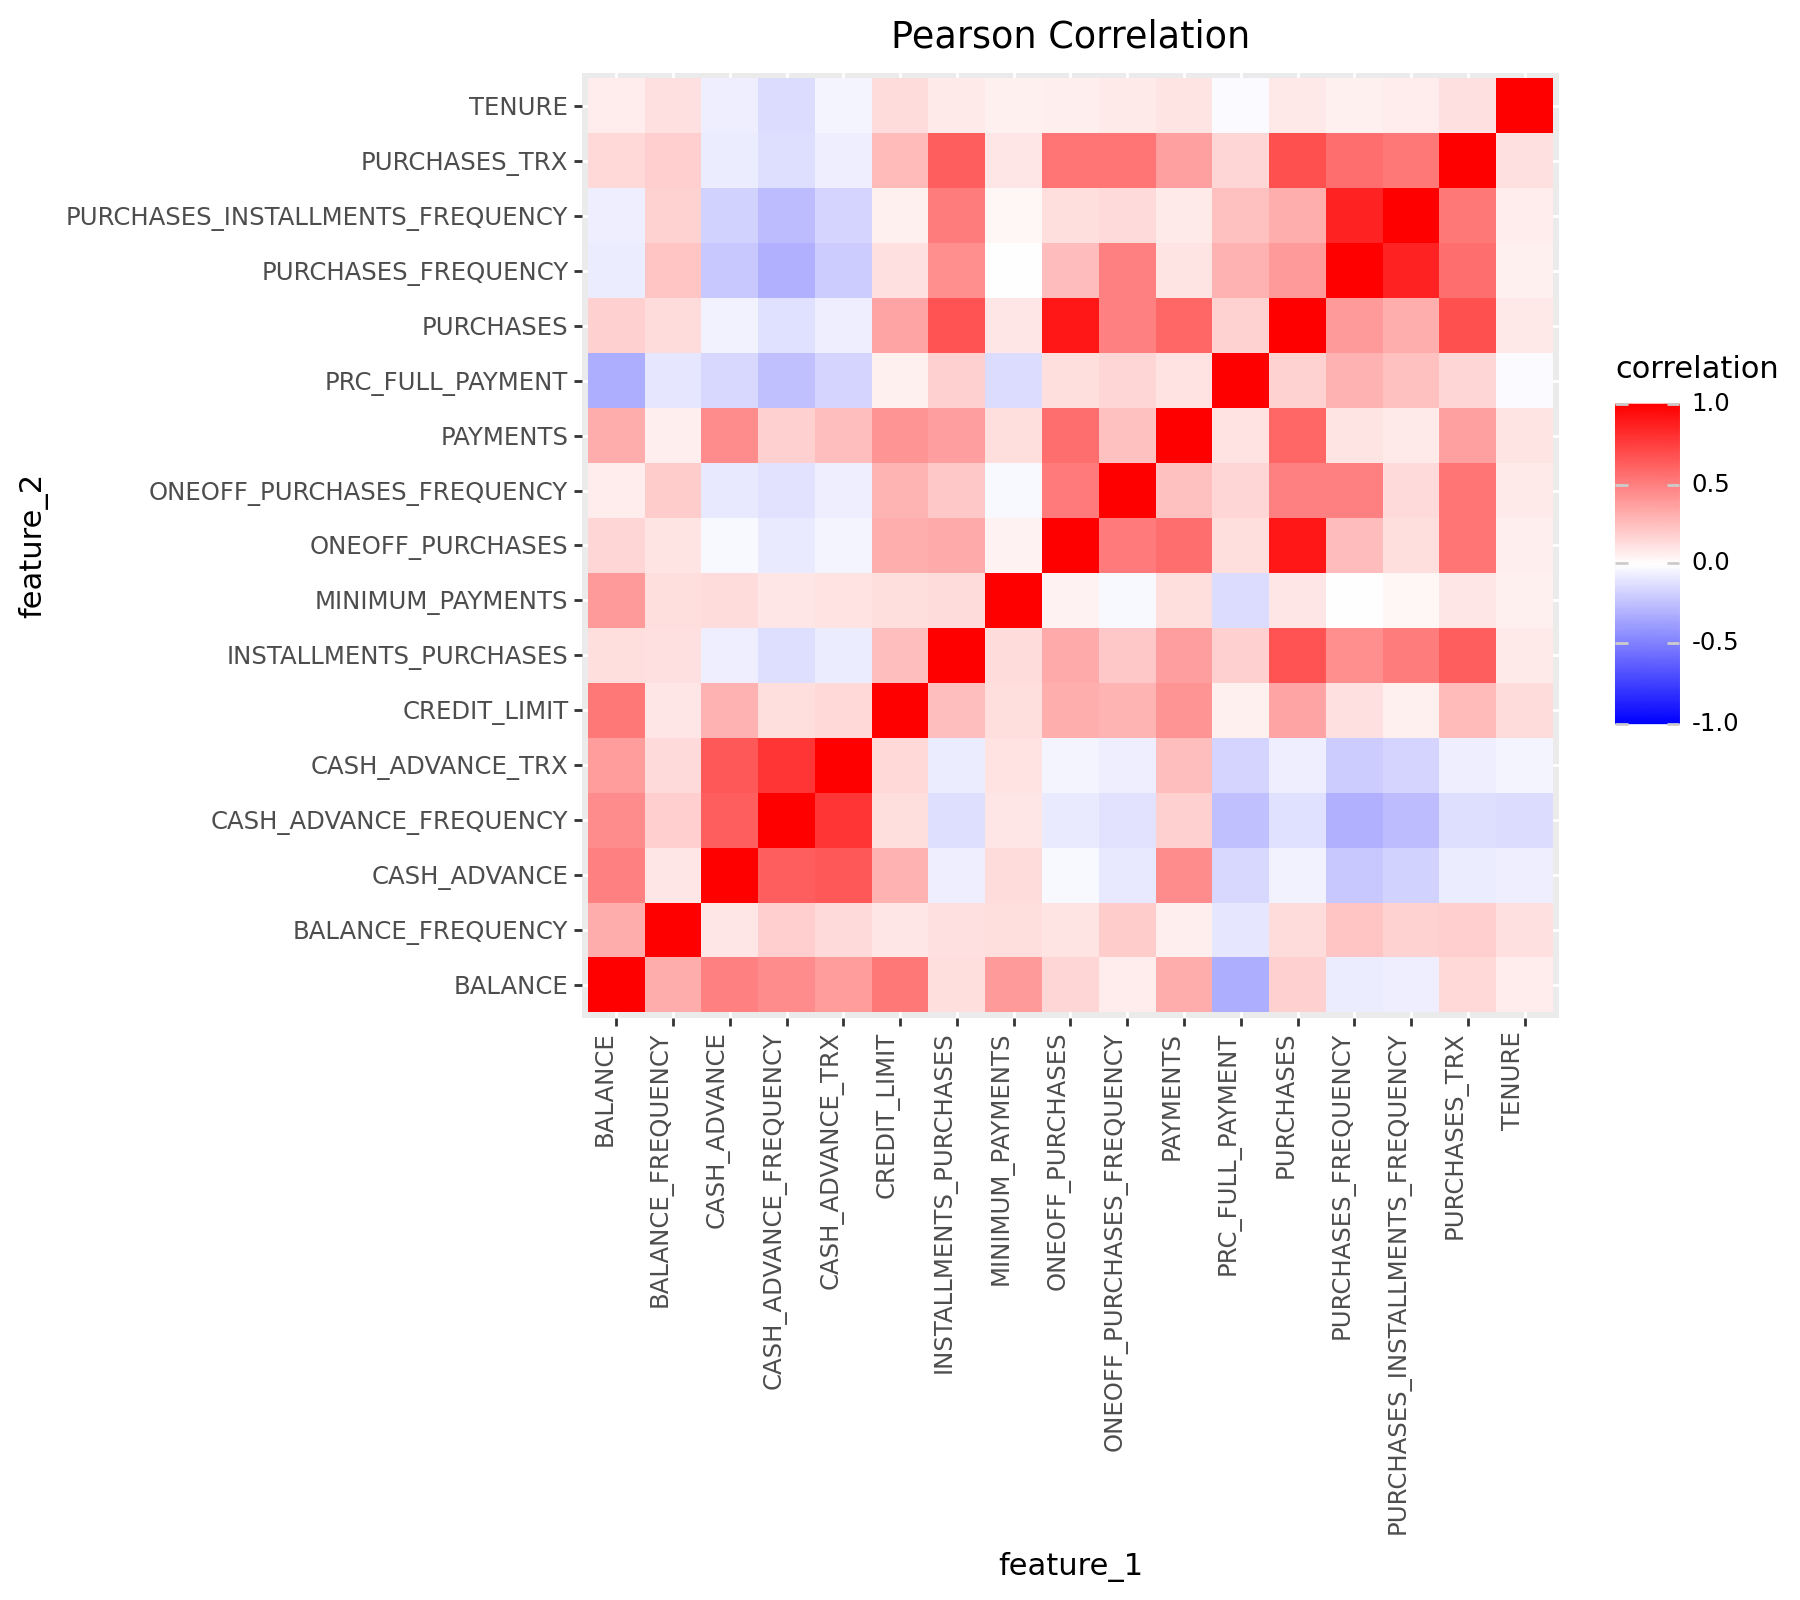

In [223]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")
corr_diff = (spearman_corr - pearson_corr)

def corr_heatmap(matrix, title):
    long = matrix.reset_index().melt(id_vars="index")
    long.columns = ["feature_1", "feature_2", "correlation"]
    return (
        pln.ggplot(long, pln.aes("feature_1", "feature_2", fill="correlation"))
        + pln.geom_tile()
        + pln.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0, limits=(-1, 1))
        + pln.theme(axis_text_x=pln.element_text(rotation=90, hjust=1), figure_size=(9, 8))
        + pln.labs(title=title)
    )

corr_heatmap(pearson_corr, "Pearson Correlation")

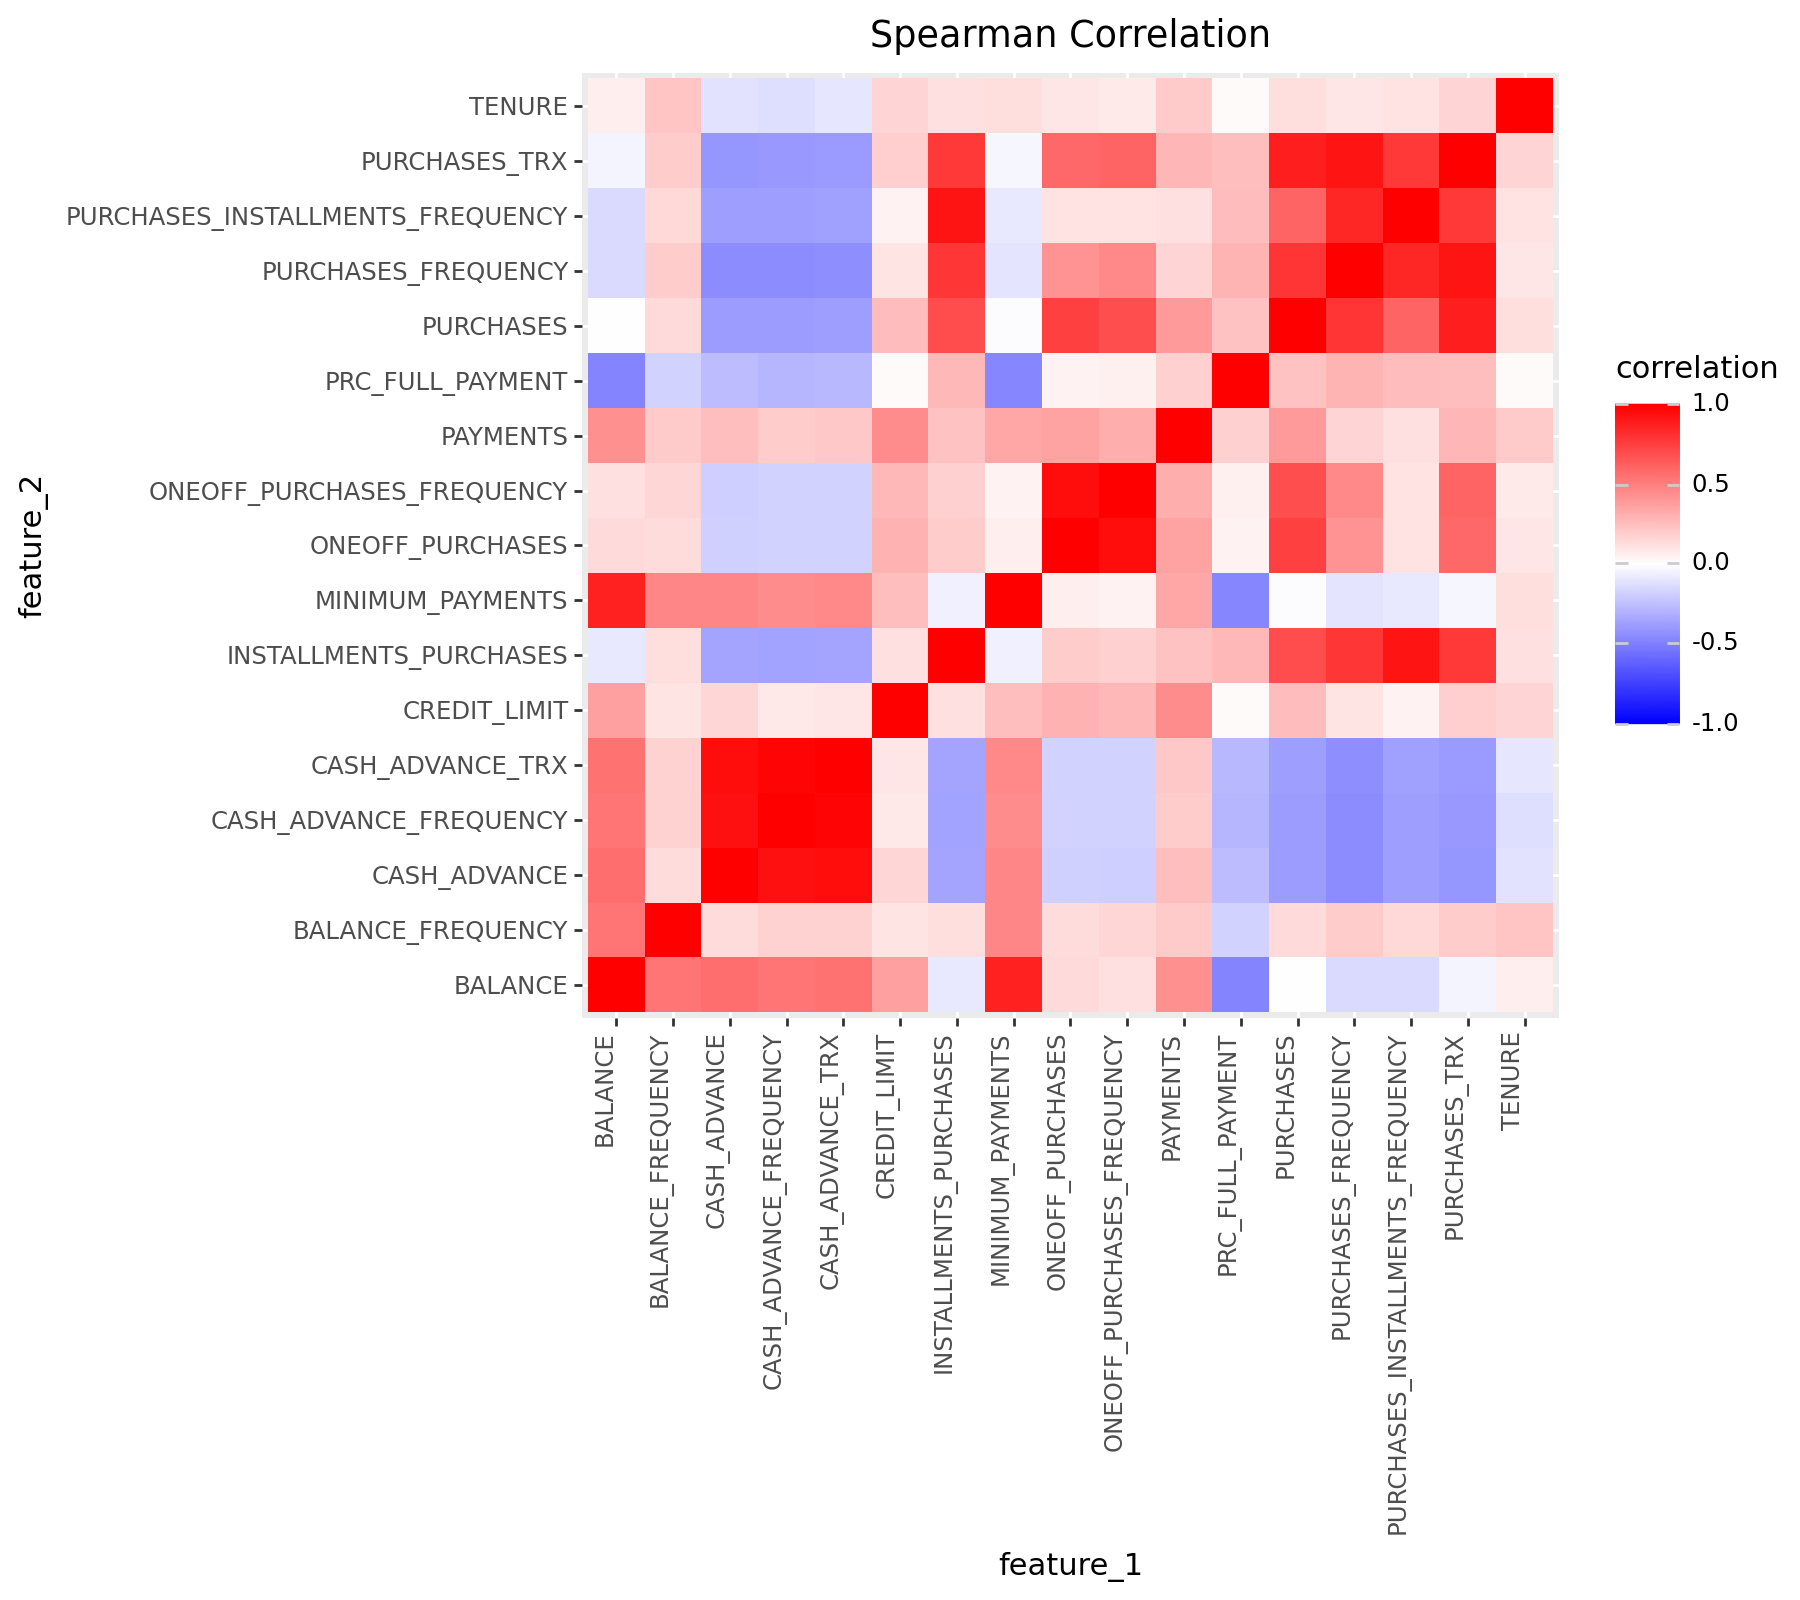

In [224]:
corr_heatmap(spearman_corr, "Spearman Correlation")

In [225]:
# Pairs where Spearman and Pearson disagree the most (excluding self-correlation)
diff_long = corr_diff.reset_index().melt(id_vars="index")
diff_long.columns = ["feature_1", "feature_2", "diff"]
diff_long = diff_long[diff_long["feature_1"] != diff_long["feature_2"]]
diff_long["abs_diff"] = diff_long["diff"].abs()
diff_long.sort_values("abs_diff", ascending=False).drop_duplicates(subset="abs_diff").head(15)

,feature_1,feature_2,diff,abs_diff
238,BALANCE,MINIMUM_PAYMENTS,0.473441,0.473441
58,ONEOFF_PURCHASES_FREQUENCY,ONEOFF_PURCHASES,0.427556,0.427556
140,INSTALLMENTS_PURCHASES,PURCHASES_INSTALLMENTS_FREQUENCY,0.412095,0.412095
104,PURCHASES,PURCHASES_FREQUENCY,0.401551,0.401551
184,MINIMUM_PAYMENTS,CASH_ADVANCE_TRX,0.356857,0.356857
193,PURCHASES_FREQUENCY,PURCHASES_TRX,0.355161,0.355161
167,MINIMUM_PAYMENTS,CASH_ADVANCE_FREQUENCY,0.352067,0.352067
74,PURCHASES_FREQUENCY,INSTALLMENTS_PURCHASES,0.344048,0.344048
253,PRC_FULL_PAYMENT,MINIMUM_PAYMENTS,-0.341597,0.341597
239,BALANCE_FREQUENCY,MINIMUM_PAYMENTS,0.340663,0.340663


##### *Discussion — Pearson vs Spearman*

The 15 pairs with the largest |Spearman − Pearson| gap are dominated by one clear pattern:
an **amount** variable paired with its corresponding **frequency/count** variable —
`ONEOFF_PURCHASES` vs `ONEOFF_PURCHASES_FREQUENCY` (Δ=0.43), `PURCHASES` vs
`PURCHASES_FREQUENCY` (Δ=0.40), `INSTALLMENTS_PURCHASES` vs
`PURCHASES_INSTALLMENTS_FREQUENCY` (Δ=0.41), `PURCHASES_FREQUENCY` vs `PURCHASES_TRX`
(Δ=0.36), and several `MINIMUM_PAYMENTS`/`CASH_ADVANCE` combinations (Δ≈0.34–0.36).

This is exactly what the extreme skewness identified earlier would predict: the amount
variables are dominated by a small number of very large values, which suppresses their
*linear* (Pearson) correlation with a bounded, well-behaved variable like frequency — even
though, in rank terms, "more frequent activity" and "more total amount" move together almost
perfectly monotonically (high Spearman). Pearson is therefore **understating** the true
strength of these relationships.

A second, distinct pattern also stands out: negative gaps between `PURCHASES`/`PURCHASES_TRX`
and `CASH_ADVANCE`/`CASH_ADVANCE_TRX` (Δ≈ -0.32 to -0.33). Spearman is *more negative* than
Pearson here, suggesting two roughly mutually exclusive customer behaviors — "purchase-driven"
spenders vs. "cash-advance-driven" spenders — expressed consistently in rank order but blurred
in the raw linear correlation by the zero-inflation on both sides (most customers do very
little of either).

Notably, structurally related pairs like `PURCHASES` vs `ONEOFF_PURCHASES` (which is almost
additively part of `PURCHASES`) do **not** appear in this top-15 divergence list — meaning
their Pearson and Spearman correlations already agree closely, consistent with a genuinely
near-linear relationship.

**Implication for PCA (Section 3):** PCA is built on covariance, i.e. on the Pearson notion
of "relatedness." Since several of the data's strongest true relationships are monotonic but
not linear, raw PCA is likely to under-represent them in the leading components. This is a
concrete argument for log-transforming the heavily right-skewed monetary features
(`PURCHASES`, `CASH_ADVANCE`, `MINIMUM_PAYMENTS`, `PAYMENTS`, `BALANCE`) before PCA, so that
their linear correlation structure moves closer to their true monotonic structure.

### *Distribution Analysis*

For each major feature: histogram, boxplot, skewness, kurtosis.

#### *Skewness and Kurtosis*

**Skewness** measures how asymmetric a distribution is around its mean.

| Range | Interpretation |
|---|---|
| ≈ 0 | Symmetric (like a normal distribution) |
| \|skew\| < 0.5 | Approximately symmetric |
| 0.5 < \|skew\| < 1 | Moderately skewed |
| \|skew\| > 1 | Strongly skewed |
| skew > 0 | **Right (positive) skew** — long right tail, mean > median. Most values are low/concentrated, while a small minority reaches very high extreme values (e.g. `PURCHASES`, `CASH_ADVANCE` — most customers spend little, a small minority spends a lot) |
| skew < 0 | **Left (negative) skew** — long left tail, mean < median. Most values are high, while a small minority reaches very low extreme values (e.g. `TENURE`, skew = -2.9 — most customers have long tenure, a small minority has very short tenure) |

**Kurtosis**: kurtosis is a single continuous number, not just two
named states — it measures "how much weight sits in the tails relative to the center,"
normalized by variance. The full range looks like this:

| Value | Regime | Shape |
|---|---|---|
| **-2** (absolute theoretical minimum) | — | Two point masses exactly at the extremes, nothing in between — the most "U-shaped" a distribution can possibly be (e.g. a symmetric Bernoulli on {0,1}) |
| -2 to -1.2 | Bathtub / U-shaped | Mass concentrated near both edges, less in the middle |
| **-1.2** | Uniform | Perfectly flat — no concentration anywhere |
| ≈ 0 | Mesokurtic | Normal-like tails |
| > 0, increasing | Leptokurtic | Sharper central peak *and* heavier, more extreme tails as the value grows |

Note that -1.2 is the kurtosis of a continuous uniform distribution, and -2 is the
absolute lower bound for any distribution's excess kurtosis — so a value approaching -2
(rather than just "negative") is the specific signature of a bathtub/edge-concentrated
shape, distinct from a merely flat/uniform one.

**Important:** kurtosis alone cannot fully determine the shape, because it is a single
number and many different distributions can share the same value. A mildly negative
kurtosis can come from either a truly uniform distribution or a mild bathtub shape; a
high positive kurtosis can come from either a symmetric heavy-tailed distribution or a
sharp near-zero peak with a small extreme minority (as seen in `MINIMUM_PAYMENTS` here).
In both cases, the histogram is needed to tell the shapes apart — kurtosis narrows down
the hypothesis, it does not confirm it on its own.


In [226]:
skew_kurt = pd.DataFrame({
    "skewness": df[numeric_cols].apply(lambda x: skew(x.dropna())),
    "kurtosis": df[numeric_cols].apply(lambda x: kurtosis(x.dropna())),
}).sort_values("skewness", ascending=False)

skew_kurt

,skewness,kurtosis
MINIMUM_PAYMENTS,13.850125,293.555553
ONEOFF_PURCHASES,10.043399,164.095191
PURCHASES,8.142904,111.325882
INSTALLMENTS_PURCHASES,7.297897,96.520563
PAYMENTS,5.906630,54.739472
CASH_ADVANCE_TRX,5.720339,61.611758
CASH_ADVANCE,5.165743,52.869216
PURCHASES_TRX,4.629879,34.772995
BALANCE,2.392985,7.669794
PRC_FULL_PAYMENT,1.942494,2.430366


#### *Histograms & Boxplots per Feature*

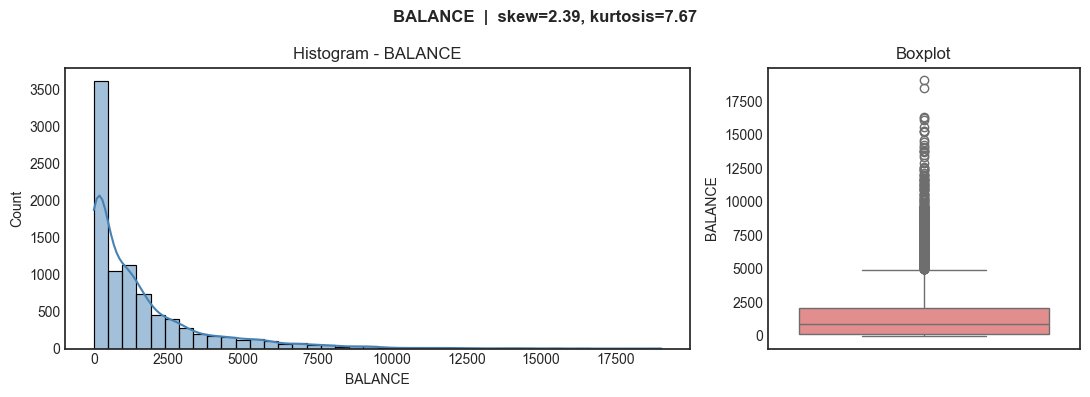

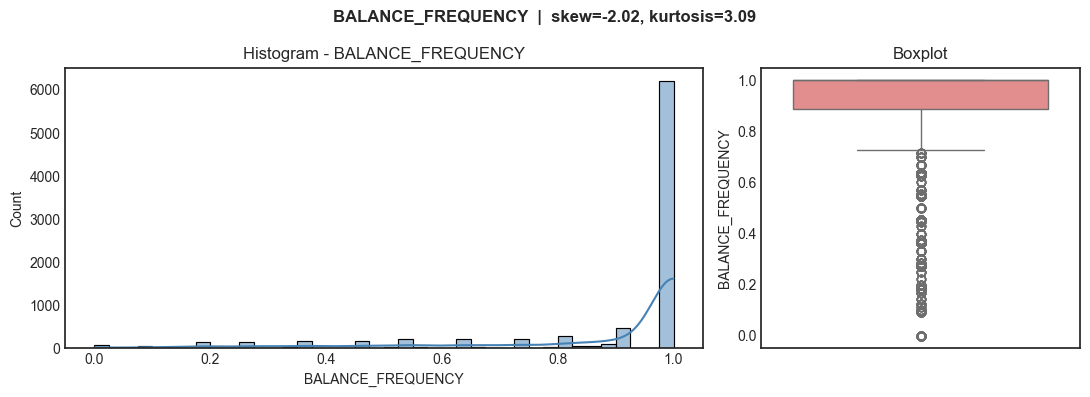

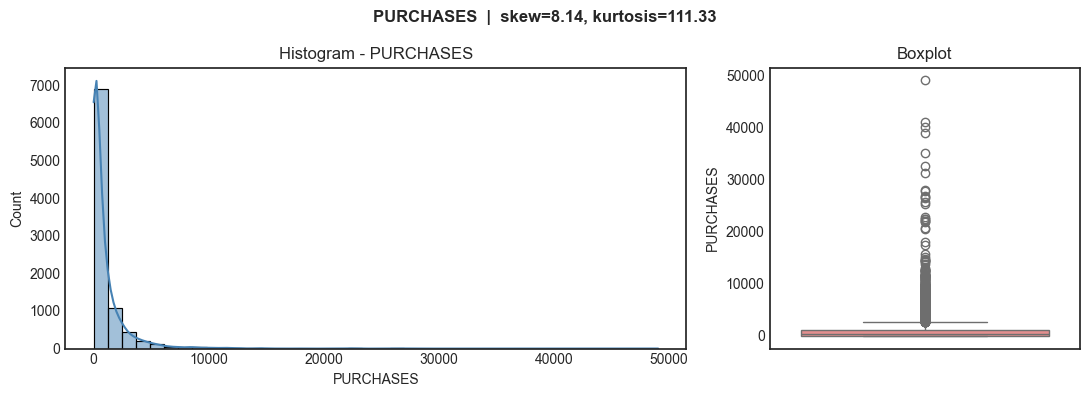

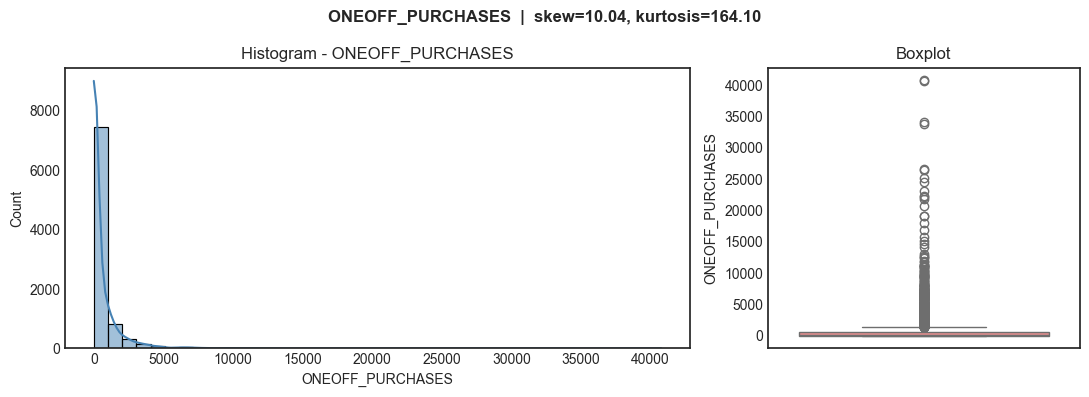

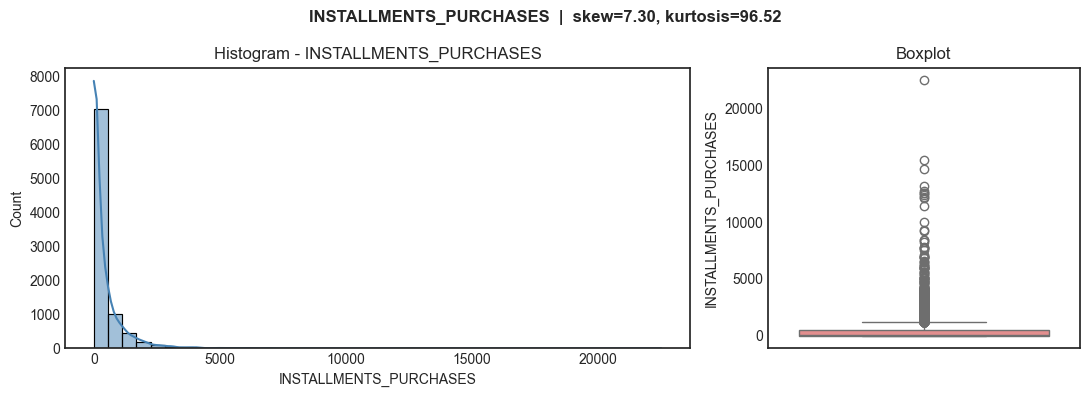

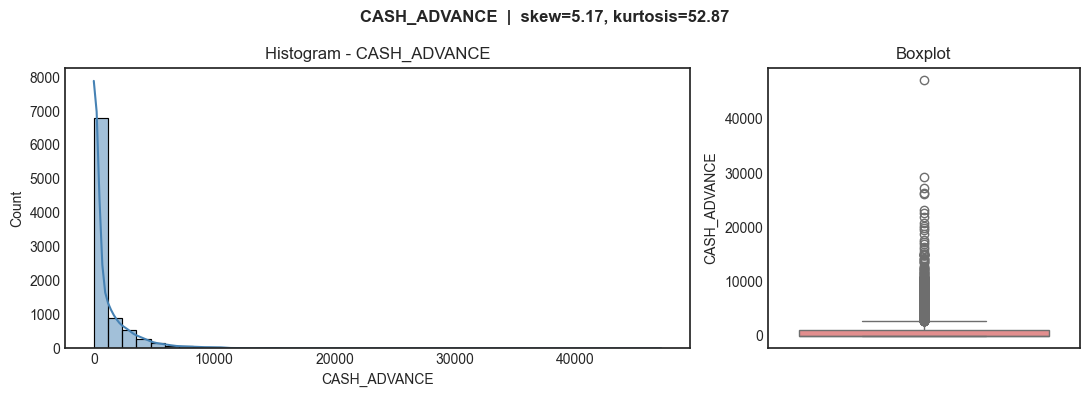

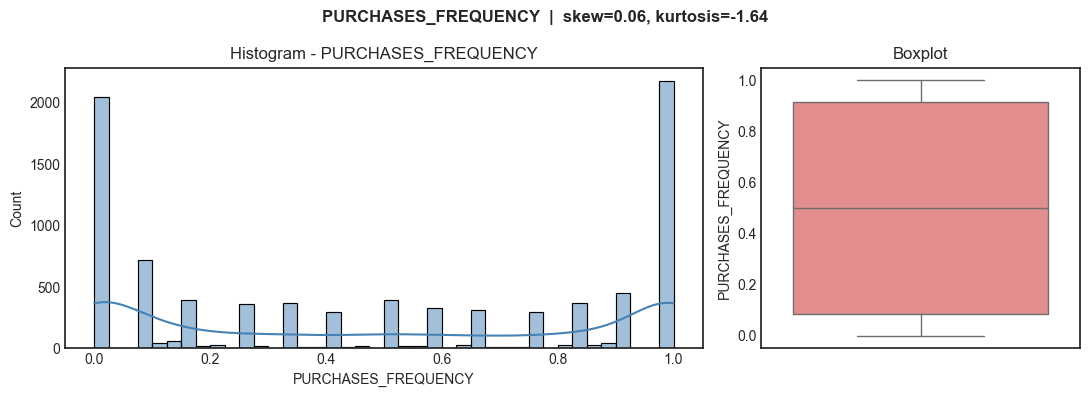

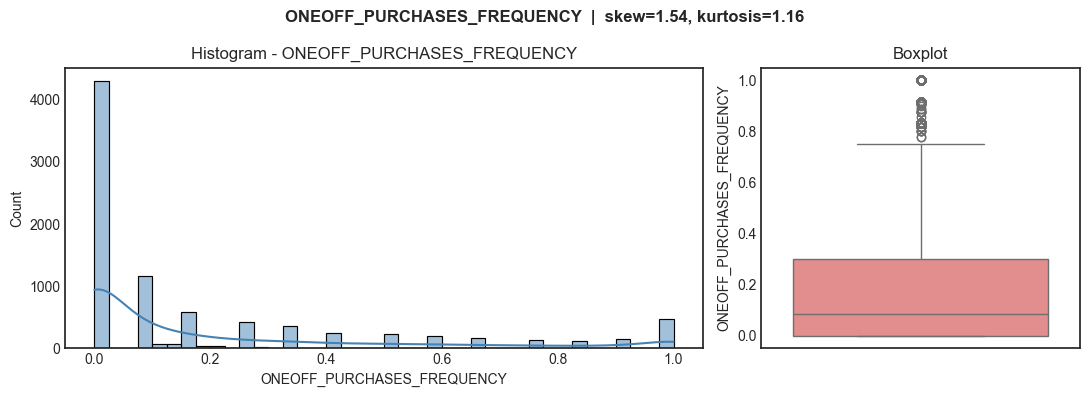

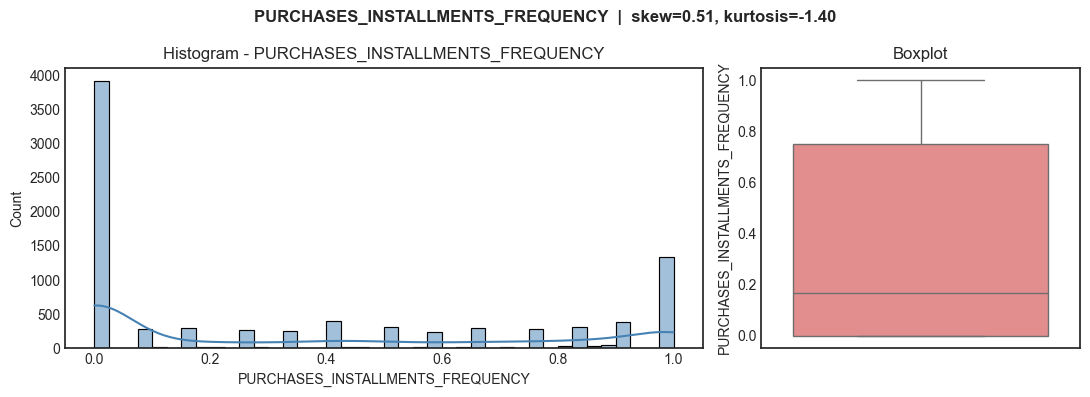

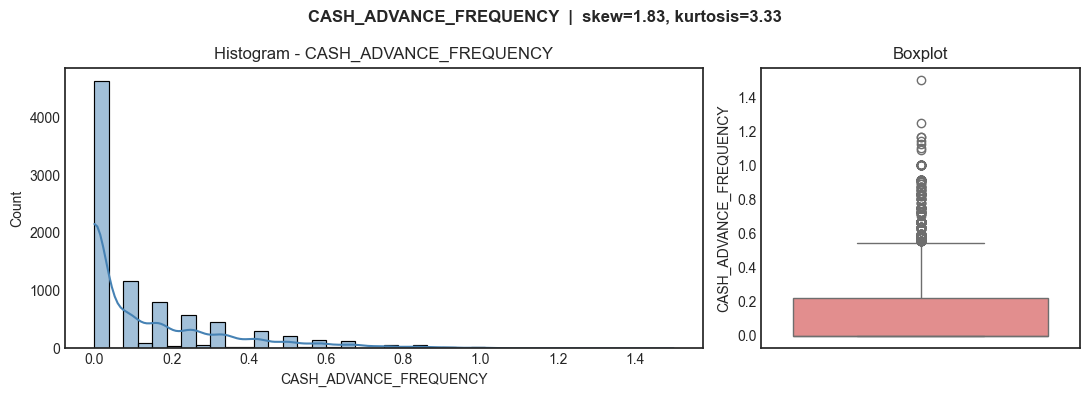

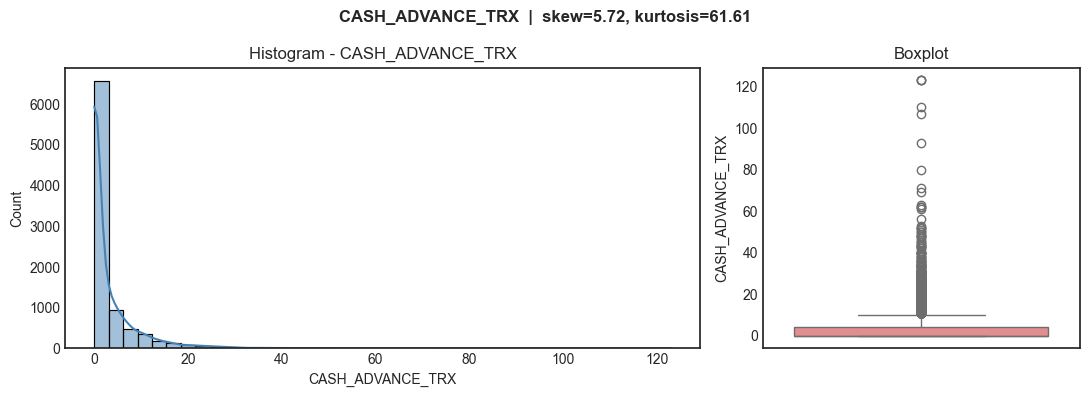

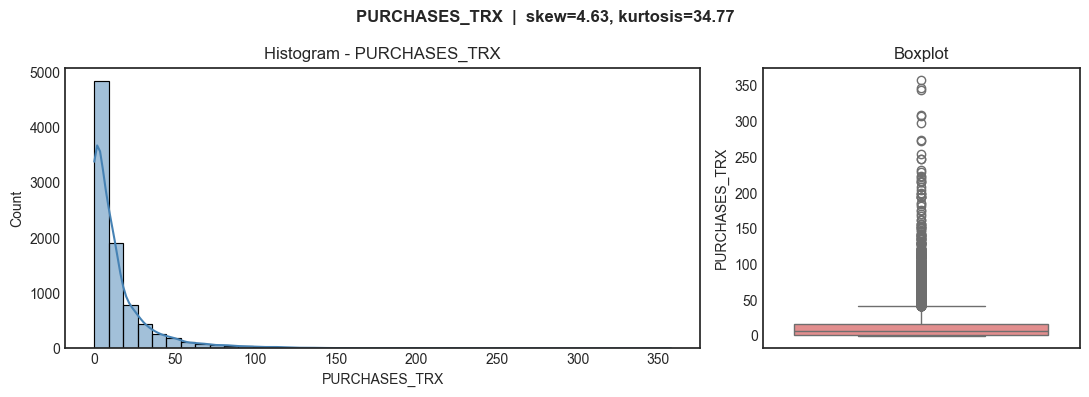

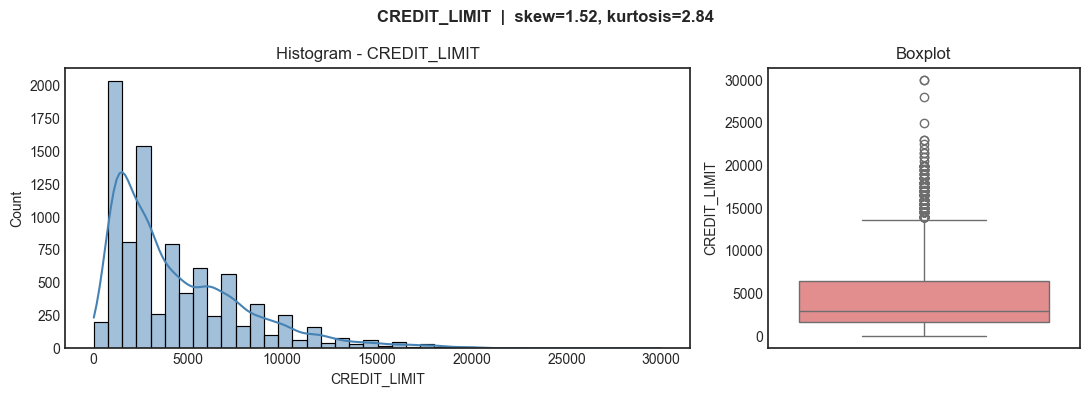

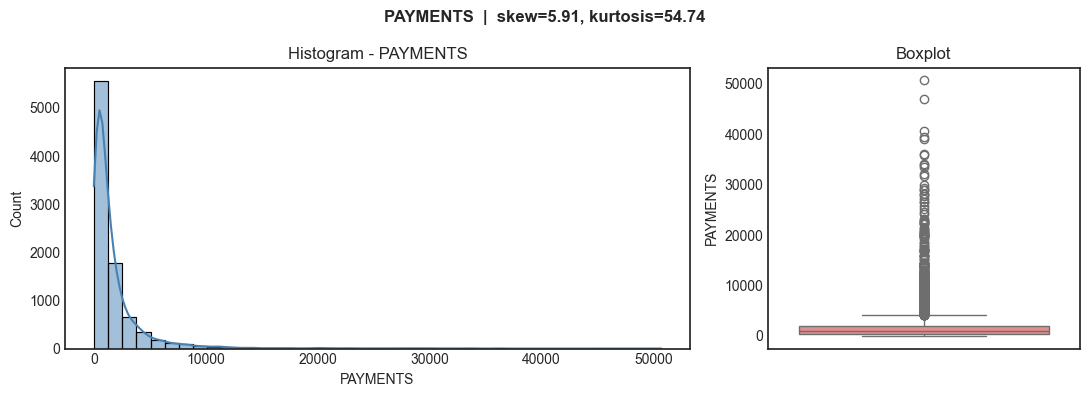

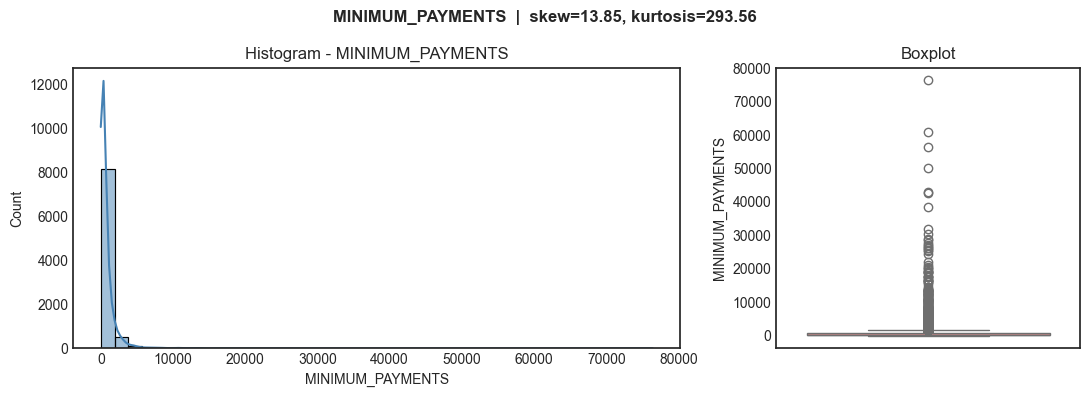

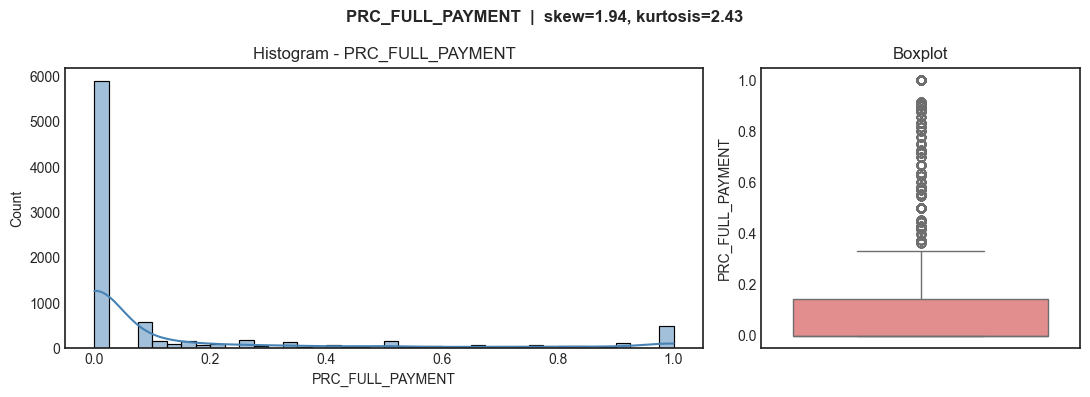

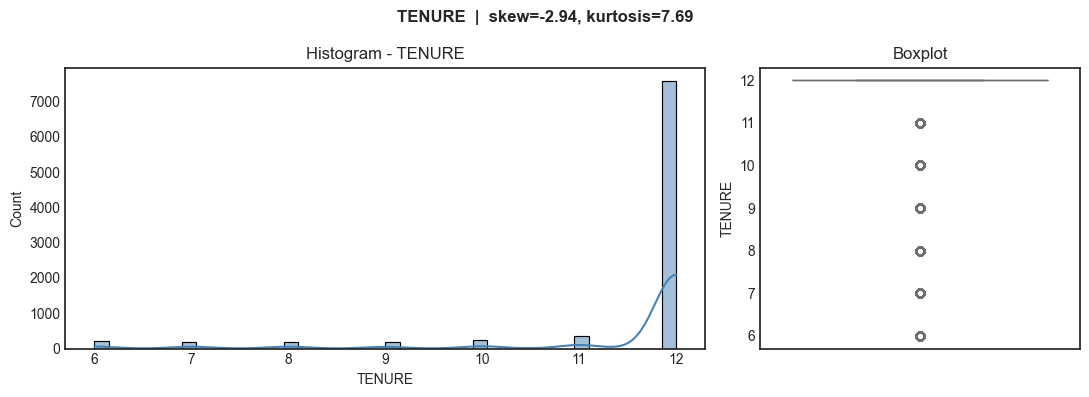

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_variable_summary(col, data):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})

    sns.histplot(data[col].dropna(), bins=40, kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title(f"Histogram - {col}")

    sns.boxplot(y=data[col].dropna(), ax=axes[1], color="lightcoral")
    axes[1].set_title("Boxplot")

    s, k = skew_kurt.loc[col, "skewness"], skew_kurt.loc[col, "kurtosis"]
    fig.suptitle(f"{col}  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

for col in numeric_cols:
    plot_variable_summary(col, df)

#### *Discussion — Distributions*



The skewness/kurtosis table confirms a strong right-skew across nearly every monetary and
count feature: `MINIMUM_PAYMENTS` (skew=13.85, kurtosis=293.56), `ONEOFF_PURCHASES`
(skew=10.04, kurtosis=164.10), `PURCHASES` (skew=8.14, kurtosis=111.33), and
`INSTALLMENTS_PURCHASES` (skew=7.30, kurtosis=96.52) are the most extreme. Economically, this
reflects the reality of consumer spending: the vast majority of customers spend modestly (or
not at all) in any given category, while a small minority of "big spenders" or "cash-advance
users" drives amounts far above the typical range — the classic long-tailed shape of financial
behavior data, not a data-quality problem.

`MINIMUM_PAYMENTS_WAS_MISSING` also shows high skew/kurtosis (5.06 / 23.63), but this is a
statistical artifact of it being a binary flag with only ~3.5% ones — it should not be
interpreted as a "distribution shape" finding the way the continuous features are.

`TENURE` is the most left-skewed feature (skew=-2.94, kurtosis=7.69). This is explained by a
ceiling effect visible in `describe()`: the 25th, 50th, and 75th percentiles are all exactly
12 — meaning at least three-quarters of customers have the maximum tenure of 12 months, with
only a minority holding the card for less time. This produces a sharp right-side spike (hence
positive/leptokurtic kurtosis) with a thin left tail, rather than a smooth bell shape.

The boxplots make this skew visually striking: because a handful of extreme high-value
customers force the y-axis to span the full range, the IQR box and whiskers for the
monetary features collapse into a thin sliver near the bottom of the plot, and only the
scattered extreme points remain clearly visible — creating the visual impression that
"almost everything is outside the IQR," even though the numeric outlier rates computed
above show this is not the case. This is a direct visual consequence of the skewness
already quantified above, not a plotting artifact or a data problem.

At the other extreme, `PURCHASES_FREQUENCY` (skew=0.06, kurtosis=-1.64) and
`PURCHASES_INSTALLMENTS_FREQUENCY` (skew=0.51, kurtosis=-1.40) are the two most platykurtic
features — close to a flat spread across [0,1]. Looking at their histograms directly (not just
the summary statistics) is necessary to confirm whether this reflects a genuinely even spread
of purchase habits across the customer base, or a bimodal concentration at the two endpoints
(customers who purchase "never" vs. "almost every month") — skewness/kurtosis alone cannot
distinguish between the two, as noted above.

**Implication:** the combination of extreme right-skew in monetary variables and near-uniform
spread in frequency variables means a single global scaling strategy (e.g. StandardScaler
alone) will not be sufficient before PCA/clustering — the monetary variables will need a
log-transform (or similar) first, while the frequency variables are likely fine on their
original scale.

### *Outlier Exploration*

#### *IQR-based Outlier Rates*

In [228]:
def iqr_outlier_pct(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((df[col] < lower) | (df[col] > upper)).mean() * 100

outlier_pct = pd.Series({col: iqr_outlier_pct(col) for col in numeric_cols}).sort_values(ascending=False)
outlier_pct

BALANCE_FREQUENCY                   16.681564
PRC_FULL_PAYMENT                    16.469274
TENURE                              15.262570
CASH_ADVANCE                        11.508380
ONEOFF_PURCHASES                    11.318436
MINIMUM_PAYMENTS                    10.156425
INSTALLMENTS_PURCHASES               9.687151
PAYMENTS                             9.027933
PURCHASES                            9.027933
CASH_ADVANCE_TRX                     8.983240
ONEOFF_PURCHASES_FREQUENCY           8.737430
PURCHASES_TRX                        8.558659
BALANCE                              7.765363
CASH_ADVANCE_FREQUENCY               5.865922
CREDIT_LIMIT                         2.770950
PURCHASES_INSTALLMENTS_FREQUENCY     0.000000
PURCHASES_FREQUENCY                  0.000000
dtype: float64

##### *Discussion — IQR-based Outlier Rates*

The two highest outlier rates in the table — `BALANCE_FREQUENCY` (16.68%) and `TENURE`
(15.26%) — are almost certainly methodological artifacts rather than real anomalies. Both
variables are heavily concentrated near their maximum value (`BALANCE_FREQUENCY` has a
median and 75th percentile of 1.0; `TENURE` has median = 75th percentile = 12). When most
of the data sits at a ceiling, the IQR becomes very narrow, so the 1.5×IQR rule flags a
large share of otherwise ordinary, lower-but-valid values.

By contrast, the monetary features (`CASH_ADVANCE` 11.51%, `ONEOFF_PURCHASES` 11.32%,
`MINIMUM_PAYMENTS` 10.16%, `PURCHASES`/`PAYMENTS` ~9.0%) show economically meaningful
outlier rates — these are the genuine "big spender" / "high cash-advance user" customers
already identified via skewness.

At the opposite extreme, `PURCHASES_FREQUENCY` and `PURCHASES_INSTALLMENTS_FREQUENCY` show
exactly 0% — consistent with their near-uniform, platykurtic shape: with no tight central
cluster, the IQR rule has nothing extreme to flag against, even if the histogram reveals a
real concentration at the endpoints.

**Takeaway:** the classical univariate IQR rule is informative for the continuous monetary
features but not appropriate for bounded [0,1] frequency features or for `TENURE` given its
ceiling effect — a point worth carrying into Section 5, where Z-score will face the same
Gaussianity problem even more directly.

#### *Data-Entry & Range Sanity Checks*

Beyond statistical outliers, it is worth verifying that the data does not contain
logically impossible values — signs of a data-entry error rather than a genuine extreme
observation. Two checks are performed:


(1) whether any of the `_FREQUENCY` features,
which are defined as a proportion of months and should therefore lie in [0, 1], contain
values outside that range.


(2) whether any customer's `MINIMUM_PAYMENTS` exceeds
their `PAYMENTS`, which would be inconsistent (the minimum required payment cannot be
larger than what the customer actually paid).

In [229]:
# Sanity checks: logical consistency and valid ranges for bounded/frequency features
freq_cols = [c for c in numeric_cols if "FREQUENCY" in c]
range_violations = {c: ((df[c] < 0) | (df[c] > 1)).sum() for c in freq_cols}

payment_violation = (df["MINIMUM_PAYMENTS"] > df["PAYMENTS"]).sum()

print("Out-of-[0,1]-range violations per frequency feature:", range_violations)
print(f"Rows where MINIMUM_PAYMENTS > PAYMENTS: {payment_violation}")

Out-of-[0,1]-range violations per frequency feature: {'BALANCE_FREQUENCY': np.int64(0), 'PURCHASES_FREQUENCY': np.int64(0), 'ONEOFF_PURCHASES_FREQUENCY': np.int64(0), 'PURCHASES_INSTALLMENTS_FREQUENCY': np.int64(0), 'CASH_ADVANCE_FREQUENCY': np.int64(8)}
Rows where MINIMUM_PAYMENTS > PAYMENTS: 2638


##### *Discussion — Data-Entry & Range Sanity Checks*

The [0,1] range check found only 8 violations (0.09% of rows), all in
`CASH_ADVANCE_FREQUENCY` — a small enough count to plausibly be a rounding artifact from
how the ratio was computed, rather than a systematic data-quality problem, but worth a
direct look at the affected rows before drawing a conclusion.

The `MINIMUM_PAYMENTS > PAYMENTS` check requires a correction to the assumption stated
above: this condition is not actually a logical impossibility. It occurs for 2,638 rows
(~29.5% of customers) — far too high a share to reflect data-entry errors. It far more
plausibly reflects a real and common credit-card behavior: paying less than the required
minimum (a partial or missed payment). Rather than a data-quality flag, this is itself a
potentially meaningful behavioral signal — these customers may be exactly the kind of
"at-risk" segment worth revisiting during anomaly detection in Section 5.

## *3. Dimensionality Reduction*

### *3.1 Principal Component Analysis (PCA)*

#### *Mathematical Background: Eigenvectors, Eigenvalues, and What PCA Optimizes*


Let $X$ be our standardized data matrix ($n$ customers × $p$ features, each column with
mean 0 and variance 1). PCA looks for a new set of axes — linear combinations of the
original features — that are (a) orthogonal to each other and (b) ordered so that the
first axis captures as much of the data's variance as possible, the second captures as
much of the *remaining* variance as possible, and so on.

**The covariance matrix.** For standardized data, the sample covariance matrix is

$$\Sigma = \frac{1}{n-1} X^T X$$

$\Sigma$ is a $p \times p$ symmetric matrix. Its diagonal entries are the variances of
each feature (all equal to 1, since we standardized); its off-diagonal entries are the
pairwise covariances (equivalently, Pearson correlations, since the data is standardized)
— this is exactly the same matrix we already computed and visualized in Section 2 as the
Pearson correlation heatmap.

**Eigenvectors and eigenvalues.** A vector $v$ is an eigenvector of $\Sigma$ with
eigenvalue $\lambda$ if

$$\Sigma v = \lambda v$$

Geometrically: applying $\Sigma$ to $v$ doesn't rotate $v$ — it only stretches it, by a
factor of $\lambda$. PCA's key result (from linear algebra) is that **the directions of
maximum variance in the data are exactly the eigenvectors of $\Sigma$**, and the amount of
variance captured along each direction is exactly its eigenvalue. Since $\Sigma$ is
symmetric, it has $p$ real eigenvalues $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_p$
with orthogonal eigenvectors $v_1, v_2, \dots, v_p$ — these eigenvectors *are* the
principal components, ranked from most to least variance explained.

**Explained variance ratio.** Since the total variance in the data equals
$\sum_i \lambda_i$, the fraction of variance captured by component $i$ is simply

$$\text{explained variance ratio of PC}_i = \frac{\lambda_i}{\sum_{j=1}^{p} \lambda_j}$$

— exactly the `explained_variance_ratio_` column computed below.

**A tiny worked example.** Suppose we had just two standardized features with a strong
correlation $\rho = 0.8$ between them (a simplified stand-in for a pair like `PURCHASES`
and `PURCHASES_TRX`). Their covariance matrix is

$$\Sigma = \begin{pmatrix} 1 & 0.8 \\ 0.8 & 1 \end{pmatrix}$$

Solving $\det(\Sigma - \lambda I) = 0$ gives $(1-\lambda)^2 = 0.64$, so
$\lambda_1 = 1.8$ and $\lambda_2 = 0.2$. The corresponding eigenvectors are
$v_1 = \frac{1}{\sqrt2}(1, 1)$ and $v_2 = \frac{1}{\sqrt2}(1, -1)$ — i.e. the *sum* of the
two variables (their shared, common direction) captures $1.8 / (1.8+0.2) = 90\%$ of the
variance, while their *difference* (the direction in which they disagree) captures only
10%. This is the geometric essence of what we'll see below: when features are strongly
correlated, PCA collapses them into one dominant direction, and the redundancy shows up
as a small number of components carrying most of the variance.

**Loadings.** Each principal component is a linear combination of the original
(standardized) features:

$$\text{PC}_i = v_{i,1} x_1 + v_{i,2} x_2 + \dots + v_{i,p} x_p$$

The coefficients $v_{i,1}, \dots, v_{i,p}$ — the entries of eigenvector $v_i$ — are called
the **loadings**. A large positive loading means that feature pulls the component up when
it's high; a large negative loading means it pulls the component down. Reading the sign
and magnitude of the loadings is how we interpret what each abstract "PC" actually means
in terms of real customer behavior.

#### *Preprocessing for PCA*

Two preprocessing steps are required before applying PCA, both motivated directly by
findings from Section 2:

1. **Log-transform (`log1p`) for right-skewed features** (skewness > 1, per the
   `skew_kurt` table). PCA is built on the covariance matrix, which is highly sensitive to
   extreme values — a handful of customers with `MINIMUM_PAYMENTS` in the tens of
   thousands (skewness = 13.85) would dominate the variance calculation and distort the
   eigenvectors, even after standardization (standardization only rescales, it does not
   change the *shape* of a distribution). `log1p(x) = log(1+x)` compresses large values
   much more than small ones, pulling the extreme tail in while leaving zeros well-defined
   — and, as discussed in Section 2, it moves the Pearson correlation structure closer to
   the true monotonic (Spearman) relationships we found between these variables.
2. **Standardization (`StandardScaler`)**, so every feature has mean 0 and variance 1.
   Without this, a feature measured in raw dollars (e.g. `CREDIT_LIMIT`, up to tens of
   thousands) would mechanically dominate the covariance matrix over a feature bounded in
   [0,1] (e.g. `PURCHASES_FREQUENCY`) — not because it is more informative, but purely
   because of its measurement scale.

`MINIMUM_PAYMENTS_WAS_MISSING` is excluded from the PCA input: it is an engineered,
sparse binary flag (3.5% ones) rather than part of the continuous behavioral geometry PCA
is meant to summarize.

In [230]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = [c for c in numeric_cols if c != "MINIMUM_PAYMENTS_WAS_MISSING"]

# Right-skewed features (skew > 1) get log1p; log1p handles zeros gracefully (log(1+x))
right_skewed = skew_kurt.loc[pca_features][skew_kurt.loc[pca_features, "skewness"] > 1].index.tolist()
print("Log-transformed features:", right_skewed)

X = df[pca_features].copy()
for col in right_skewed:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=pca_features, index=X.index)

X_scaled.describe().T[["mean", "std", "min", "max"]]

Log-transformed features: ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']


,mean,std,min,max
BALANCE,1.270244e-17,1.000056,-3.060633,1.834341
BALANCE_FREQUENCY,2.286439e-16,1.000056,-3.703271,0.518084
PURCHASES,6.986342e-17,1.000056,-1.679855,2.023087
ONEOFF_PURCHASES,2.540488e-17,1.000056,-0.987090,2.283062
INSTALLMENTS_PURCHASES,1.587805e-18,1.000056,-1.087454,2.163264
CASH_ADVANCE,5.716098e-17,1.000056,-0.930733,2.086805
PURCHASES_FREQUENCY,-1.841854e-16,1.000056,-1.221758,1.269843
ONEOFF_PURCHASES_FREQUENCY,2.540488e-17,1.000056,-0.732480,2.466762
PURCHASES_INSTALLMENTS_FREQUENCY,4.604634e-17,1.000056,-0.916995,1.599199
CASH_ADVANCE_FREQUENCY,-2.381707e-17,1.000056,-0.724360,5.122793


#### *Explained Variance*

`pca_full.explained_variance_ratio_` returns $\lambda_i / \sum_j \lambda_j$ for every
component — the practical output of the eigendecomposition described above. The
cumulative sum tells us how many components are needed to retain a given fraction of the
data's total variance (information).

##### *A Note on Notation: Three Different Things Called "PC1"*

The label "PC1" is used loosely to refer to three distinct mathematical objects. It is
worth being precise about which one is meant in each part of this analysis:

| Object | What it is | Where it appears below | How many numbers |
|---|---|---|---|
| $v_1$ | The eigenvector itself — a fixed **direction** in the 17-dimensional feature space. A property of the correlation matrix $\Sigma$, not of any individual customer. | The **Loadings** table/heatmap | 17 numbers (one weight per original feature) |
| $\lambda_1 / \sum_j \lambda_j$ | The **explained variance ratio** of $v_1$ — a single scalar describing how much of the total variance that direction captures. | The **Explained Variance** table and Scree Plot | 1 number (e.g. 34.2%) |
| $\text{PC}_1(j) = v_1^T x_j$ | The **coordinate** (projection score) of a specific customer $j$ onto the fixed direction $v_1$. | The **2D / 3D Projection** scatterplots | 8,950 numbers — one per customer |

These three are related but answer different questions:
- $v_1$ answers *"which combination of original features defines this axis?"*
- $\lambda_1/\sum_j\lambda_j$ answers *"how important is this axis, out of all 17?"*
- $\text{PC}_1(j)$ answers *"where does this particular customer fall along that axis?"*

All three come from the same eigendecomposition step,
$$\Sigma v_i = \lambda_i v_i, \qquad i = 1, \dots, 17,$$
which yields 17 eigenvector/eigenvalue pairs at once — not one at a time. Sorting them by
decreasing $\lambda_i$ and calling the largest one "PC1" is a labeling convention applied
*after* solving this equation, not a separate computation.

In [231]:
pca_full = PCA(n_components=len(pca_features), random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

variance_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca_features))],
    "explained_variance_ratio": explained_var,
    "cumulative_variance": cumulative_var,
})
variance_table

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.341827,0.341827
1,PC2,0.220830,0.562657
2,PC3,0.095124,0.657780
3,PC4,0.073720,0.731501
4,PC5,0.066334,0.797835
5,PC6,0.049788,0.847623
6,PC7,0.041840,0.889463
7,PC8,0.030939,0.920402
8,PC9,0.025001,0.945403
9,PC10,0.016205,0.961608


#### *Scree Plot*

The scree plot shows explained variance ratio per component in decreasing order. The
classic "elbow method" looks for the point where the curve flattens — components before
the elbow capture substantial, distinct variance; components after it contribute only
marginal, increasingly noise-like variance. The dashed red line marks $1/p$ — the variance
share a component would carry if all $p$ features were completely uncorrelated (the "no
redundancy" baseline); components above it are doing more work than chance would predict.

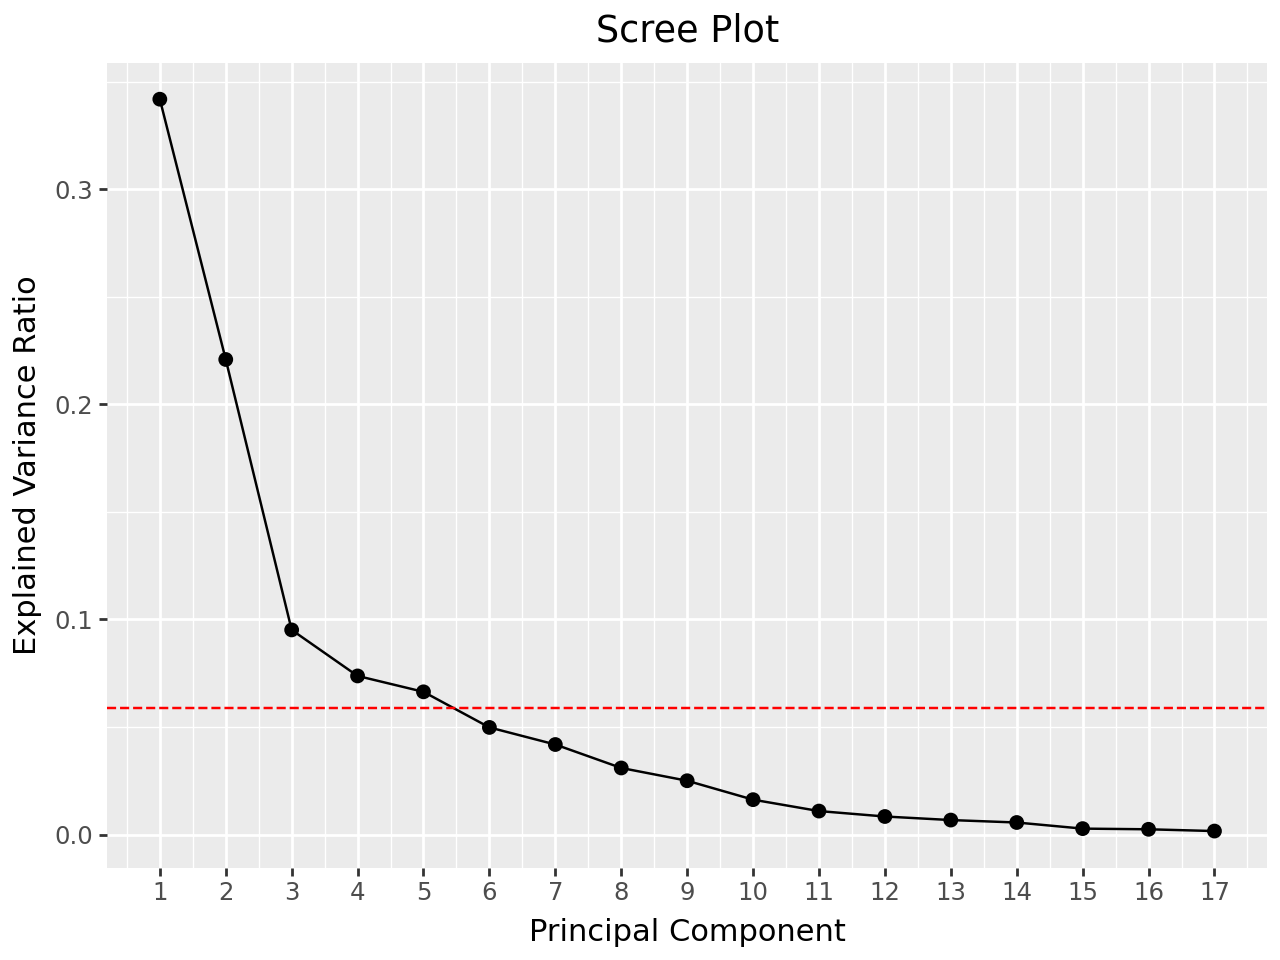

In [232]:
scree_df = variance_table.copy()
scree_df["component_num"] = range(1, len(scree_df) + 1)

(
    pln.ggplot(scree_df, pln.aes(x="component_num", y="explained_variance_ratio"))
    + pln.geom_line()
    + pln.geom_point(size=2)
    + pln.geom_hline(yintercept=1/len(pca_features), linetype="dashed", color="red")
    + pln.labs(title="Scree Plot", x="Principal Component", y="Explained Variance Ratio")
    + pln.scale_x_continuous(breaks=list(scree_df["component_num"]))
)

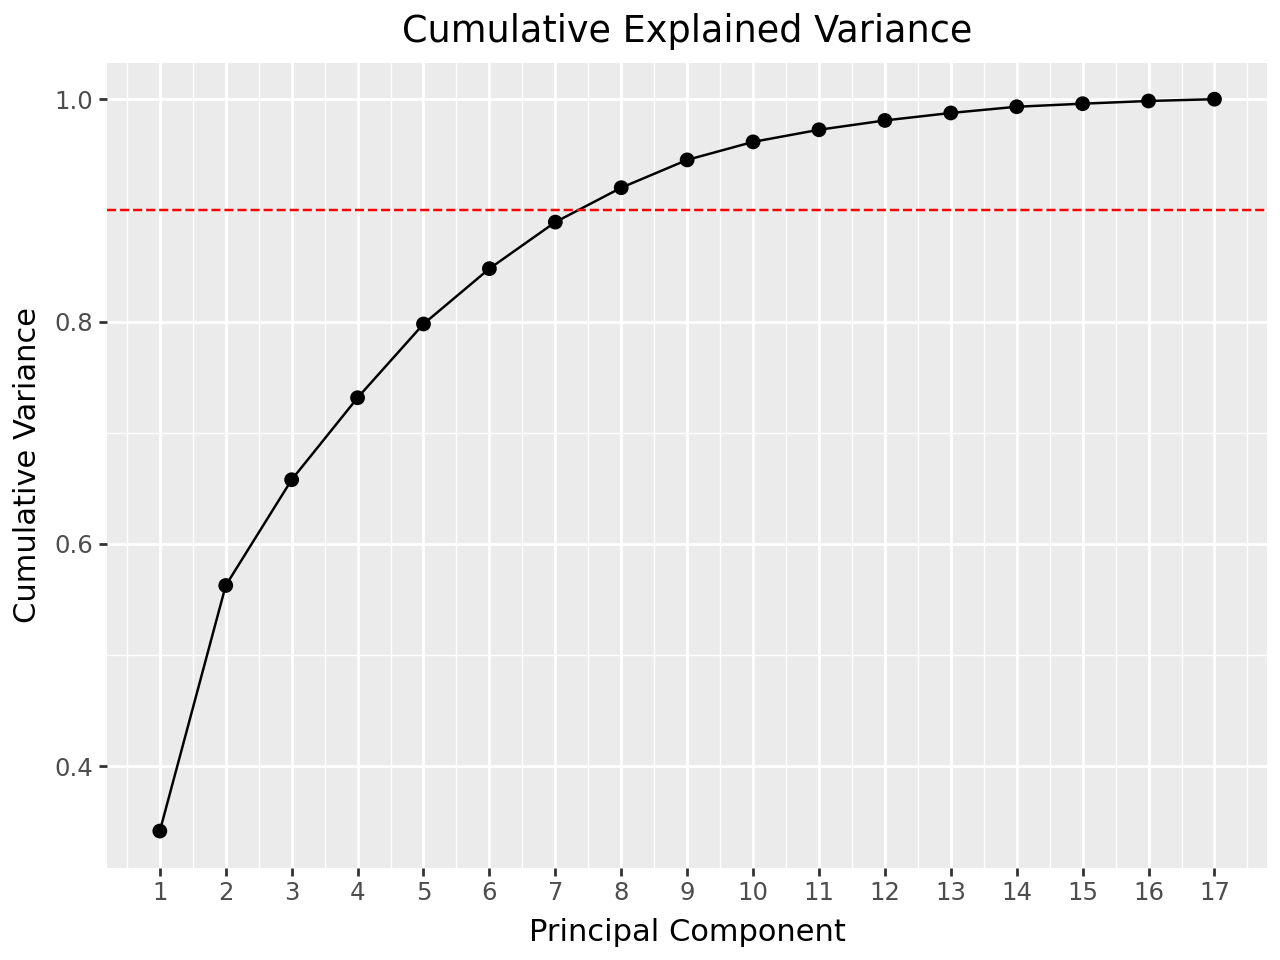

In [233]:
(
    pln.ggplot(scree_df, pln.aes(x="component_num", y="cumulative_variance"))
    + pln.geom_line()
    + pln.geom_point(size=2)
    + pln.geom_hline(yintercept=0.90, linetype="dashed", color="red")
    + pln.labs(title="Cumulative Explained Variance", x="Principal Component", y="Cumulative Variance")
    + pln.scale_x_continuous(breaks=list(scree_df["component_num"]))
)


#### *2D Projection*

Intuitively, this is like taking a 2D "shadow" of a 17-dimensional object: each customer
lives as a point in a 17-dimensional space, and this plot flattens that point down onto
just the two directions of greatest spread ($v_1$, $v_2$), the same way a 3D object casts
a flat shadow when light hits it from one particular angle. A shadow can look very
informative — you might be able to recognize a shape — but it can never show you every
detail of the true 3D object at once.

Concretely, this projection captures $34.2\% + 22.1\% = 56.3\%$ of the data's total
variance ($\lambda_1/\sum_j\lambda_j + \lambda_2/\sum_j\lambda_j$) — meaning that with just
2 out of the original 17 dimensions, we can still visually account for just over half of
all the variability across customers. That is a meaningful compression (17 numbers per
customer down to 2), but it also means the remaining $43.7\%$ of each customer's true
position — their spread along PC3 through PC17 — is invisible here. Two points that look
close together on this plot are not guaranteed to be similar customers; they are only
guaranteed to be similar *along these two particular directions*.

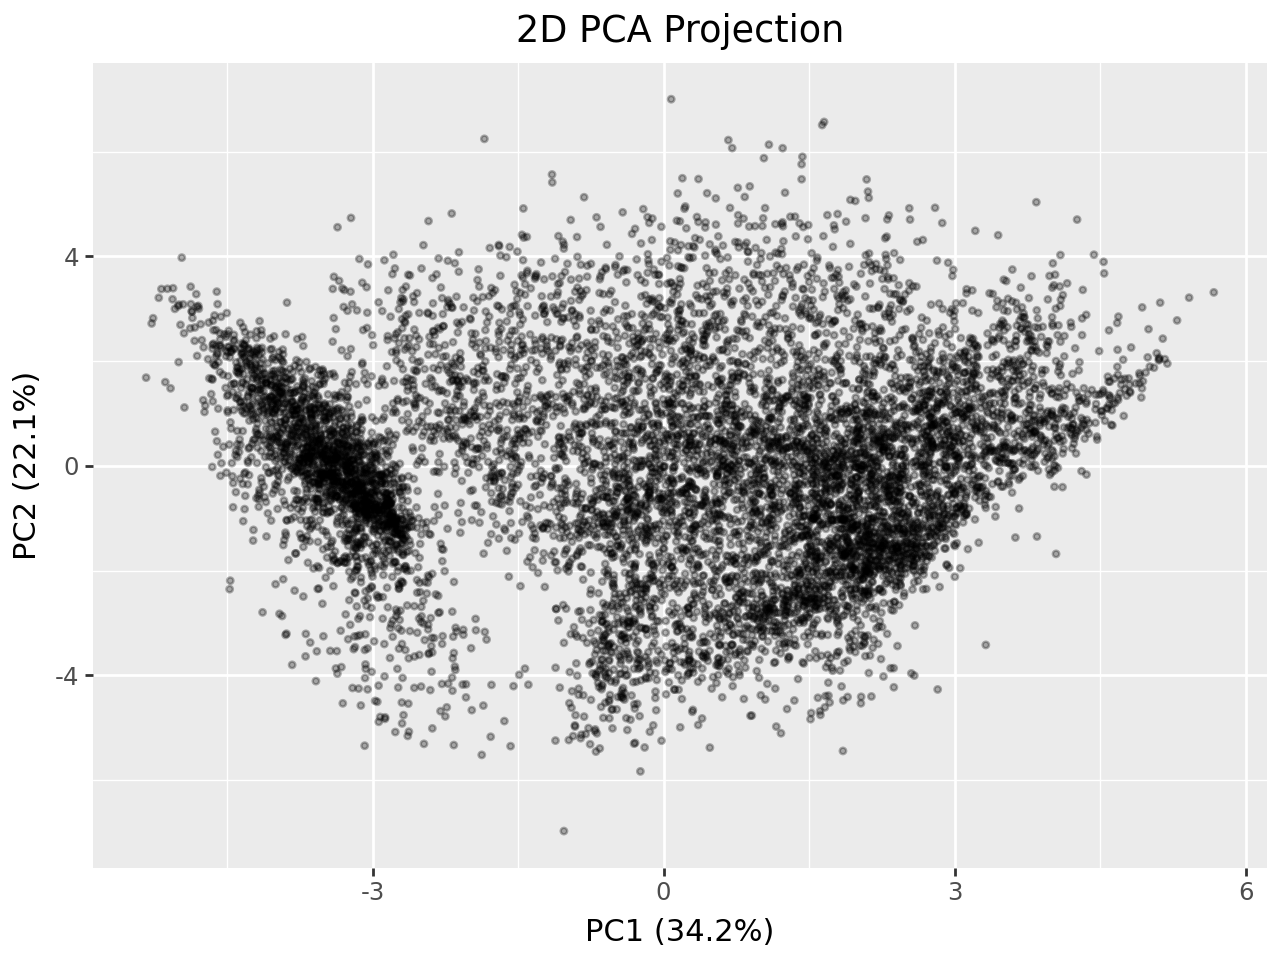

In [234]:
pca_2d = PCA(n_components=2, random_state=42)
components_2d = pca_2d.fit_transform(X_scaled)

proj_2d = pd.DataFrame(components_2d, columns=["PC1", "PC2"], index=X_scaled.index)

(
    pln.ggplot(proj_2d, pln.aes(x="PC1", y="PC2"))
    + pln.geom_point(alpha=0.3, size=0.8)
    + pln.labs(
        title="2D PCA Projection",
        x=f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})",
        y=f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})",
    )
)

#### *3D Projection*

Same idea extended to $v_1, v_2, v_3$ — a slightly less lossy view of the data's dominant
structure, at the cost of being harder to inspect visually than a flat 2D plot.

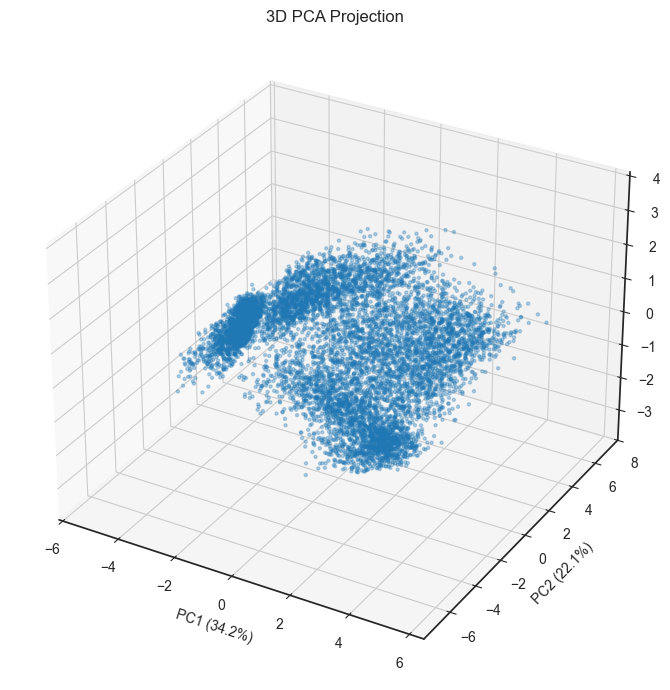

In [235]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
components_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(components_3d[:, 0], components_3d[:, 1], components_3d[:, 2], alpha=0.3, s=5)
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})")
ax.set_title("3D PCA Projection")
plt.tight_layout()
plt.show()

#### *Principal Component Loadings*

The heatmap below shows the full loading matrix — $v_{i,j}$ for every original feature $j$
across the first four components. The printed lists that follow it show, for each
$\text{PC}_i$, only the **top 5 features by absolute loading** — the 5 largest-magnitude
weights out of the 17 that make up $v_i$ — since those dominate the interpretation, not
the smaller remaining weights.

Each printed value is $v_{i,j}$, the coefficient of feature $j$ in the linear combination
that defines $\text{PC}_i$:

$$\text{PC}_1 = v_{1,1}\cdot x_1 + v_{1,2}\cdot x_2 + \dots + v_{1,17}\cdot x_{17}$$

Two things to read off each number:
- **Sign:** whether that feature pushes $\text{PC}_i$ up (+) or down (−). When several
  top features share the same sign, it means they all move together along that axis — a
  customer high in one tends to be high in $\text{PC}_i$ via all of them at once.
- **Magnitude:** how strongly that feature contributes, relative to the others. Because
  $v_i$ is a unit vector ($\sum_j v_{i,j}^2 = 1$), its "weight budget" is fixed — no single
  feature can dominate with an arbitrarily large coefficient. Several similarly-sized top
  loadings (as seen in PC1's top 5, all in the 0.31–0.37 range) indicate the axis is
  genuinely a blend of correlated features, not driven by one variable alone.

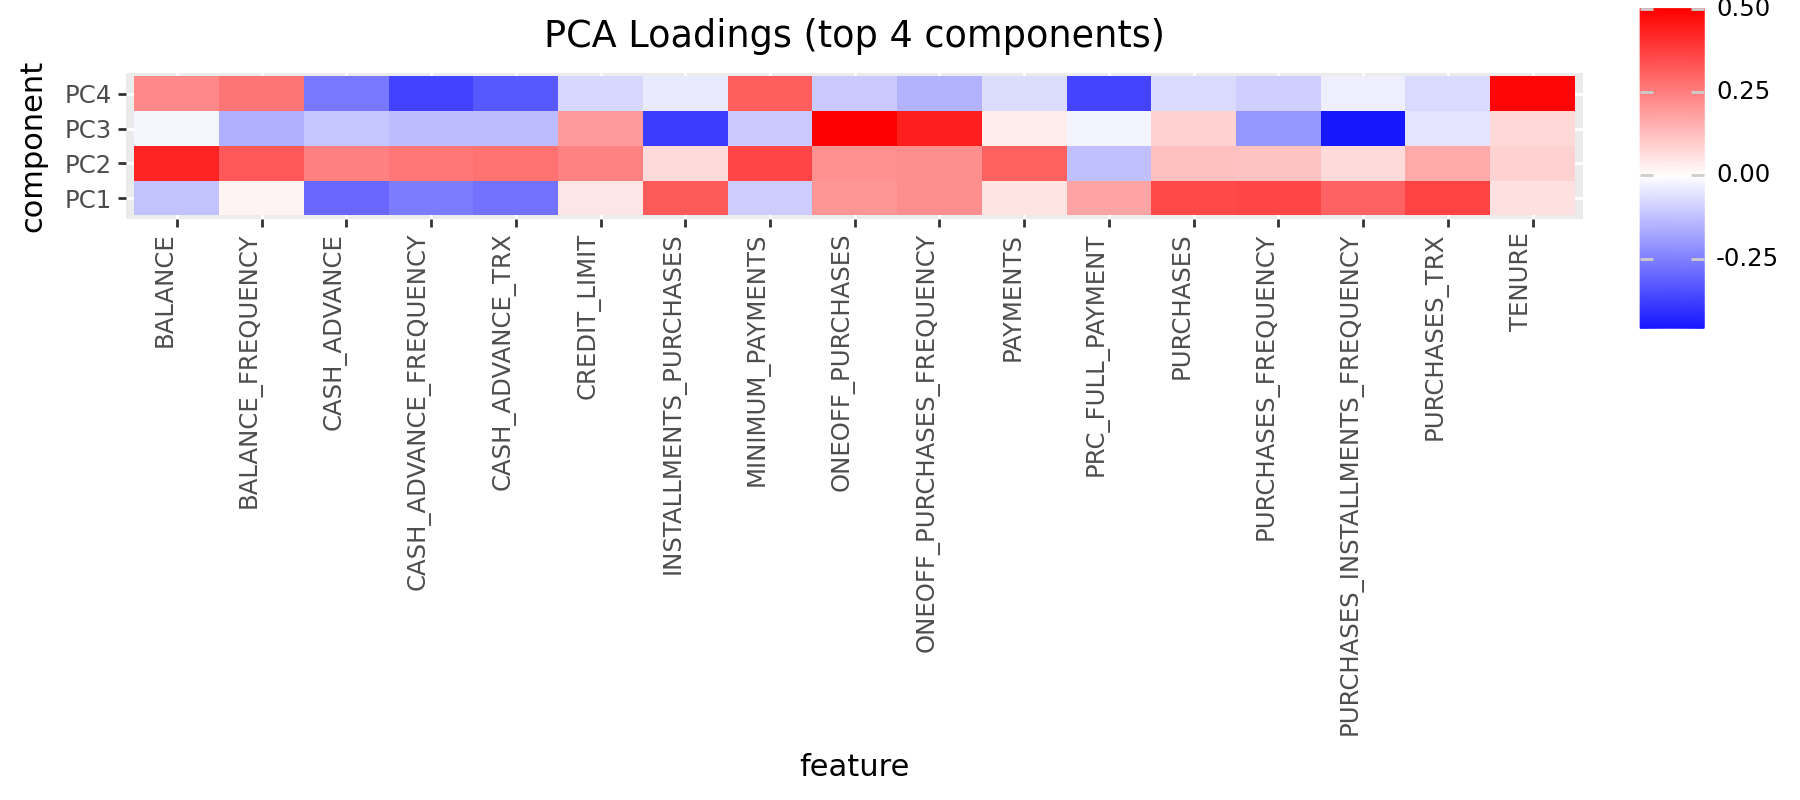

In [236]:
n_top_pcs = 4
loadings = pd.DataFrame(
    pca_full.components_[:n_top_pcs].T,
    index=pca_features,
    columns=[f"PC{i+1}" for i in range(n_top_pcs)],
)

loadings_long = loadings.reset_index().melt(id_vars="index")
loadings_long.columns = ["feature", "component", "loading"]

(
    pln.ggplot(loadings_long, pln.aes(x="feature", y="component", fill="loading"))
    + pln.geom_tile()
    + pln.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0)
    + pln.theme(axis_text_x=pln.element_text(rotation=90, hjust=1), figure_size=(9, 4))
    + pln.labs(title="PCA Loadings (top 4 components)")
)

In [237]:
for i in range(n_top_pcs):
    pc = f"PC{i+1}"
    top_features = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc} — top contributing features:")
    for feat in top_features.index:
        print(f"  {feat}: {loadings.loc[feat, pc]:+.3f}")


PC1 — top contributing features:
  PURCHASES_TRX: +0.374
  PURCHASES_FREQUENCY: +0.364
  PURCHASES: +0.363
  INSTALLMENTS_PURCHASES: +0.325
  PURCHASES_INSTALLMENTS_FREQUENCY: +0.311

PC2 — top contributing features:
  BALANCE: +0.435
  MINIMUM_PAYMENTS: +0.366
  BALANCE_FREQUENCY: +0.329
  PAYMENTS: +0.315
  CASH_ADVANCE_TRX: +0.281

PC3 — top contributing features:
  ONEOFF_PURCHASES: +0.505
  PURCHASES_INSTALLMENTS_FREQUENCY: -0.461
  ONEOFF_PURCHASES_FREQUENCY: +0.447
  INSTALLMENTS_PURCHASES: -0.384
  PURCHASES_FREQUENCY: -0.209

PC4 — top contributing features:
  TENURE: +0.492
  CASH_ADVANCE_FREQUENCY: -0.373
  PRC_FULL_PAYMENT: -0.371
  CASH_ADVANCE_TRX: -0.332
  MINIMUM_PAYMENTS: +0.317


#### *Discussion — Explained Variance, PC Interpretation & Redundancy*


The scree plot shows a steep initial drop — PC1 (34.2%), PC2 (22.1%), PC3 (9.5%) — followed
by a much more gradual decline (PC4–PC7 each between 4–7%). The "elbow" sits around PC2–PC3,
suggesting 2–3 components already capture the data's dominant structure. However, this
elbow only accounts for 65.8% of total variance (PC1+PC2+PC3), and reaching a conventional
90% threshold requires **8 components** (cumulative = 92.0% at PC8) out of the original 17.
This is a genuine tension worth stating explicitly: a *visually* compact low-dimensional
summary (2–3 axes) exists, but it is not a *complete* one — roughly a third of the data's
variance lives outside the first three components.

The loadings clarify what the leading components represent:
- **PC1** is dominated by `PURCHASES_TRX` (+0.374), `PURCHASES_FREQUENCY` (+0.364),
  `PURCHASES` (+0.363), `INSTALLMENTS_PURCHASES` (+0.325), `PURCHASES_INSTALLMENTS_FREQUENCY`
  (+0.311) — all positive, all measuring purchase *activity*. This mirrors the toy 2-variable
  example above: because these five features are strongly correlated (as already seen in
  the Section 2 Pearson/Spearman analysis), PCA collapses them into one dominant "general
  purchase engagement" axis.
- **PC2** is dominated by `BALANCE` (+0.435), `MINIMUM_PAYMENTS` (+0.366),
  `BALANCE_FREQUENCY` (+0.329), `PAYMENTS` (+0.315) — a "balance / debt-carrying" axis,
  distinct from purchase activity.
- **PC3** contrasts `ONEOFF_PURCHASES`/`ONEOFF_PURCHASES_FREQUENCY` (positive) against
  `PURCHASES_INSTALLMENTS_FREQUENCY`/`INSTALLMENTS_PURCHASES` (negative) — a "purchase
  *style*" axis (lump-sum vs. installment), orthogonal to how *much* a customer buys.
- **PC4** mixes `TENURE` (+0.492) with `CASH_ADVANCE_FREQUENCY` (-0.373) and
  `PRC_FULL_PAYMENT` (-0.371) — less cleanly interpretable than PC1–PC3; not every
  component needs to correspond to an intuitive business story, and forcing one here would
  overstate what the data actually shows.

**Redundancy in the original data:** needing only 8 of 17 features' worth of variance to
reach 90% (a ~53% reduction) confirms substantial redundancy — consistent with the
strongly correlated feature pairs already flagged in Section 2 (e.g. `PURCHASES` almost
additively decomposing into `ONEOFF_PURCHASES` + `INSTALLMENTS_PURCHASES`). The reduced
space is more *efficient*, but Section 2 also showed several of the data's strongest
relationships are monotonic rather than linear (Spearman >> Pearson) — PCA, being a linear
method built on covariance, may still be under-representing some of that structure even
after the log-transform.

#### *Discussion — Structure, Stability & Trade-offs*


**Local vs. global structure:** the 2D projection captures only 56.3% of total variance
(PC1+PC2) — it shows the dominant global spread of the data but cannot be trusted to
preserve finer local neighborhoods; two customers that appear close in the 2D plot could
still differ meaningfully along PC3–PC8. The 3D projection (67.8% cumulative) is somewhat
better but suffers the same caveat.

**Cluster separation:** the 2D/3D scatterplots show a dense, continuous, roughly
unimodal cloud with a long tail extending along PC1 (consistent with the purchase-activity
skew already quantified in Section 2) rather than visually distinct, separated groups —
suggesting that if clusters exist (Section 4), their boundaries are likely gradual rather
than sharply separated in this projection.

**Stability:** since PC1–PC3 are each dominated by a cohesive, highly-correlated group of
features, small changes to the log-transform threshold (e.g. skew > 1 vs. skew > 1.5)
would likely leave their *interpretation* stable, though exact loading magnitudes would
shift. PC4 onward, with smaller and more mixed loadings, would likely be less stable under
such changes.

**Computational cost:** trivial here (17 features, 8,950 rows) — PCA via eigendecomposition
is $O(p^3)$ in the number of features, negligible at this scale; this would only become a
concern with hundreds or thousands of features.

**Interpretability:** PC1–PC3 translate into plain-language axes ("how much does this
customer buy," "how much balance/debt do they carry," "lump-sum vs. installment style") that
are easy to explain to a non-technical stakeholder — a genuine advantage over presenting all
17 raw features. PC4 does not offer this benefit as cleanly.

**Redundancy:** ties directly to the previous discussion block — the fact that 3 components
already explain 65.8% of variance, concentrated in interpretable, business-meaningful axes,
is itself evidence that the original 17 features encode a much lower-dimensional underlying
structure of customer behavior.

## *4. Clustering Analysis*

#### *Preprocessing Note*



All clustering below reuses `X_scaled` (log1p + StandardScaler, 17 features) and the
2D PCA projection (`proj_2d`, i.e. `PC1`/`PC2`) already built in Section 3 — the same
preprocessed feature space used for PCA, so results across sections stay directly
comparable. Cluster assignments are visualized on `proj_2d` purely for display purposes;
clustering itself is always performed in the full 17-dimensional standardized space, not
on the 2D projection.

#### *A Note on Dimensionality: Why Cluster on 17 Dimensions, Not a Reduced PCA Space?*



Every clustering method in this section (K-Means, DBSCAN, Hierarchical) is run on the full
17-dimensional `X_scaled` — the original preprocessed features, not a PCA-reduced version.
This choice deserves an explicit justification, since it was not obvious in advance.

**A tempting but incorrect argument for full dimensionality:** one might reason that since
every individual PC is a linear combination of *all* 17 original features
($\text{PC}_i = \sum_j v_{i,j} x_j$), only clustering on the raw features "uses" all of
them. This does not actually hold — even a handful of PCs still carries a (partial)
contribution from every original feature, since each $v_{i,j}$ is generally nonzero. This
is not, by itself, a valid reason to prefer 17 raw dimensions over a reduced PCA space.

**The actual reasons for this choice:**
1. **No forced information loss.** Unlike the 2D/3D visualizations above — where reducing
   to 2–3 dimensions is unavoidable simply because a screen is flat — clustering has no
   such constraint. Even keeping only 8 PCs (90% of variance, per Section 3) still discards
   10% of the data for no strictly necessary reason, given that computing distances in 17
   dimensions is computationally cheap at this scale (~9,000 rows).
2. **17 is a mild, not extreme, dimensionality.** The curse of dimensionality is a real
   concern in principle, but it becomes severe mainly at much higher dimensionalities
   (hundreds to thousands). At 17 dimensions, the effect exists but is unlikely to be
   severe enough, on its own, to justify discarding real information.
3. **Consistency with the business interpretation.** Cluster profiles (Section 4.1) are
   computed directly in dollar-denominated original features (`PURCHASES`,
   `CASH_ADVANCE`, etc.) — it is simpler to reason about the pipeline when the cluster
   *labels* themselves were also derived from those same familiar features, rather than
   from an abstract combination of 8 PCs.

**This was not validated experimentally here** — no side-by-side comparison against
clustering on a reduced PCA space was run, so this remains a reasoned default rather than
an empirically justified choice. It is worth revisiting explicitly in Section 5: LOF in
particular is distance-based and therefore more sensitive to the curse of dimensionality
than K-Means or DBSCAN tend to be in practice, making the same 17-vs-reduced question more
consequential there.

### *4.1 K-Means Clustering*

#### *Building intuition before the formulas.*


*Inertia*, in plain terms, measures how "tightly packed" each cluster is around its own
center — think of it the way the word is used in physics: resistance to being spread out.
Low inertia means every point sits close to its cluster's centroid; high inertia means
points are scattered far from it. Critically, inertia can **only decrease** as K grows:
giving every point one more option to choose from as its nearest centroid can never make
things worse. Taken to the extreme, K = n (every point its own cluster) gives inertia = 0
exactly — every point is at distance 0 from itself, which is obviously useless. This is
exactly why inertia alone can never be used to *choose* K: the lowest score always belongs
to the largest K tried, regardless of whether that K is meaningful.

*The Elbow Method* is the practical workaround: instead of looking for the lowest value,
look for where adding more clusters stops helping much. The analogy: packing suitcases for
a trip. With one suitcase, some clothes don't fit at all. With two, much better. With three,
a bit better still. With ten suitcases, every item has its own perfectly-fitting case — but
that's obviously excessive. At some point, one more suitcase barely improves anything — that
point is the "elbow."

*The Silhouette Score* fixes inertia's blind spot by also rewarding *separation*, not just
*cohesion*. The analogy: sitting in a movie theater. Silhouette asks — "how close am I to
the people sitting in my own row (my cluster), compared to how close I am to the nearest
other row (the closest neighboring cluster)?" If you're much closer to your own row than to
the next one, that's a high score (a well-defined cluster). If you're roughly equidistant
from both rows, that's a low score — maybe you're sitting in the wrong row entirely. Formally,
for each point: $s = (b - a) / \max(a, b)$, where $a$ is the average distance to points in
your own cluster and $b$ is the average distance to points in the nearest other cluster.
Unlike inertia, this has a genuine maximum to search for, since a cluster can't game the
score just by growing larger — it also has to stay well-separated from its neighbors.

#### *Mathematical Background: Centroid-Based Clustering*



K-Means partitions the $n$ customers into $K$ clusters $C_1, \dots, C_K$ by minimizing the
**within-cluster sum of squares (WCSS)**, also called inertia:

$$\arg\min_{C_1,\dots,C_K} \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

where $\mu_k$ is the centroid (mean vector) of cluster $k$. This is solved iteratively via
**Lloyd's algorithm**:
1. Initialize $K$ centroids (`sklearn` uses the smarter "k-means++" initialization by
   default, which spreads out the starting centroids rather than picking them purely at
   random).
2. **Assign** each point to its nearest centroid (Euclidean distance).
3. **Update** each centroid to the mean of the points now assigned to it.
4. Repeat 2–3 until assignments stop changing.

Each iteration can only decrease (or keep constant) the WCSS, so the algorithm always
converges — but only to a **local** minimum, which depends on the initial centroids. This
is why `sklearn` reruns the whole procedure several times from different initializations
(`n_init`) and keeps the best result.

**Key assumptions.** Because clusters are defined purely by Euclidean distance to a single
centroid, K-Means implicitly assumes clusters are roughly **spherical (isotropic)** and of
**similar size and density** — think of it as fitting $K$ circles (in 2D) or hyperspheres
(in higher dimensions) around the data. It is also sensitive to feature scale (already
handled by standardizing in Section 3) and requires committing to a specific value of $K$
in advance.

#### *Choosing K: Elbow Method & Silhouette Score*



Two complementary diagnostics are used:
- **Inertia (WCSS) vs. K** — always decreases as $K$ grows (more clusters can only reduce
  within-cluster spread), so we look for an "elbow" where the rate of improvement flattens.
- **Silhouette score** — for each point, compares its average distance to points in its own
  cluster ($a$) against its average distance to points in the nearest other cluster ($b$):
  $s = (b-a) / \max(a,b)$, ranging from $-1$ (likely misclassified) to $+1$ (well-clustered).
  Averaged over all points, this gives a single score per $K$ that — unlike inertia — has a
  genuine maximum to look for, since it explicitly rewards separation between clusters, not
  just compactness within them.

> **Note on methodology — independent research.** Neither the elbow method nor the
> silhouette score were covered in the course material for this assignment. Both were
> researched independently to solve a concrete problem this section runs into: K-Means
> requires a value of $K$ to be chosen before it can even be run, and no method for
> choosing it was taught. The elbow method turned out to require no new machinery beyond
> what was already introduced for inertia itself — it is just a careful reading of the
> same curve. The silhouette score is a small additional formula
> ($s=(b-a)/\max(a,b)$) that was worth learning specifically because, unlike inertia, it
> does not automatically favor larger $K$ and so gives a genuine stopping criterion.

In [238]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

kmeans_diag_df = pd.DataFrame({"k": list(k_range), "inertia": inertias, "silhouette": silhouettes})
kmeans_diag_df

,k,inertia,silhouette
0,2,112869.295680,0.254091
1,3,95050.085873,0.227244
2,4,85855.944575,0.214980
3,5,77050.140834,0.222566
4,6,70837.459042,0.223091
5,7,67329.148678,0.214140
6,8,63729.432786,0.217856
7,9,61174.157085,0.202752
8,10,58057.467417,0.183556


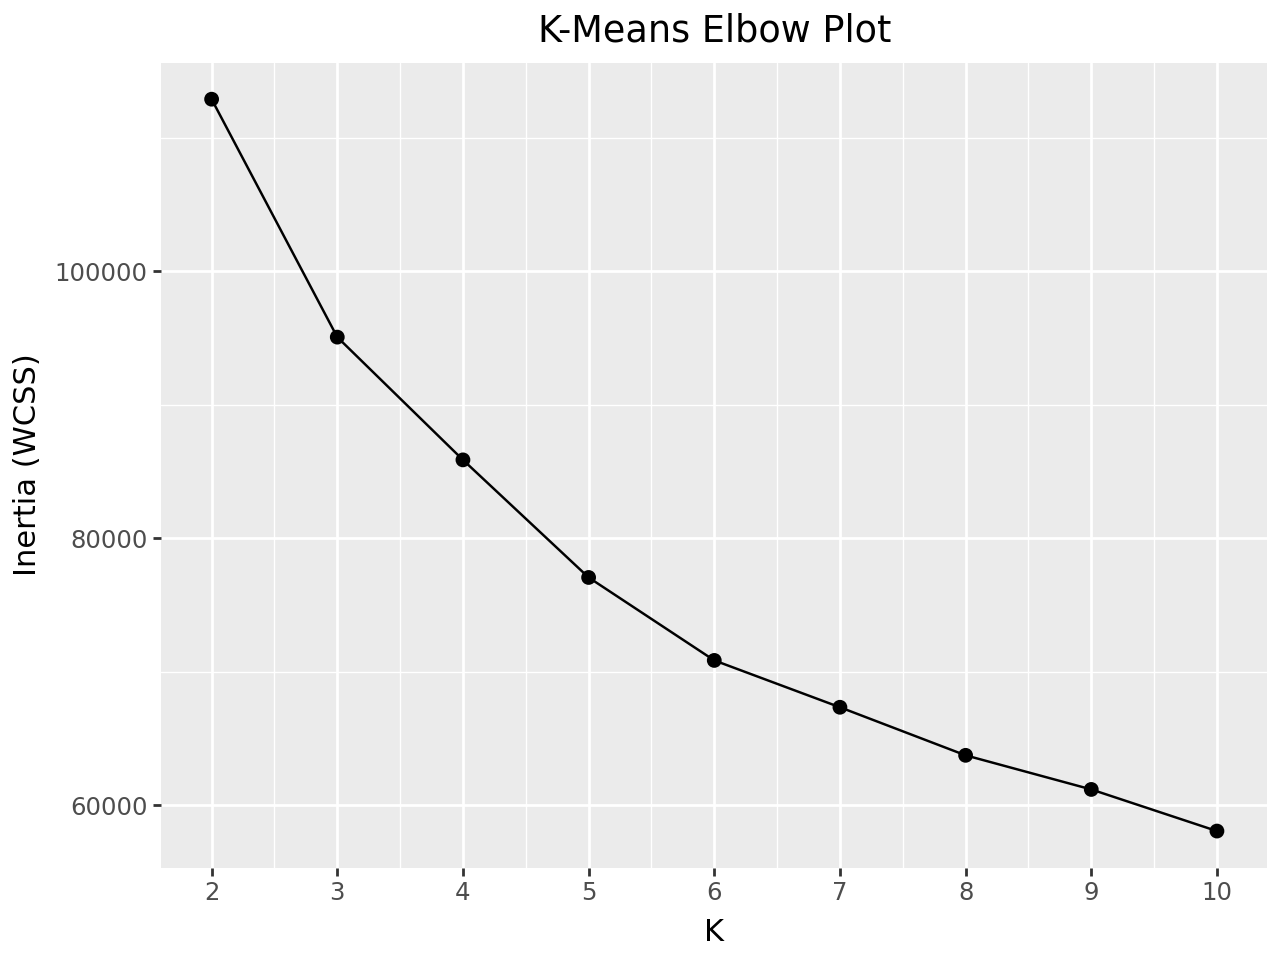

In [239]:
(
    pln.ggplot(kmeans_diag_df, pln.aes(x="k", y="inertia"))
    + pln.geom_line() + pln.geom_point(size=2)
    + pln.scale_x_continuous(breaks=list(k_range))
    + pln.labs(title="K-Means Elbow Plot", x="K", y="Inertia (WCSS)")
)

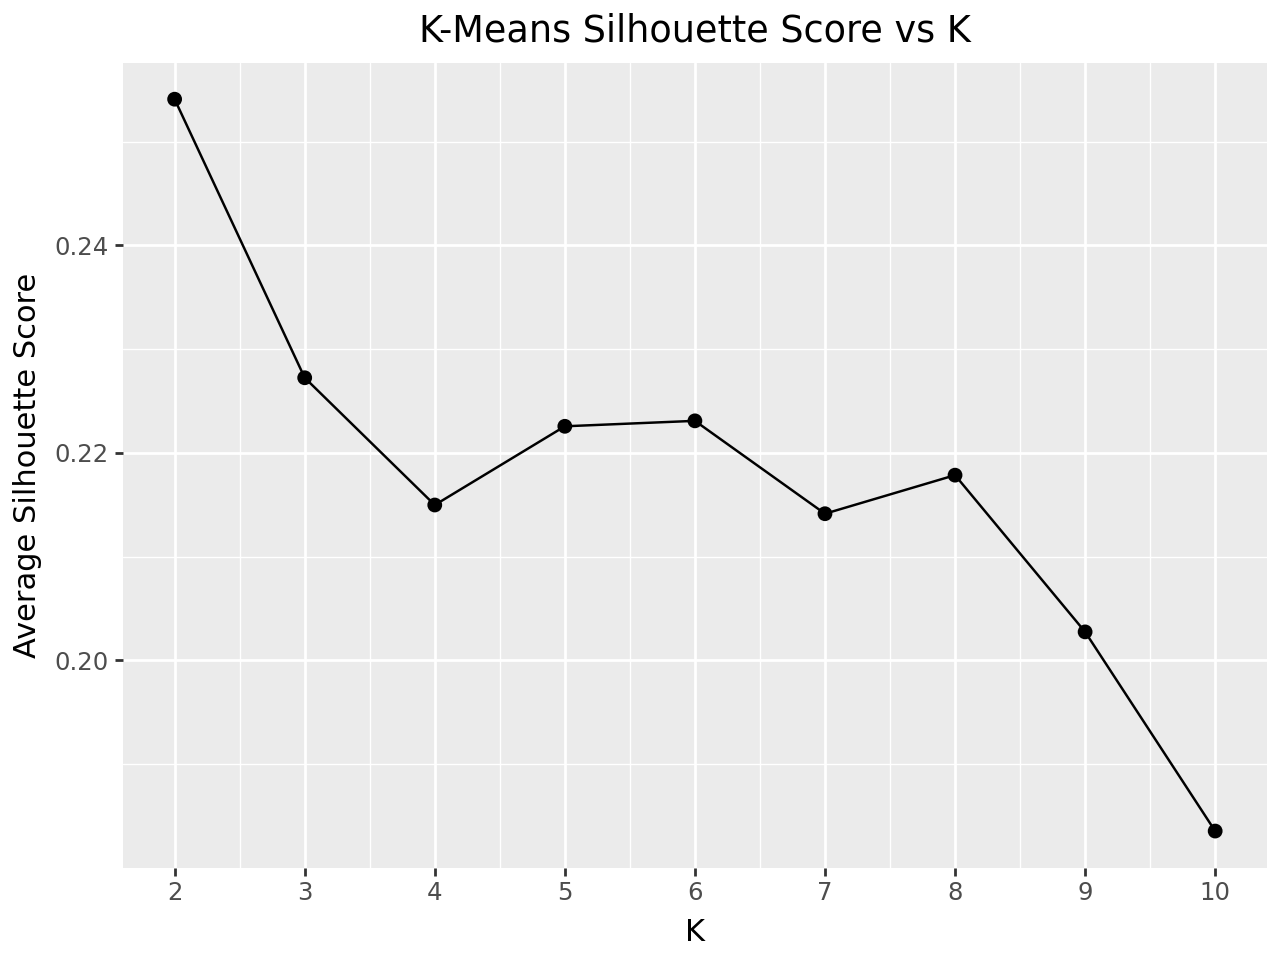

In [240]:
(
    pln.ggplot(kmeans_diag_df, pln.aes(x="k", y="silhouette"))
    + pln.geom_line() + pln.geom_point(size=2)
    + pln.scale_x_continuous(breaks=list(k_range))
    + pln.labs(title="K-Means Silhouette Score vs K", x="K", y="Average Silhouette Score")
)

**Reading the low scores as a finding, not a failure.**

Two things stand out from the diagnostics above, and both point the same direction.
First, the elbow plot shows no sharp corner at all — inertia declines smoothly and
gradually across every K tested, which is itself a signal: a genuinely clustered dataset
usually produces a visible kink where adding clusters stops helping; a smooth decline is
more typical of continuous, ungrouped data. Second, and more tellingly, the *best*
silhouette score obtained (0.254, at K=2) is, in absolute terms, low — silhouette scores
range up to 1.0, and values above roughly 0.5 are generally considered to indicate
reasonably well-separated clusters. A "winning" score this modest means even the most
favorable K found is only weakly supported.

Taken together, these are not signs that the wrong K was chosen, or that the search should
continue further — they are early, converging evidence (later reinforced by DBSCAN in
Section 4.2 and by the evaluation metrics in Section 4.5) that this dataset does not contain
sharply separated clusters at all. The clustering step below is still worth performing and
interpreting — the resulting groups do map onto recognizable customer behavior — but the
low scores are the first hint that those groups should be read as a coarse split of a
continuous spectrum, not as a discovery of genuinely distinct populations.

#### *Fitting K-Means*

$K$ is chosen automatically as the value in the tested range with the highest silhouette
score, rather than picked by eye — this keeps the notebook reproducible end-to-end.

In [241]:
best_k = int(kmeans_diag_df.loc[kmeans_diag_df["silhouette"].idxmax(), "k"])
print(f"Selected K (highest silhouette score): {best_k}")

kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

proj_2d["kmeans_cluster"] = kmeans_labels.astype(str)
proj_2d["kmeans_cluster"].value_counts().sort_index()

Selected K (highest silhouette score): 2


kmeans_cluster
0    3150
1    5800
Name: count, dtype: int64

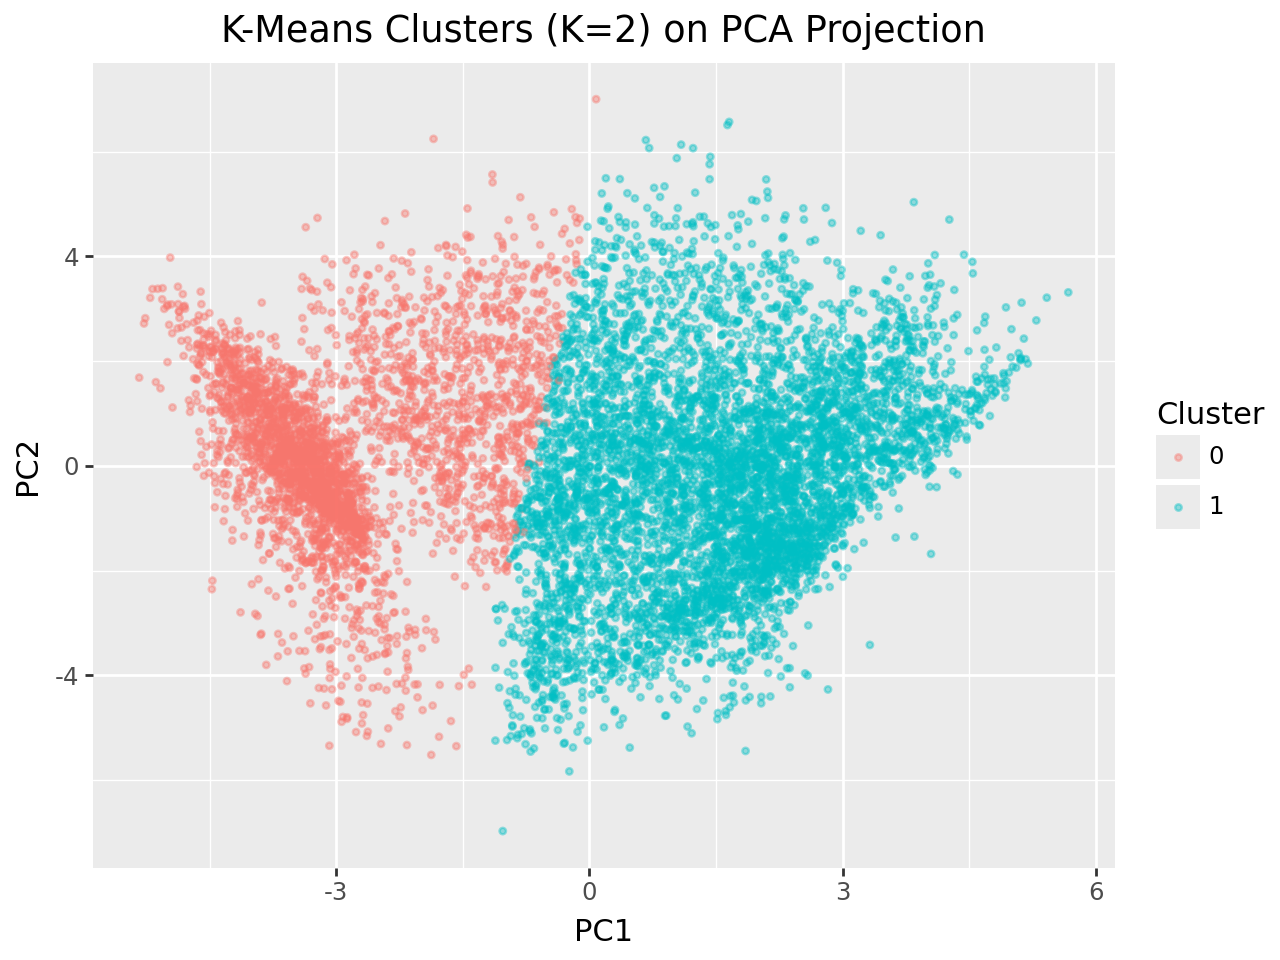

In [242]:
(
    pln.ggplot(proj_2d, pln.aes(x="PC1", y="PC2", color="kmeans_cluster"))
    + pln.geom_point(alpha=0.4, size=0.8)
    + pln.labs(title=f"K-Means Clusters (K={best_k}) on PCA Projection", color="Cluster")
)

#### *Cluster Profiling*

To interpret what each cluster represents in business terms, the mean of each original
(pre-log, pre-scaling) feature is computed per cluster and compared to the global mean.

In [243]:
profile_cols = ["PURCHASES", "PURCHASES_TRX", "CASH_ADVANCE", "BALANCE", "CREDIT_LIMIT",
                 "PRC_FULL_PAYMENT", "TENURE"]

kmeans_profile = df.loc[X_scaled.index, profile_cols].copy()
kmeans_profile["cluster"] = kmeans_labels
cluster_means = kmeans_profile.groupby("cluster").mean()
global_means = df.loc[X_scaled.index, profile_cols].mean()

print("=== Cluster Means ===")
display(cluster_means)
print("\n=== Global Means (reference) ===")
display(global_means)

=== Cluster Means ===


,PURCHASES,PURCHASES_TRX,CASH_ADVANCE,BALANCE,CREDIT_LIMIT,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,
0,150.742546,1.760317,2173.011201,2376.514414,4327.038480,0.038819,11.323492
1,1466.180041,21.742759,330.329513,1123.453328,4585.113262,0.216115,11.622586



=== Global Means (reference) ===


PURCHASES           1003.204834
PURCHASES_TRX         14.709832
CASH_ADVANCE         978.871112
BALANCE             1564.474828
CREDIT_LIMIT        4494.282473
PRC_FULL_PAYMENT       0.153715
TENURE                11.517318
dtype: float64

#### *Discussion — K-Means*



**Selected K=2**, with a silhouette score of 0.254 — clearly higher than every other K
tested (0.18–0.23 for K=3–10). The elbow plot shows no single sharp corner, only a smooth,
gradually flattening decline in inertia, typical of continuous rather than genuinely
clustered data. Silhouette was therefore the deciding signal, and it points toward the
*coarsest* possible split being the most defensible one — not a finer segmentation.

**Cluster profiles are genuinely interpretable, business-wise:**
- **Cluster 0** (3,150 customers, 35%): low purchase activity (`PURCHASES`=151 vs. global
  1,003; `PURCHASES_TRX`=1.8 vs. 14.7) but more than **double** the cash-advance usage
  (`CASH_ADVANCE`=2,173 vs. 979) and a very low full-payment rate (3.9% vs. 15.4%).
- **Cluster 1** (5,800 customers, 65%): high purchase activity (`PURCHASES`=1,466,
  `PURCHASES_TRX`=21.7), low cash-advance usage (330), higher full-payment rate (21.6%).

This maps directly onto the negative correlation between purchase and cash-advance
activity first flagged in Section 2, and onto PC1 (the "purchase activity" axis) from
Section 3 — a "purchase-oriented / responsible payer" segment vs. a "cash-advance-heavy /
revolving-debt" segment.

**But the PCA scatter tells a more cautious story.** The two clusters form a near-perfect
vertical cut through PC1, with **no visible density gap** between them — one continuous
cloud, bisected. This is exactly what K-Means' centroid-based, spherical assumption
predicts it will do even on data with no genuine separation: every point must be assigned
to its nearest centroid regardless of whether a true gap exists. The interpretable cluster
profiles above are therefore better read as **two ends of one continuous spending-style
spectrum** that K-Means has split at its approximate midpoint, not as evidence of two
naturally distinct customer populations. Section 4.2 (DBSCAN) below tests this reading
directly, since density-based clustering is not forced to split continuous data the way
K-Means is.

### *4.2 DBSCAN*

#### *Mathematical introduction*



DBSCAN (Density-Based Spatial Clustering of Applications with Noise) defines clusters
through local point density rather than distance to a centroid, using two parameters:
`eps` ($\epsilon$, a radius) and `min_samples`.

For a point $p$, its $\epsilon$-neighborhood is $N_\epsilon(p) = \{q : \|p - q\| \le
\epsilon\}$. Points are classified as:
- **Core point**: $|N_\epsilon(p)| \ge \text{min\_samples}$ (has enough neighbors nearby).
- **Border point**: not core itself, but lies within $\epsilon$ of a core point.
- **Noise point**: neither — assigned cluster label $-1$, i.e. explicitly excluded from
  every cluster rather than forced into the nearest one. This is a direct conceptual
  preview of Section 5: DBSCAN performs a form of density-based anomaly flagging as a
  byproduct of clustering itself.

Clusters are then the connected components formed by chaining density-reachable core
points together (and attaching their border points) — this is what allows DBSCAN to
discover **arbitrarily shaped** (non-convex) clusters, unlike K-Means' implicit spherical
assumption.

**Key assumptions.** DBSCAN assumes a single global density threshold is meaningful for
the whole dataset — it struggles when genuine clusters have very different densities from
one another. It is still fundamentally distance-based (Euclidean here), so — like every
method in this section — it remains subject to the curse of dimensionality discussed
further in Section 7. No $K$ is required upfront, but `eps`/`min_samples` play an
analogous role and must still be chosen.

#### *Choosing eps: k-distance Plot*



`min_samples` is set using the common rule of thumb $2 \times p$ (twice the number of
features) — a standard heuristic from the original DBSCAN literature for reasonably
low-to-moderate dimensional data. `eps` is then chosen from the **k-distance plot**: for
every point, compute the distance to its `min_samples`-th nearest neighbor, sort these
distances ascending, and look for the "knee" — the point where distances start increasing
sharply, marking the transition from dense, cluster-like regions to sparser, noise-like
regions. The knee is located automatically here using the standard geometric ("kneedle")
approach: normalizing both axes to [0,1] and finding the point of maximum distance from
the straight line connecting the curve's endpoints.

> **Note on methodology — independent research.** DBSCAN cannot run at all without first
> fixing `eps` and `min_samples`, and neither parameter, nor any method for choosing them,
> was covered in the course material. The `min_samples = 2 × (number of features)`
> heuristic and the k-distance/"knee" approach to choosing `eps` were both researched
> independently for this reason — not to add complexity for its own sake, but because the
> algorithm is unusable without settling on values for these two parameters first. The
> automatic "knee" detection method used below to pick `eps` from the k-distance plot
> (finding the point of maximum distance from the line connecting the curve's endpoints)
> is a further piece of independent research on top of that: I looked for a way to choose
> `eps` objectively rather than just by eye, searching online and consulting an AI tool,
> and found this geometric approach as a standard solution to exactly that problem.

min_samples = 2 x 17 features = 34
Selected eps (knee point): 2.2344


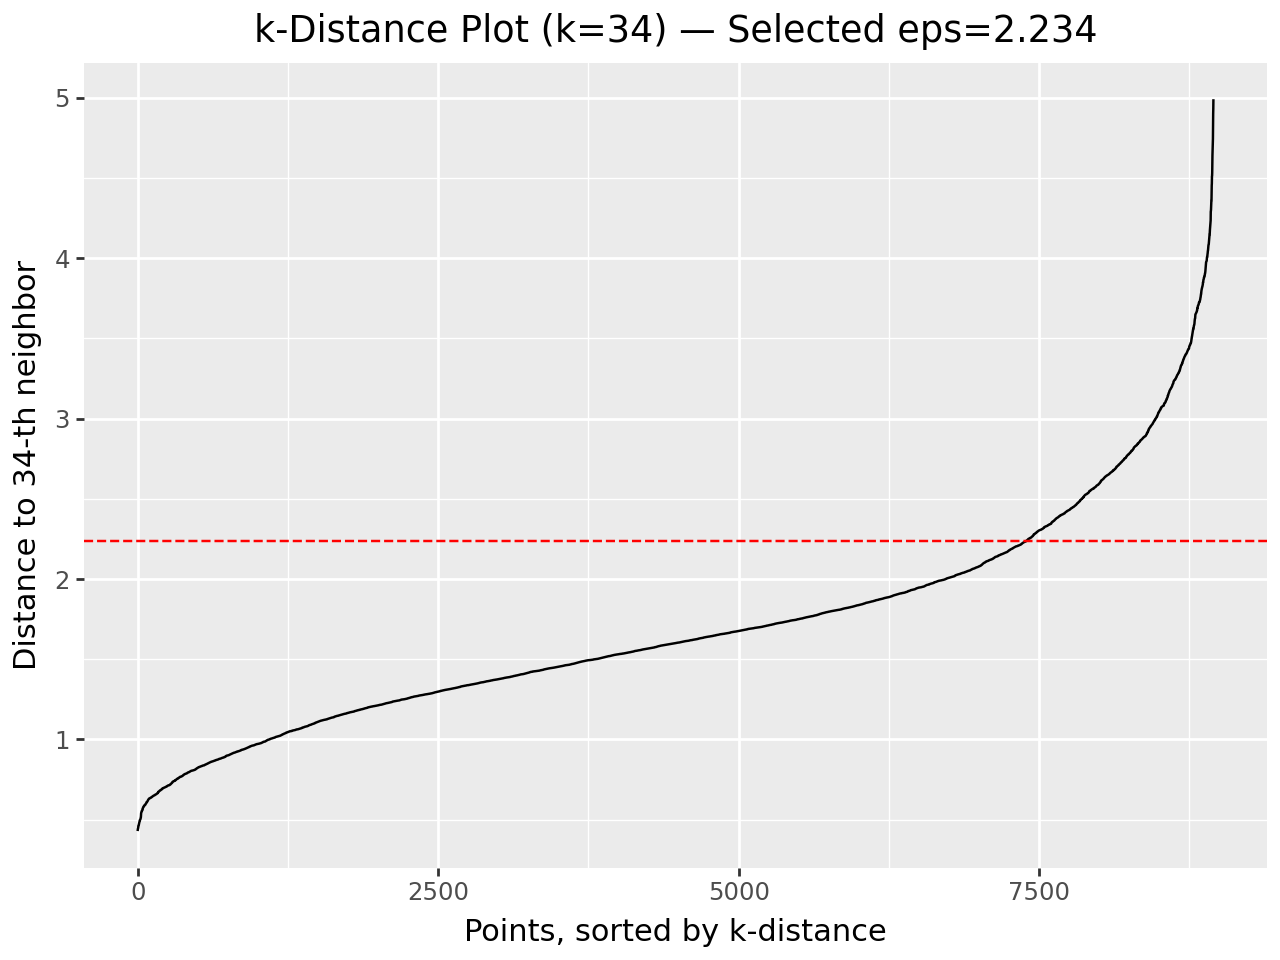

In [244]:
from sklearn.neighbors import NearestNeighbors

min_samples_dbscan = 2 * X_scaled.shape[1]
print(f"min_samples = 2 x {X_scaled.shape[1]} features = {min_samples_dbscan}")

nn = NearestNeighbors(n_neighbors=min_samples_dbscan)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# Geometric knee detection: normalize to [0,1], find max perpendicular distance from the
# straight line connecting the first and last points of the sorted curve
x_norm = np.linspace(0, 1, len(k_distances))
y_norm = (k_distances - k_distances.min()) / (k_distances.max() - k_distances.min())
line_vec = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
line_vec_norm = line_vec / np.linalg.norm(line_vec)
diffs = np.column_stack([x_norm - x_norm[0], y_norm - y_norm[0]])
proj_lengths = diffs @ line_vec_norm
proj_points = np.outer(proj_lengths, line_vec_norm)
perp_dists = np.linalg.norm(diffs - proj_points, axis=1)
knee_idx = np.argmax(perp_dists)

chosen_eps = k_distances[knee_idx]
print(f"Selected eps (knee point): {chosen_eps:.4f}")

kdist_df = pd.DataFrame({"index": range(len(k_distances)), "k_distance": k_distances})
(
    pln.ggplot(kdist_df, pln.aes(x="index", y="k_distance"))
    + pln.geom_line()
    + pln.geom_hline(yintercept=chosen_eps, linetype="dashed", color="red")
    + pln.labs(title=f"k-Distance Plot (k={min_samples_dbscan}) — Selected eps={chosen_eps:.3f}",
               x="Points, sorted by k-distance", y=f"Distance to {min_samples_dbscan}-th neighbor")
)

In [245]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=chosen_eps, min_samples=min_samples_dbscan)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"Clusters found: {n_clusters_dbscan}")
print(f"Noise points: {n_noise} ({n_noise/len(dbscan_labels):.1%} of the data)")

proj_2d["dbscan_cluster"] = pd.Categorical(dbscan_labels.astype(str))
proj_2d["dbscan_cluster"].value_counts().sort_index()

Clusters found: 2
Noise points: 625 (7.0% of the data)


dbscan_cluster
-1     625
0     8286
1       39
Name: count, dtype: int64

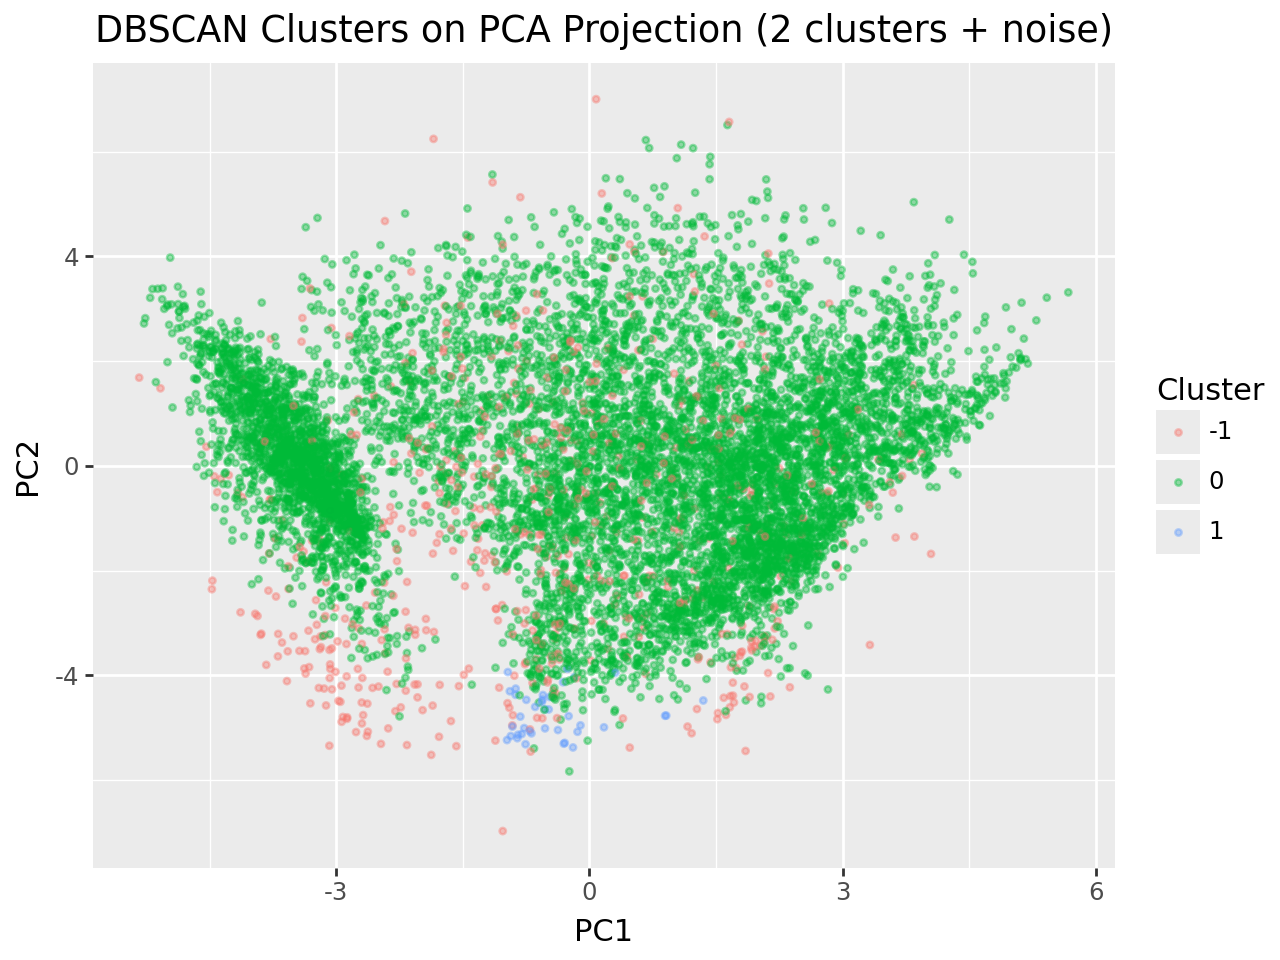

In [246]:
(
    pln.ggplot(proj_2d, pln.aes(x="PC1", y="PC2", color="dbscan_cluster"))
    + pln.geom_point(alpha=0.4, size=0.8)
    + pln.labs(title=f"DBSCAN Clusters on PCA Projection ({n_clusters_dbscan} clusters + noise)",
               color="Cluster")
)

#### *Discussion — DBSCAN*



With `min_samples=34` (2×17 features) and `eps=2.234` (automatic knee detection — though
the k-distance plot shows a fairly gradual bend rather than one sharp corner, so the exact
value carries some genuine ambiguity), DBSCAN finds **2 clusters**: one enormous
(**8,286 points, 92.6%**) and one tiny (**39 points, 0.44%**), plus **625 noise points
(7.0%)**.

The 7.0% noise rate sits within the same order of magnitude as the IQR-based outlier rates
from Section 2 (0%–16.7% depending on feature) — but it is measuring something
conceptually different: a genuinely multivariate, density-based notion of "unusual" across
all 17 dimensions simultaneously, rather than a per-feature univariate rule.

**This result is qualitatively very different from K-Means', and that difference is the
main finding here.** Rather than splitting the data into two comparably-sized groups,
DBSCAN finds one dominant connected mass with no internal density gap, a small distinct
dense pocket (visible at the bottom of the PCA plot, low PC2 — likely a genuinely unusual
customer subgroup), and noise scattered mostly at the periphery of the cloud. This is
direct, concrete evidence for the "continuous cloud, not multi-modal" interpretation
already suspected from the Section 3 PCA projection: a density-based method, unlike a
centroid-based one, is not *forced* to invent a split where no real gap in density exists
— and here, it largely declines to. This reframes the K-Means result from Section 4.1: its
2-way split is better understood as a variance-minimizing partition imposed on a
continuous gradient, not as independent confirmation of two separate populations.

**Sensitivity:** given how gradual the knee in the k-distance plot is, a moderately
different `eps` could plausibly merge the small secondary cluster into the main one, or
push more borderline points into the noise category — the *existence* of one dominant mass
appears robust, but the precise noise count and secondary cluster are likely sensitive to
the exact parameter choice.

### *4.3 Hierarchical (Agglomerative) Clustering*

#### *Mathematical Background: Bottom-Up Merging (Ward Linkage)*

Agglomerative clustering starts with every point as its own singleton cluster and
repeatedly merges the two **closest** clusters until only one remains, recording the
distance at each merge. The full merge history forms a tree — the **dendrogram** — which
can be "cut" at any height to yield any number of clusters, without rerunning the
algorithm.

Since distance between individual *points* is well-defined but distance between *clusters*
is not, a rule is needed for how to measure it — this is what **Ward's method** (used
below) provides: at each step, merge whichever pair of clusters causes the smallest
possible increase in total within-cluster variance. This is conceptually the closest
analogue to K-Means' own objective (minimizing within-cluster spread), but built bottom-up
and deterministically — no random initialization, unlike K-Means.

**Key assumptions & cost.** Because it shares K-Means' variance-minimizing objective, Ward
linkage inherits similar assumptions about roughly compact clusters. Critically,
hierarchical clustering requires the full pairwise distance matrix — $O(n^2)$ memory and
at least $O(n^2 \log n)$ time — which is why, unlike K-Means and DBSCAN above, it is not
run directly on all 8,950 customers below.


#### *Computational Note: Subsampling for Tractability*

At $n=8{,}950$, the full pairwise distance matrix would have $n(n-1)/2 \approx 40$ million
entries — computationally expensive and, just as importantly, impossible to display as a
readable dendrogram (8,950 leaves cannot be visually inspected). A random subsample of
1,000 customers is used instead, purely for the hierarchical analysis. This is an explicit
methodological trade-off — noted here so it can be weighed directly against K-Means' and
DBSCAN's ability to run on the full dataset in the Discussion below.

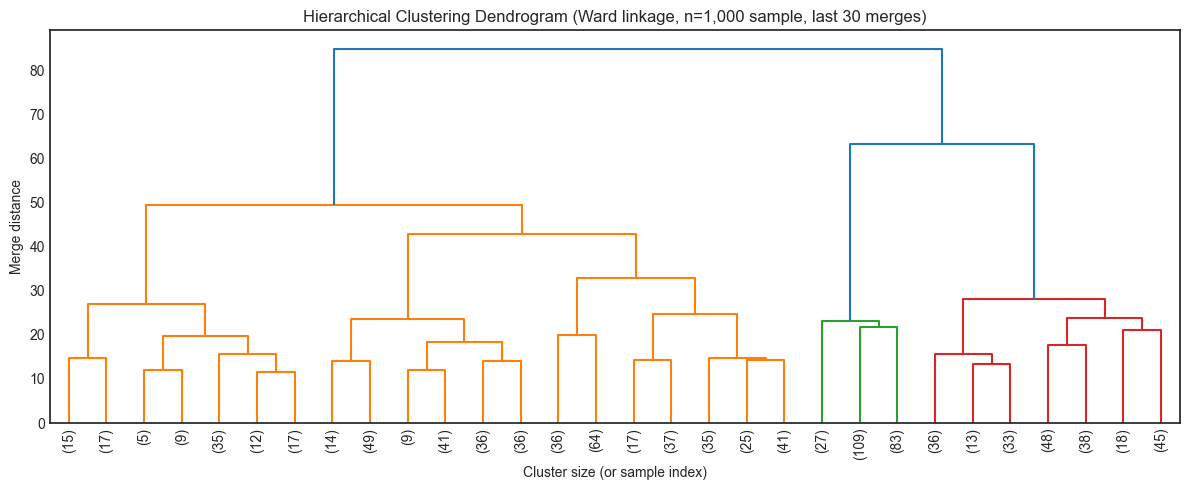

In [247]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

hier_sample_idx = X_scaled.sample(n=1000, random_state=42).index
X_hier_sample = X_scaled.loc[hier_sample_idx]

Z = linkage(X_hier_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, n=1,000 sample, last 30 merges)")
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Merge distance")
plt.tight_layout()
plt.show()

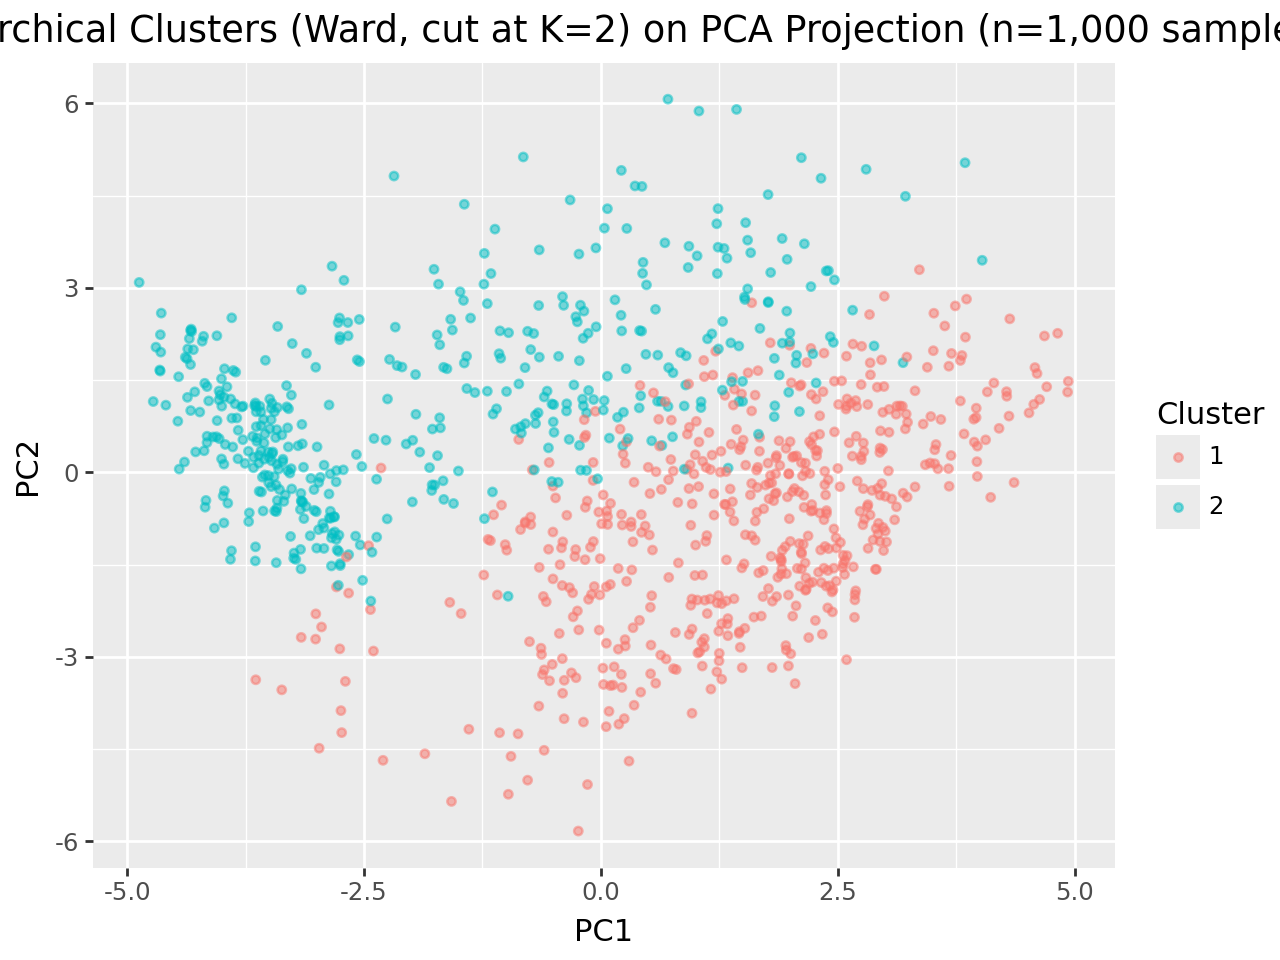

In [248]:
# Cut the dendrogram at the same K selected for K-Means, for direct comparability
hier_labels = fcluster(Z, t=best_k, criterion="maxclust")

proj_2d_hier = proj_2d.loc[hier_sample_idx].copy()
proj_2d_hier["hier_cluster"] = hier_labels.astype(str)

(
    pln.ggplot(proj_2d_hier, pln.aes(x="PC1", y="PC2", color="hier_cluster"))
    + pln.geom_point(alpha=0.5, size=1.2)
    + pln.labs(title=f"Hierarchical Clusters (Ward, cut at K={best_k}) on PCA Projection (n=1,000 sample)",
               color="Cluster")
)

#### *Discussion — Hierarchical Clustering*

Cut at K=2 (matching K-Means) on the 1,000-customer sample, the resulting split is
**qualitatively similar in spirit to K-Means** — roughly along PC1 again. This agreement
is expected rather than coincidental: Ward linkage minimizes within-cluster variance, the
same underlying objective K-Means optimizes directly.

The boundary is visibly **fuzzier** than K-Means' near-clean vertical cut, with more
intermixing of the two colors near PC1≈0. Two likely contributors: Ward linkage operates
in the full 17-dimensional standardized space, so points that look adjacent in this 2D
projection may be genuinely further apart along PC3 or beyond; and the 1,000-point sample
gives a noisier estimate of the true boundary than K-Means had with all 8,950 customers.

In the dendrogram itself, the top-level split (into the two main branches) occurs at a
merge distance of roughly 85, versus mostly under 50 for the internal branch merges beneath
it — a moderately large jump that offers some quantitative support for "2" as a reasonable
cut point, though it is a soft signal rather than one dramatic, isolated gap.

**On the subsampling trade-off:** using 1,000 of 8,950 customers sacrifices precision (the
fuzzier boundary above is direct evidence of this), but was necessary for tractability
given hierarchical clustering's $O(n^2)$ cost. The fact that K-Means (full data) and this
sampled hierarchical run reached a broadly similar 2-way split is reassuring: it suggests
the 1,000-point sample is reasonably representative of the full dataset's structure, rather
than a fluke of the particular random draw.

### *4.4 Clustering on the Feature Space (Transpose)*

So far, clustering has grouped **customers** based on their 17 features. This section
instead clusters the **features themselves**, based on how similarly they behave across
all 8,950 customers — the transpose of the usual setup. Rather than transposing the raw
standardized matrix and using Euclidean distance (which would be sensitive to how each
feature happens to be scaled/transformed), the distance between two features $j$ and $k$ is
defined directly from correlation, reusing the Pearson correlation matrix already computed
in Section 2:

$$d(j,k) = 1 - |\rho_{j,k}|$$

so perfectly correlated (or anti-correlated) features have distance 0, and uncorrelated
features have distance close to 1. Agglomerative clustering (average linkage, appropriate
for an arbitrary precomputed distance matrix — Ward linkage specifically requires true
Euclidean distances) is then applied to this $17\times17$ distance matrix — tiny compared
to the customer-clustering case above, so no subsampling is needed here.

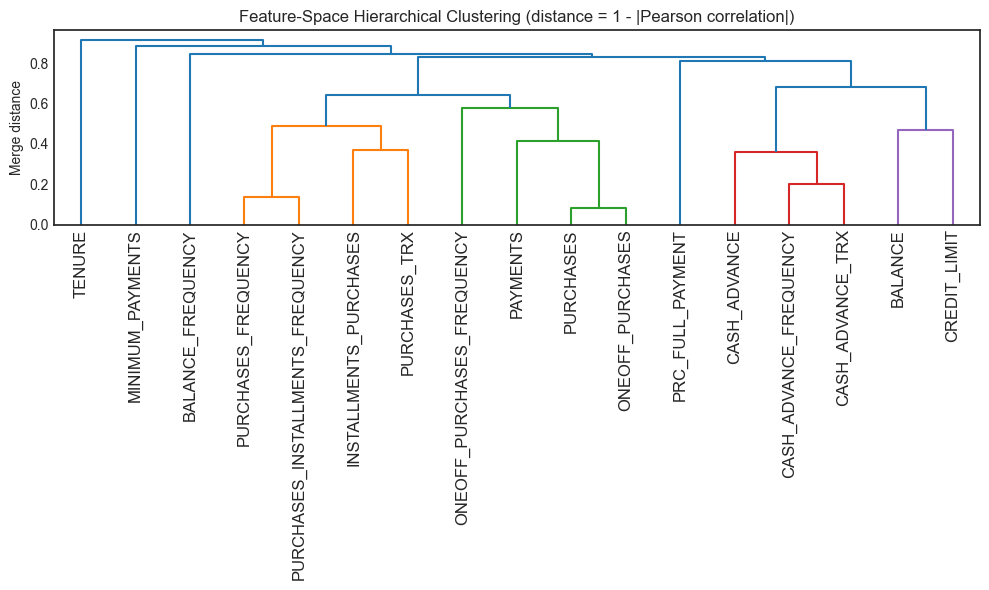

In [249]:
from scipy.spatial.distance import squareform

feature_corr = pearson_corr.loc[pca_features, pca_features]
feature_dist = 1 - feature_corr.abs()

dist_array = feature_dist.to_numpy(copy=True)  # force a writable copy
np.fill_diagonal(dist_array, 0)  # numerical safety: exact zero on the diagonal

condensed_dist = squareform(dist_array, checks=False)
Z_features = linkage(condensed_dist, method="average")

plt.figure(figsize=(10, 6))
dendrogram(Z_features, labels=feature_dist.columns.tolist(), leaf_rotation=90)
plt.title("Feature-Space Hierarchical Clustering (distance = 1 - |Pearson correlation|)")
plt.ylabel("Merge distance")
plt.tight_layout()
plt.show()

#### *Discussion — Feature-Space Clustering*

The dendrogram recovers four clear, tight feature groups, plus two (arguably three)
notably isolated features:

1. **Installment/frequency purchase group** — `PURCHASES_FREQUENCY`,
   `PURCHASES_INSTALLMENTS_FREQUENCY`, `INSTALLMENTS_PURCHASES`, `PURCHASES_TRX` (merging
   at very low distances, ~0.15–0.5).
2. **One-off/total purchase group** — `ONEOFF_PURCHASES_FREQUENCY`, `PAYMENTS`,
   `PURCHASES`, `ONEOFF_PURCHASES`.
3. **Cash-advance group** — `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`,
   `CASH_ADVANCE_TRX` (tight, ~0.2–0.36).
4. **Balance/credit-capacity pair** — `BALANCE`, `CREDIT_LIMIT` (~0.47).

Groups 1 and 2 merge into one larger "overall purchase behavior" supercluster at a
moderate distance (~0.6–0.65) — closely matching PC1 (purchase activity) and PC3
(one-off vs. installment contrast) from Section 3's loadings. This is a genuinely
independent confirmation of that structure, arrived at through a completely different
route: pairwise correlation distance rather than variance-maximizing linear combinations.

**Two features stand nearly completely isolated**, merging only at the very top of the
tree (distance > 0.83): `TENURE` and `BALANCE_FREQUENCY`. Both were already flagged in
Section 2 as having unusual, near-constant/ceiling-heavy distributions (`TENURE` stuck
near 12, `BALANCE_FREQUENCY` stuck near 1.0) — this is independent confirmation, via a
completely different method, that these two features carry little shared behavioral
signal with the rest of the dataset.

**One genuinely new finding, not obvious from Section 3 alone:** `MINIMUM_PAYMENTS` also
merges quite late (~0.88), nearly as isolated as `TENURE`/`BALANCE_FREQUENCY` — despite
loading moderately on PC2 in the Section 3 PCA (alongside `BALANCE`, `BALANCE_FREQUENCY`,
`PAYMENTS`). This is a real point of tension between the two analyses: PCA groups features
by how they *jointly* co-vary along one dominant direction of maximum variance, while this
correlation-distance clustering groups features by *pairwise* correlation strength alone —
a feature can contribute meaningfully to a shared principal component without being
strongly pairwise-correlated with any single other feature. Feature-space clustering
surfaced something the PCA loadings alone did not make obvious.

**Where this is useful more broadly:** beyond this dataset, feature-space clustering is a
fast, interpretable way to spot redundant/duplicate-information features (useful for
feature selection before modeling) and to flag features that are behaviorally "orphaned"
from the rest of a dataset (worth double-checking for data-quality issues, as already done
for `TENURE` in Section 1). This is particularly valuable in domains with many raw
sensor/metric columns — IoT/sensor data, financial reporting metrics, survey batteries —
where redundant instruments or highly correlated indicators are common and worth
consolidating before further analysis.

### *4.5 Evaluation: Within-Cluster Variance vs. Global Variance*

One natural evaluation metric, as suggested by the assignment, is to compare each
cluster's internal variance to the dataset's overall (global) variance:

$$\text{ratio} = \frac{\frac{1}{K}\sum_{k=1}^{K} \text{Var}(C_k)}{\text{Var}(X)}$$

where $\text{Var}(\cdot)$ is computed as the trace of the (per-feature) variance — i.e. the
average squared distance of points to their own cluster's centroid, versus to the global
centroid. A ratio close to 0 means clusters are tight relative to the overall data spread
(strong internal cohesion); a ratio close to 1 means clusters are about as spread out as
the data itself (little benefit from clustering at all).

**A caveat worth flagging before looking at the numbers:** this metric is mathematically
almost identical to what K-Means *directly optimizes* (WCSS, normalized by total variance —
essentially $1 - R^2$ in the ANOVA sense). Using it to judge K-Means is somewhat circular —
of course the algorithm that explicitly minimizes this quantity will score well on it. It
is a much less natural fit for DBSCAN (which optimizes density-reachability, not variance,
and explicitly excludes noise points — how they should be handled when computing "global"
variance is not obvious) or for non-Ward hierarchical linkage. The **silhouette score**
(already used for K-Means' own $K$ selection above) is a fairer alternative here: it does
not assume any particular clustering objective, rewards both cohesion *and* separation
rather than cohesion alone, and is computed identically regardless of which algorithm
produced the labels.

> **Note on methodology — independent research.** The assignment itself asks: *"Is this
> [variance-ratio] metric suitable? If so, explain. Otherwise, provide an alternative."*
> The silhouette score was researched independently specifically to answer that question
> — it was not covered in the course material, but it directly addresses the caveat raised
> above (a metric that does not structurally favor whichever algorithm happens to share
> its objective).

In [250]:
def variance_ratio(X, labels):
    valid = labels != -1  # exclude DBSCAN noise, if present
    X_valid, labels_valid = X[valid], labels[valid]
    global_var = np.mean(np.sum((X_valid - X_valid.mean(axis=0))**2, axis=1))
    within_var = 0
    for lab in np.unique(labels_valid):
        cluster_pts = X_valid[labels_valid == lab]
        within_var += np.sum((cluster_pts - cluster_pts.mean(axis=0))**2)
    within_var /= valid.sum()
    return within_var / global_var

X_arr = X_scaled.values

eval_rows = [
    {
        "Method": "K-Means",
        "Variance Ratio": variance_ratio(X_arr, kmeans_labels),
        "Silhouette": silhouette_score(X_scaled, kmeans_labels),
        "N Clusters (excl. noise)": len(set(kmeans_labels)),
    },
    {
        "Method": "DBSCAN",
        "Variance Ratio": variance_ratio(X_arr, dbscan_labels),
        "Silhouette": (silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
                       if n_clusters_dbscan > 1 else np.nan),
        "N Clusters (excl. noise)": n_clusters_dbscan,
    },
    {
        "Method": "Hierarchical (n=1,000 sample)",
        "Variance Ratio": variance_ratio(X_hier_sample.values, hier_labels),
        "Silhouette": silhouette_score(X_hier_sample, hier_labels),
        "N Clusters (excl. noise)": len(set(hier_labels)),
    },
]

eval_df = pd.DataFrame(eval_rows).set_index("Method")
eval_df

,Variance Ratio,Silhouette,N Clusters (excl. noise)
Method,,,
K-Means,0.741829,0.254091,2
DBSCAN,0.987821,0.278370,2
"Hierarchical (n=1,000 sample)",0.783781,0.213258,2


#### *Discussion — Evaluation Metric Suitability*

```
                                Variance Ratio   Silhouette   N Clusters
K-Means                              0.742         0.254          2
DBSCAN                                0.988         0.278          2
Hierarchical (n=1,000 sample)         0.784         0.213          2
```

**The two metrics disagree on the winner — exactly as anticipated above.** Variance ratio
ranks K-Means best (0.742, lowest) and DBSCAN worst by a wide margin (0.988, essentially no
tighter than the raw data). Silhouette ranks the *opposite*: DBSCAN highest (0.278),
K-Means second (0.254), Hierarchical last (0.213).

**This is the bias predicted, not a surprise.** K-Means directly minimizes within-cluster
variance, so of course it scores best on a metric measuring exactly that — the near-1.0
ratio for DBSCAN is not really a sign DBSCAN "failed"; it mostly reflects that DBSCAN's
main cluster is 92.6% of the data (Section 4.2), so excluding a bit of noise barely moves
the variance versus the full dataset. Variance ratio is not a fair cross-method comparison
here, confirming the concern raised before running it.

**A further asymmetry worth flagging, visible only now:** DBSCAN's silhouette is computed
only on its non-noise points — it gets to exclude its 625 hardest-to-classify points
(7.0%) before scoring, whereas K-Means must classify and score *every* point, including
any that fit poorly. This partly inflates DBSCAN's silhouette advantage and means even the
"fairer" metric is not perfectly apples-to-apples across these methods.

**Conclusion on suitability:** the assignment's suggested variance-ratio metric is
demonstrably **not suitable** for a fair comparison across algorithms with different
objectives — it mechanically favors whichever method optimizes variance directly.
Silhouette score is the better alternative in general (objective-agnostic, rewards
separation as well as cohesion), but even it requires care when comparing a method that
discards outliers (DBSCAN) against one that must classify every point (K-Means).

### *4.6 Side-by-Side Comparison on PCA Projection*

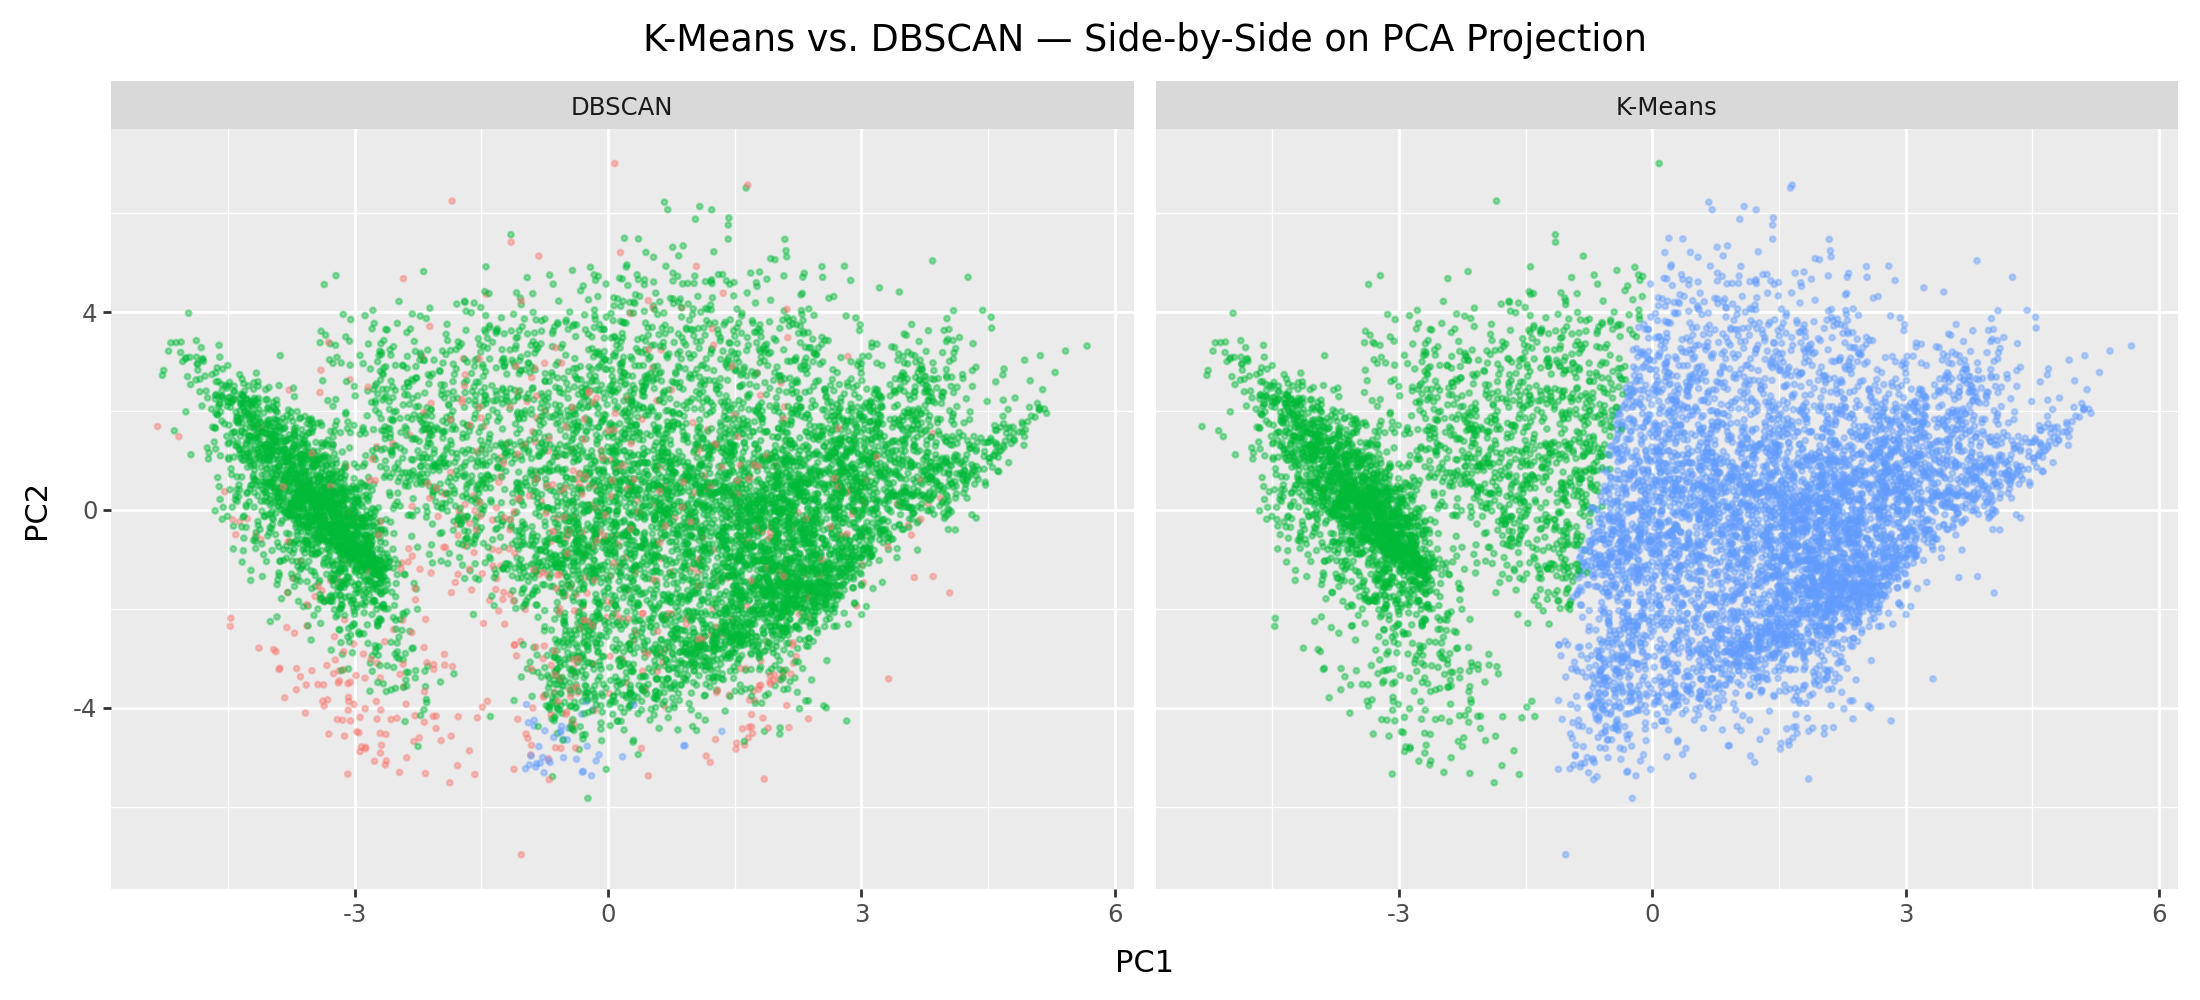

In [251]:
compare_df = proj_2d[["PC1", "PC2", "kmeans_cluster", "dbscan_cluster"]].copy()
compare_long = compare_df.melt(id_vars=["PC1", "PC2"], var_name="method", value_name="cluster")
compare_long["method"] = compare_long["method"].map({
    "kmeans_cluster": "K-Means", "dbscan_cluster": "DBSCAN"
})

(
    pln.ggplot(compare_long, pln.aes(x="PC1", y="PC2", color="cluster"))
    + pln.geom_point(alpha=0.4, size=0.6)
    + pln.facet_wrap("~method")
    + pln.theme(figure_size=(11, 5), legend_position="none")
    + pln.labs(title="K-Means vs. DBSCAN — Side-by-Side on PCA Projection")
)

### *Discussion — Clustering Analysis*

**Why different algorithms produce different clusters — directly demonstrated here.**
K-Means (variance-minimizing, centroid-based) and Ward-linkage Hierarchical (also
variance-minimizing) produced *qualitatively similar* 2-way splits along PC1, because they
share essentially the same mathematical objective. DBSCAN (density-connectivity-based)
produced a *qualitatively different* picture entirely — visible directly in the
side-by-side plot: one dominant connected mass (green, both panels) plus scattered noise
(red) on the left, versus a clean near-vertical bisection on the right. The evaluation
metrics confirm this split extends to how each method should even be *judged*: variance
ratio (K-Means 0.742 vs. DBSCAN 0.988) and silhouette (DBSCAN 0.278 vs. K-Means 0.254)
rank the two methods in opposite order, because each metric implicitly favors whichever
objective a given algorithm was built to optimize.

**Cluster geometry / density-based vs. centroid-based — the central finding of this
section.** The K-Means and Hierarchical splits look interpretable (mapping cleanly onto
purchase-activity vs. cash-advance-activity segments, consistent with Sections 2–3), but
the PCA scatter shows no visible density gap between them — a continuous cloud, cut roughly
through its middle. DBSCAN, which is not forced to partition data lacking a true gap, mostly
declined to split it, finding one dominant mass instead (92.6% of points), a tiny distinct
pocket (0.44%), and periphery noise (7.0%). Together, this is fairly strong evidence that
the "clusters" found by the centroid-based methods reflect a continuous gradient in
spending style (running along PC1) rather than genuinely separated customer populations.

**Sensitivity to hyperparameters.** K-Means' silhouette score clearly favored K=2 over any
finer segmentation (K=3–10 all scored markedly lower, 0.18–0.23) — itself a signal that
finer structure is not well supported by this data. DBSCAN's result likely depends more
delicately on the exact `eps` (the k-distance plot's knee was gradual, not sharp); a
moderately different value could plausibly have merged its small secondary cluster into
the main one or shifted the noise count.

**Situations where clustering may fail — and why that is a legitimate finding, not a
shortcoming.** Per the assignment's own framing, the evidence assembled across Sections 3
and 4 (a single continuous, unimodal PCA cloud; K-Means' silhouette peaking at the
coarsest possible K; DBSCAN finding one connected mass rather than separated groups; and
now, two evaluation metrics that cannot even agree on a winner because there is no
objectively "correct" notion of cluster quality here) points toward a dataset whose
customer behavior varies continuously along a small number of interpretable axes (purchase
activity, cash-advance usage) rather than falling into naturally discrete segments. The
two-cluster labelings produced above remain useful as an approximate, interpretable summary
of that gradient — but should not be over-read as evidence of genuinely distinct customer
types.

## *5. Multi-Dimensional Anomaly Detection*

#### *Preprocessing Note*

All three methods below use `X_scaled` (the same 17-dimensional, log1p + StandardScaler
preprocessed space from Sections 3–4) as the primary feature space, for consistency with
the clustering analysis. In addition, a reduced 8-component PCA space (capturing 90% of
variance, per the Section 3 scree plot) is built here specifically to empirically test the
curse-of-dimensionality question raised earlier: does dimensionality reduction actually
change what LOF — the most distance-sensitive of the three methods — flags as anomalous?

In [252]:
# Reduced feature space: first 8 PCs (90% of variance), reusing the already-fitted pca_full
X_pca_8 = pca_full.transform(X_scaled)[:, :8]
print(f"Full space: {X_scaled.shape[1]} dimensions | Reduced space: {X_pca_8.shape[1]} dimensions")

Full space: 17 dimensions | Reduced space: 8 dimensions


### *5.1 Z-Score Method*

#### *Building Intuition Before the Formulas*

**The basic idea.** Imagine measuring everyone's height in a room. Most people cluster
within a normal range; someone noticeably taller or shorter than everyone else "stands
out." The Z-score just makes this precise: it counts **how many standard deviations away**
from the average a value sits. A Z-score of 0 means "exactly average"; a Z-score of 3 means
"quite far out — the kind of value that would only show up rarely by chance alone."

**Why checking one feature at a time isn't the whole picture.** A customer's `CASH_ADVANCE`
alone might be unremarkable, and their `TENURE` alone might be unremarkable — but a
brand-new customer (very low tenure) with an unusually large cash advance right away could
be a meaningful *combination*, even though neither number crosses the line on its own. This
is the same intuition as a doctor judging whether someone is overweight: neither height nor
weight alone tells you much, but the *combination* (BMI) does. Feature-wise Z-score checks
each measurement in isolation — a circle of "normal" drawn separately around each feature.
Mahalanobis distance instead draws one **elliptical** region of "normal" around the whole
combination at once, stretched or tilted according to how the features actually move
together — which is exactly why it needs the correlation structure (the eigenvectors and
eigenvalues) from the PCA in Section 3 to work.

#### *Mathematical Background: Univariate Z-Score & the Multivariate Extension*

For a single feature $x$, the Z-score standardizes it against its own mean and standard
deviation:

$$z = \frac{x - \mu}{\sigma}$$

Under the assumption that $x$ is normally distributed, roughly 99.7% of values fall within
$|z| < 3$ — so a common rule flags any point with $|z| > 3$ on a given feature as an outlier
on that feature. Because `X_scaled` was already produced with `StandardScaler` (Section 3),
it **is** already exactly this — one Z-score column per feature, for free.

**The multiple-testing problem — why this fails in high dimensions.** Flagging a customer
as anomalous if *any one* of 17 features exceeds $|z|>3$ sounds reasonable per feature,
but the false-positive rate compounds across features. For an independent standard normal,
$P(|z|>3) \approx 0.0027$. Across $p=17$ roughly-independent checks, the chance that at
least one exceeds the threshold **purely by chance**, even for a perfectly normal,
non-anomalous customer, is:

$$1 - (1 - 0.0027)^{17} \approx 4.5\%$$

— nearly one in twenty customers would be flagged as an "anomaly" on at least one feature
just from ordinary statistical noise, before any real anomalous behavior is involved. This
is the concrete mechanism behind "Z-score fails in high dimensions": it is not that the
formula breaks, but that checking many features one at a time inflates the false-positive
rate far beyond what the single-feature 3-sigma rule implies.

**A genuinely multivariate alternative: Mahalanobis Distance.** Rather than checking each
feature separately, the Mahalanobis distance measures how far a point is from the center
of the *entire* multivariate distribution at once, accounting for correlations between
features:

$$D_M(x)^2 = \sum_{i=1}^{p} \frac{z_i^2}{\lambda_i}, \qquad z_i = v_i^T(x - \bar{x})$$

where $v_i$ and $\lambda_i$ are exactly the eigenvectors and eigenvalues from the Section 3
PCA — the PC scores of $x$, each divided by its own variance. Since the PCs are
uncorrelated by construction (Section 3), this sum of squared, independently-scaled terms
follows (approximately, under multivariate normality) a **chi-squared distribution with
$p$ degrees of freedom** — giving a principled threshold, unlike the ad-hoc "any feature
past 3" rule above.

> **Note on methodology — independent research.** The assignment explicitly asks for a
> comparison of "feature-wise vs global anomaly detection" under the Z-score method.
> Mahalanobis distance is the standard way to answer the "global" half of that question,
> but neither it nor its chi-squared threshold were covered in the course material, and
> nor was the multiple-testing calculation above explaining why the feature-wise rate
> exceeds the naive 4.5% estimate. All of this was researched independently — the
> eigenvectors/eigenvalues from Section 3's PCA turned out to be exactly the ingredients
> Mahalanobis distance needs, which is why it is used here rather than a different
> "global" method.


In [253]:
# Feature-wise Z-score: X_scaled is already per-feature standardized
z_threshold = 3
feature_wise_flag = (X_scaled.abs() > z_threshold).any(axis=1)

print(f"Feature-wise Z-score anomalies (|z|>{z_threshold} on >=1 of 17 features): "
      f"{feature_wise_flag.sum()} ({feature_wise_flag.mean():.1%})")
(X_scaled.abs() > z_threshold).sum().sort_values(ascending=False)

Feature-wise Z-score anomalies (|z|>3 on >=1 of 17 features): 912 (10.2%)


TENURE                              394
PAYMENTS                            247
BALANCE_FREQUENCY                   176
CASH_ADVANCE_FREQUENCY              133
BALANCE                              93
MINIMUM_PAYMENTS                     90
CASH_ADVANCE_TRX                     29
CREDIT_LIMIT                          9
PURCHASES                             0
PURCHASES_INSTALLMENTS_FREQUENCY      0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_FREQUENCY                   0
CASH_ADVANCE                          0
INSTALLMENTS_PURCHASES                0
ONEOFF_PURCHASES                      0
PURCHASES_TRX                         0
PRC_FULL_PAYMENT                      0
dtype: int64

In [254]:
from scipy.stats import chi2

pc_scores = pca_full.transform(X_scaled)          # all 17 PCs
eigenvalues = pca_full.explained_variance_          # lambda_i

mahalanobis_sq = (pc_scores ** 2 / eigenvalues).sum(axis=1)
chi2_threshold = chi2.ppf(0.975, df=X_scaled.shape[1])  # 97.5th percentile, df=17

mahalanobis_flag = mahalanobis_sq > chi2_threshold
print(f"Mahalanobis anomalies (D^2 > chi2 97.5th percentile = {chi2_threshold:.2f}): "
      f"{mahalanobis_flag.sum()} ({mahalanobis_flag.mean():.1%})")

print(f"\nOverlap between the two methods: "
      f"{(feature_wise_flag.values & mahalanobis_flag).sum()} customers flagged by both")

Mahalanobis anomalies (D^2 > chi2 97.5th percentile = 30.19): 890 (9.9%)

Overlap between the two methods: 545 customers flagged by both


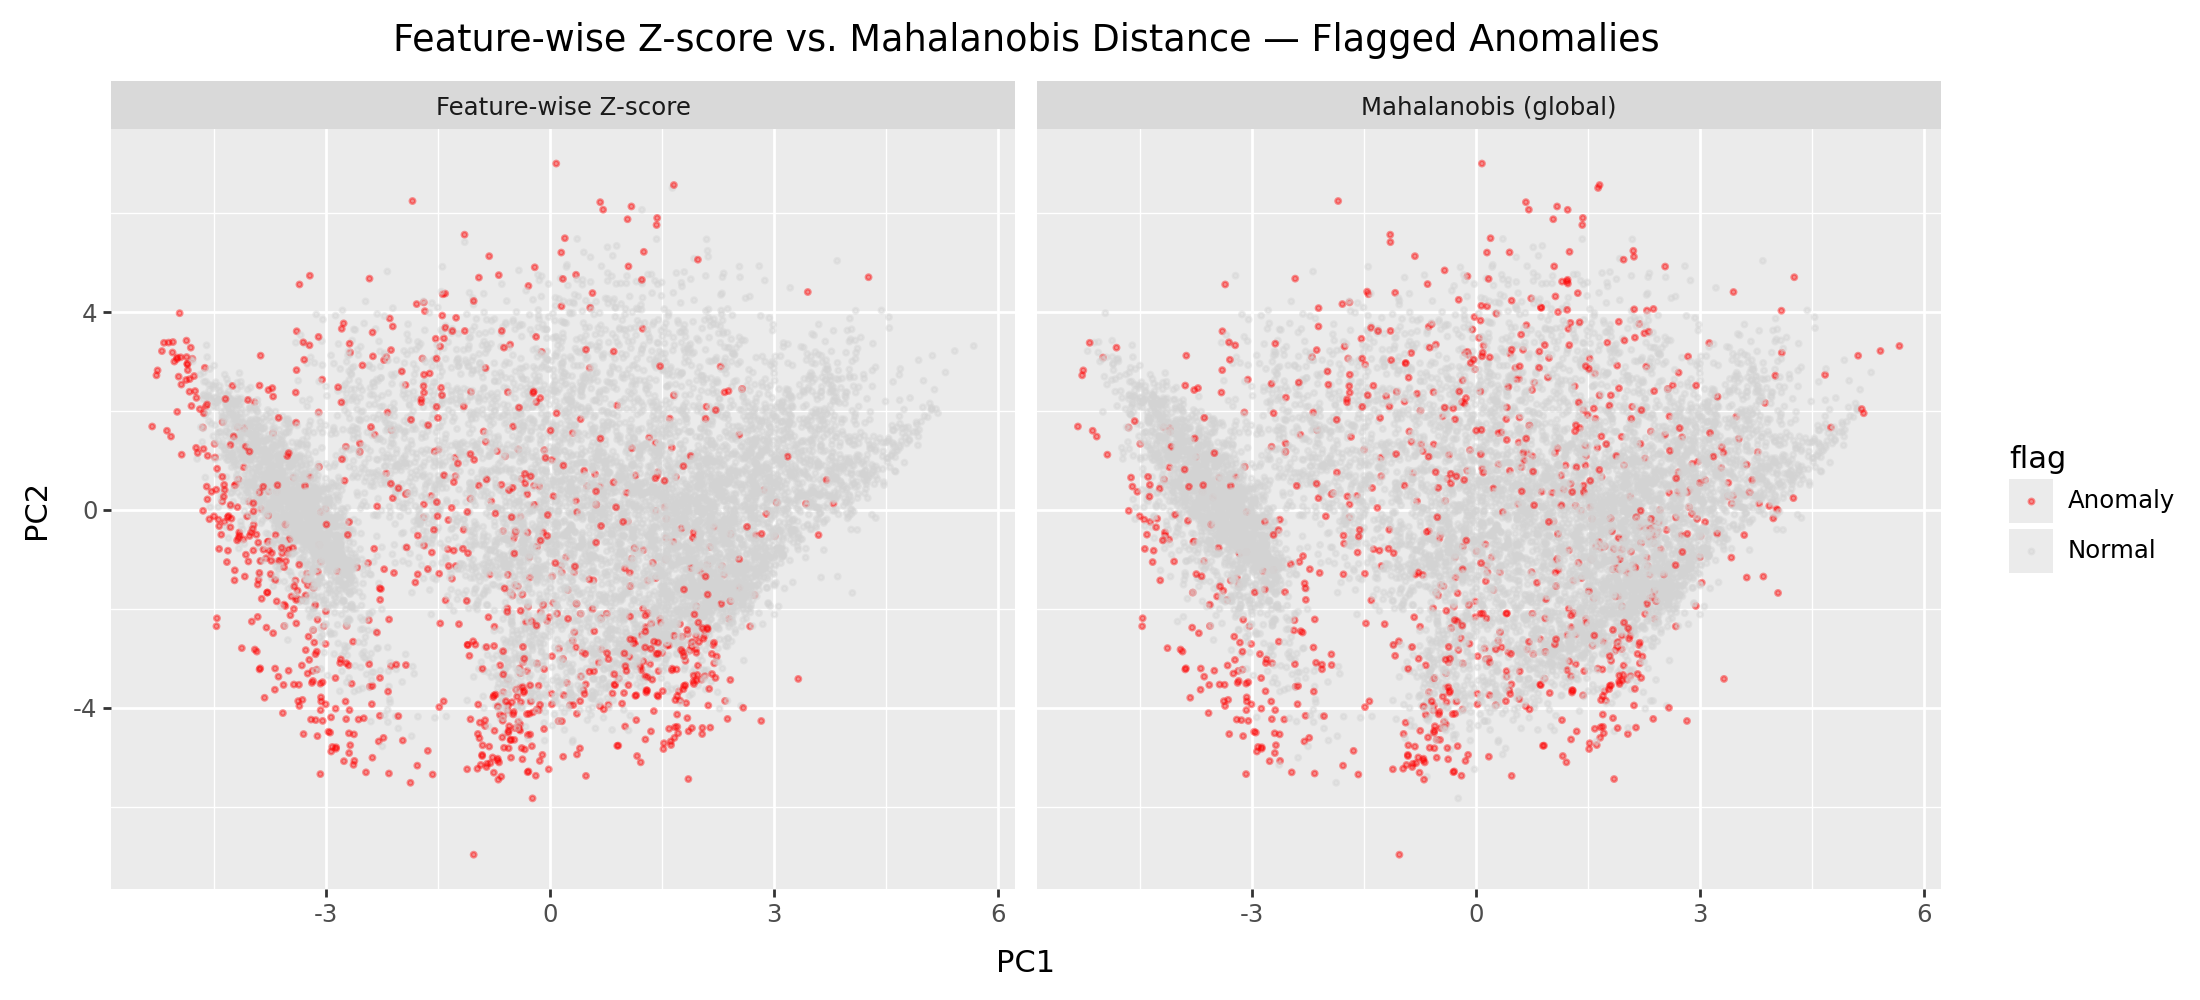

In [255]:
proj_2d["feature_wise_zscore"] = feature_wise_flag.map({True: "Anomaly", False: "Normal"}).values
proj_2d["mahalanobis"] = pd.Series(mahalanobis_flag, index=X_scaled.index).map({True: "Anomaly", False: "Normal"}).values

zscore_compare = proj_2d[["PC1", "PC2", "feature_wise_zscore", "mahalanobis"]].melt(
    id_vars=["PC1", "PC2"], var_name="method", value_name="flag"
)
zscore_compare["method"] = zscore_compare["method"].map({
    "feature_wise_zscore": "Feature-wise Z-score", "mahalanobis": "Mahalanobis (global)"
})

(
    pln.ggplot(zscore_compare, pln.aes(x="PC1", y="PC2", color="flag"))
    + pln.geom_point(alpha=0.4, size=0.6)
    + pln.facet_wrap("~method")
    + pln.scale_color_manual(values={"Normal": "lightgray", "Anomaly": "red"})
    + pln.theme(figure_size=(11, 5))
    + pln.labs(title="Feature-wise Z-score vs. Mahalanobis Distance — Flagged Anomalies")
)

#### *Reading the Results*

912 customers (10.2%) are flagged by at least one feature crossing the 3-sigma line;
890 (9.9%) are flagged by Mahalanobis distance instead. In plain terms: about 1 in 10
customers looks unusual by *some* measure, no matter which of the two methods is used —
but they don't fully agree on *which* 1 in 10. Only 545 customers are flagged by both.
Looking at which single feature is behind each feature-wise flag, `TENURE` alone explains
394 of the 912 — well over a third — with `PAYMENTS`, `BALANCE_FREQUENCY`, and
`CASH_ADVANCE_FREQUENCY` making up most of the rest. Seven features never trigger a flag
at all. In short: feature-wise Z-score is mostly reacting to a small handful of specific
features (especially `TENURE`'s unusual shape), while Mahalanobis is reacting to
*combinations* across all 17 at once — two genuinely different lenses on the same
customers.

#### *Discussion — Z-Score*

**Feature-wise (912, 10.2%) and Mahalanobis (890, 9.9%) flag similar totals, but only
partially agree** — 545 customers are caught by both, meaning 367 are flagged by
feature-wise alone and 345 by Mahalanobis alone. This partial overlap is itself the
answer to the assignment's "feature-wise vs. global" question: the 345 Mahalanobis-only
customers are **multivariate outliers** — no single feature of theirs crosses $|z|>3$, but
their *combination* of values is jointly unusual once correlations are accounted for — a
category of anomaly feature-wise Z-score cannot detect by construction, no matter the
threshold used.

**The per-feature breakdown of the 912 feature-wise flags is the most striking finding
here.** `TENURE` alone accounts for 394 of them — by far the largest contributor — followed
by `PAYMENTS` (247), `BALANCE_FREQUENCY` (176), and `CASH_ADVANCE_FREQUENCY` (133). Meanwhile,
**seven features show exactly zero flags**: `PURCHASES`, `PURCHASES_TRX`,
`ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE`, `ONEOFF_PURCHASES_FREQUENCY`,
and `PRC_FULL_PAYMENT`. This is not random — every one of the zero-flag features was
log-transformed in Section 3 for having skewness > 1, and the transform evidently worked
well enough to pull their extreme tails inside 3 standard deviations entirely. `TENURE` and
`BALANCE_FREQUENCY`, by contrast, are **left-skewed** (Section 2) and were *not*
log-transformed (log1p does not fix left skew) — their ceiling-effect distributions (most
customers bunched near the maximum, a minority trailing far below) are exactly what
produces so many "outliers" here. This is a direct, quantified illustration of the risk
flagged in Section 2's outlier discussion: `TENURE`'s flagged customers are very unlikely
to be genuine anomalies — they are ordinary customers with below-average tenure, made to
look extreme only by the shape of a bounded, ceiling-heavy distribution.

**Gaussianity is violated, and it shows up as a measurable gap, not just a theoretical
concern.** Under a true multivariate normal, independent-testing math predicts roughly
4.5% of points would be flagged by *chance alone* on the feature-wise rule (Section 5.1
background). The observed rate is 10.2% — more than double. That gap is concrete evidence
that the skew remaining even after log-transformation (and the untransformed left-skewed
features) is inflating the feature-wise false-positive rate well beyond what the
multiple-testing math alone would predict for genuinely Gaussian data.

### *5.2 Isolation Forest*

#### *Mathematical Background: Isolation via Random Partitioning*

**The core idea, as an analogy.** Imagine playing a guessing game: repeatedly pick a
random feature and a random split value between its min and max, dividing the data in two.
Keep doing this, splitting whichever group your point ends up in, until it stands alone.
A customer with an extreme, unusual combination of values gets separated from everyone
else after just a **few** random splits — because random cuts are likely to isolate it
almost immediately, since so few other points share its unusual region of the space. A
"typical" customer, surrounded by many similar customers, takes **many** splits to
separate, because random cuts keep landing among its many neighbors instead of around it.

**Formally:** this process builds a random binary tree (an "isolation tree") for each
point, and the **path length** — the number of splits needed to isolate it — is the raw
signal. Averaging path length across many independently-built random trees (the "forest")
gives a stable estimate. The anomaly score is then normalized against $c(n)$, the expected
path length for a uniformly random point in a sample of size $n$ (derived from the
average path length of an unsuccessful binary search):

$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

where $E[h(x)]$ is the average path length for $x$. Scores close to 1 indicate a short
average path (likely anomalous); scores well below 0.5 indicate long paths (likely normal).

> **Note on methodology — independent research.** The assignment explicitly asks to
> "explain how the anomaly score is calculated and interpret what a high or low score
> represents." The $c(n)$ normalization and the exact formula above were not covered in
> the course material and were researched independently in order to answer that
> question precisely, rather than only describing the isolation mechanism in words.

**The `contamination` parameter** sets the expected proportion of anomalies in the data,
which determines the score threshold used to make the final binary anomaly/normal
decision — it does not change the underlying scores themselves, only where the cutoff is
drawn.

**Key strengths/limitations.** Isolation Forest does not rely on distance or density
directly (unlike Z-score/Mahalanobis or LOF below), so it tends to scale better and is less
directly affected by the curse of dimensionality — though the *choice* of random feature at
each split still becomes less informative as dimensionality grows if most features are
uninformative for a given anomaly. It also does not assume any particular data
distribution (no Gaussianity assumption, unlike Z-score).

In [256]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination="auto", random_state=42, n_jobs=-1)
iso_labels = iso_forest.fit_predict(X_scaled)          # 1 = normal, -1 = anomaly
iso_scores = iso_forest.decision_function(X_scaled)     # higher = more normal

n_iso_anomalies = (iso_labels == -1).sum()
print(f"Isolation Forest anomalies (contamination='auto'): "
      f"{n_iso_anomalies} ({n_iso_anomalies/len(iso_labels):.1%})")

Isolation Forest anomalies (contamination='auto'): 2134 (23.8%)


#### *Sensitivity to the Contamination Parameter*

In [257]:
contamination_values = [0.01, 0.05, 0.1]
contamination_rows = []
for c in contamination_values:
    model_c = IsolationForest(contamination=c, random_state=42, n_jobs=-1)
    labels_c = model_c.fit_predict(X_scaled)
    contamination_rows.append({"contamination": c, "n_flagged": (labels_c == -1).sum()})

pd.DataFrame(contamination_rows)

,contamination,n_flagged
0,0.01,90
1,0.05,448
2,0.10,895


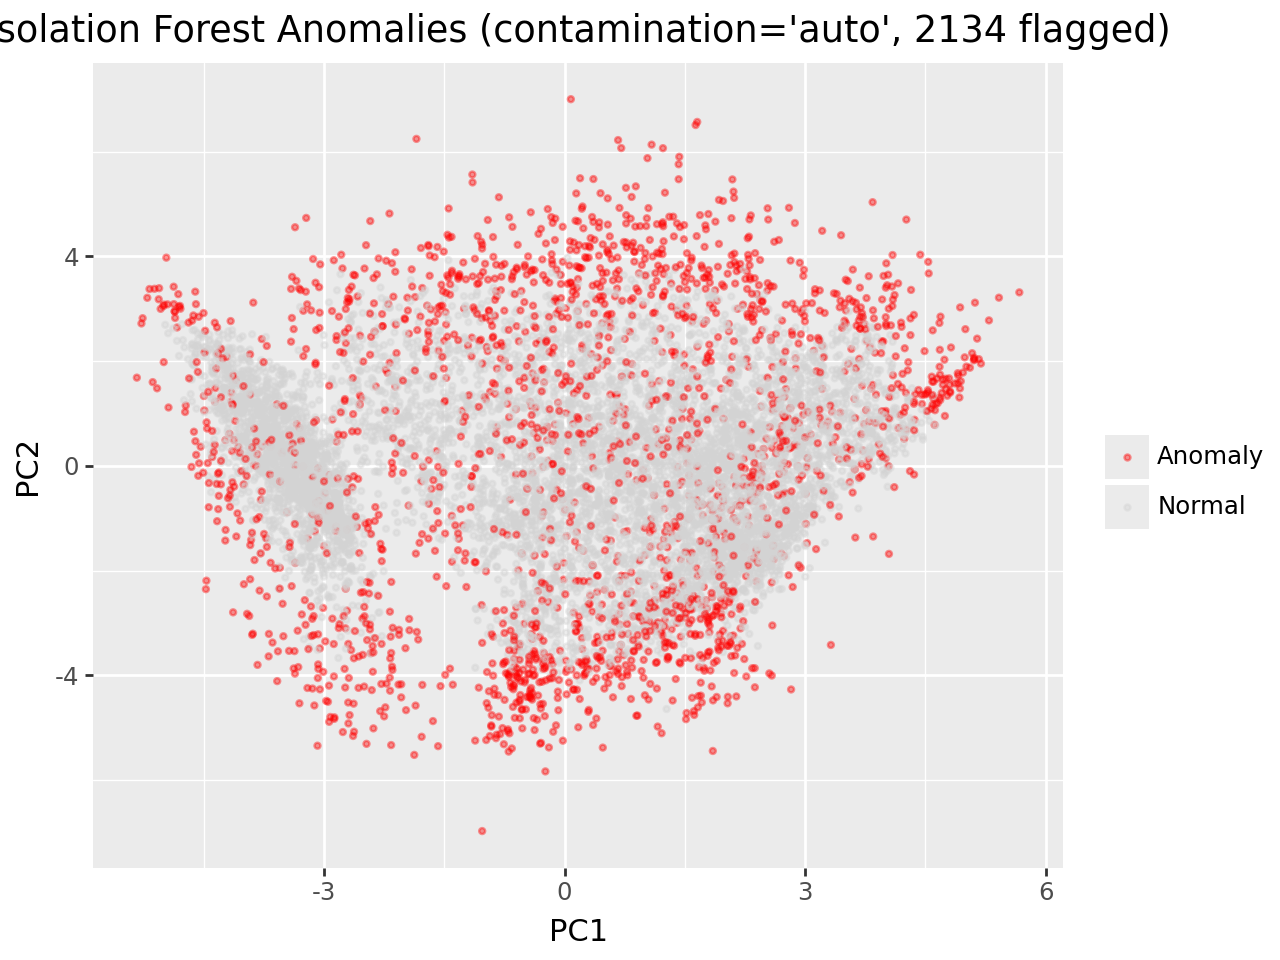

In [258]:
proj_2d["iso_forest_score"] = iso_scores
proj_2d["iso_forest_flag"] = pd.Series(iso_labels, index=X_scaled.index).map({1: "Normal", -1: "Anomaly"}).values

(
    pln.ggplot(proj_2d, pln.aes(x="PC1", y="PC2", color="iso_forest_flag"))
    + pln.geom_point(alpha=0.4, size=0.7)
    + pln.scale_color_manual(values={"Normal": "lightgray", "Anomaly": "red"})
    + pln.labs(title=f"Isolation Forest Anomalies (contamination='auto', {n_iso_anomalies} flagged)",
               color="")
)

#### *Reading the Results*

With `contamination='auto'`, 2,134 customers (23.8%) end up flagged — noticeably more than
any of the manually-tried rates (90 at 1%, 448 at 5%, 895 at 10%). In plain terms: the
"automatic" setting is not a neutral, algorithm-agnostic default — it is itself a modeling
choice, and on this dataset it happens to land on a fairly permissive one. The near-linear
growth across the manual rates (roughly doubling from 5% to 10%) also indicates there is no
obvious natural "cliff" in the anomaly scores separating clear outliers from everyone
else — consistent with the continuous, gradient-like character of this dataset already
seen throughout Sections 3–4, rather than a small, sharply distinct group of outliers.

#### *Discussion — Isolation Forest*

**`contamination='auto'` flagged 2,134 customers — 23.8%, far more than any of the
explicitly-tested rates** (90 at 0.01, 448 at 0.05, 895 at 0.10). This is a useful, slightly
counterintuitive finding in its own right: `'auto'` does not simply pick a "reasonable
default percentage" — it sets the decision threshold using the score-offset formula from
the original Isolation Forest paper, which is a function of the *shape* of the score
distribution, not a fixed target rate. On this particular dataset, that formula lands on a
notably more permissive cutoff than a manually-chosen 10% contamination would. This is a
concrete illustration of why the assignment specifically asks to discuss the contamination
parameter's effect: the "default" is not neutral, and can behave very differently across
datasets depending on how the anomaly scores happen to be distributed.

**The manually-tested rates behave close to linearly** — roughly 90 → 448 → 895 for
0.01 → 0.05 → 0.10, i.e. doubling the contamination rate from 0.05 to 0.10 almost exactly
doubles the flagged count. This suggests the underlying anomaly-score distribution doesn't
have a sharp natural cutoff separating "normal" from "anomalous" — scores decline
smoothly, so the contamination parameter is doing real, direct work in deciding how many
points end up flagged, rather than merely confirming an obvious break in the data. This
echoes the same "continuous, not discretely clustered" character of this dataset already
seen throughout Section 4.

**Advantages actually observed:** Isolation Forest required no distributional assumption
and handled the (still meaningfully skewed, even post-log-transform) feature space without
the Gaussianity concerns that affected Z-score above. Its main limitation surfaced here is
different: the `contamination` choice has an outsized, close-to-arbitrary influence on the
final flagged count in the absence of any ground truth to calibrate against — a limitation
inherent to unsupervised anomaly detection generally, not specific to this method, but
made very concrete by the `'auto'` vs. manual-rate comparison above.

### *5.3 Local Outlier Factor (LOF)*

#### *Mathematical Background: Local Density Estimation*

**The core idea, as an analogy.** Imagine judging whether a house is unusually isolated,
not by its distance from the city center (a *global* reference point), but by comparing
how spread out its immediate neighbors are relative to how spread out *their* neighbors
are. A house in a sparse suburb isn't "anomalous" if all its neighbors are similarly
spread out — sparse is normal *there*. But a single house sitting alone in an otherwise
dense, tightly-packed neighborhood stands out immediately, because its local density is
far lower than what's typical for that neighborhood. This is exactly the distinction
between a **local** and a **global** notion of "unusual."

**Formally:** for a point $x$ with $k$ nearest neighbors, define its **local reachability
density**:

$$\text{lrd}_k(x) = \left( \frac{1}{k} \sum_{o \in N_k(x)} \text{reach-dist}_k(x, o) \right)^{-1}$$

(roughly, the inverse of the average distance to its $k$ neighbors — high density = small
average distance). The **LOF score** then compares $x$'s density to the *average density of
its own neighbors*:

$$\text{LOF}_k(x) = \frac{\frac{1}{k}\sum_{o \in N_k(x)} \text{lrd}_k(o)}{\text{lrd}_k(x)}$$

LOF $\approx 1$: $x$'s density matches its neighbors' (normal, for that neighborhood). LOF
$\gg 1$: $x$ is in a much sparser region than its neighbors are — locally anomalous, even
if it isn't the most "extreme" point globally.

> **Note on methodology — independent research.** The assignment explicitly asks to
> "explain the local density estimation" behind LOF. The local reachability density and
> LOF-score formulas above were not covered in the course material and were researched
> independently in order to answer that question with the actual mechanism, rather than
> only the neighborhood-comparison analogy.

**Sensitivity to $k$.** Small $k$ makes LOF sensitive to very local, fine-grained structure
(and to noise); large $k$ smooths over local variation and starts behaving more like a
global density measure. There is no universally correct $k$ — it is a genuine
bias-variance-style trade-off, tested directly below.

**Global vs. local anomalies.** This is LOF's key advantage over Mahalanobis distance
above: a point can be perfectly normal by *global* standards (close to the overall data
center) yet still be flagged if it sits in an unusually sparse pocket relative to its
immediate neighborhood — a distinction the global methods above cannot make.

In [259]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_labels = lof.fit_predict(X_scaled)          # 1 = normal, -1 = anomaly
lof_scores = -lof.negative_outlier_factor_       # higher = more anomalous

n_lof_anomalies = (lof_labels == -1).sum()
print(f"LOF anomalies (17D, k=20): {n_lof_anomalies} ({n_lof_anomalies/len(lof_labels):.1%})")

LOF anomalies (17D, k=20): 245 (2.7%)


#### *Sensitivity to k (n_neighbors)*

In [260]:
k_values = [10, 20, 40]
k_rows = []
for k in k_values:
    lof_k = LocalOutlierFactor(n_neighbors=k, contamination="auto")
    labels_k = lof_k.fit_predict(X_scaled)
    k_rows.append({"k": k, "n_flagged": (labels_k == -1).sum()})

pd.DataFrame(k_rows)

,k,n_flagged
0,10,249
1,20,245
2,40,255


#### *Empirical Test: Does Dimensionality Reduction Change What LOF Flags?*

This directly tests the curse-of-dimensionality question raised in Section 4: LOF is
run a second time, identically (`k=20`), on the 8-component PCA-reduced space
(`X_pca_8`, 90% of variance) instead of the full 17 dimensions, and the two sets of
flagged customers are compared directly.

In [261]:
lof_reduced = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_labels_reduced = lof_reduced.fit_predict(X_pca_8)

n_lof_reduced = (lof_labels_reduced == -1).sum()
overlap = ((lof_labels == -1) & (lof_labels_reduced == -1)).sum()

print(f"LOF on full 17D:      {n_lof_anomalies} flagged")
print(f"LOF on reduced 8D:    {n_lof_reduced} flagged")
print(f"Overlap:              {overlap} customers flagged by both "
      f"({overlap/max(n_lof_anomalies,1):.1%} of the 17D set)")

LOF on full 17D:      245 flagged
LOF on reduced 8D:    295 flagged
Overlap:              170 customers flagged by both (69.4% of the 17D set)


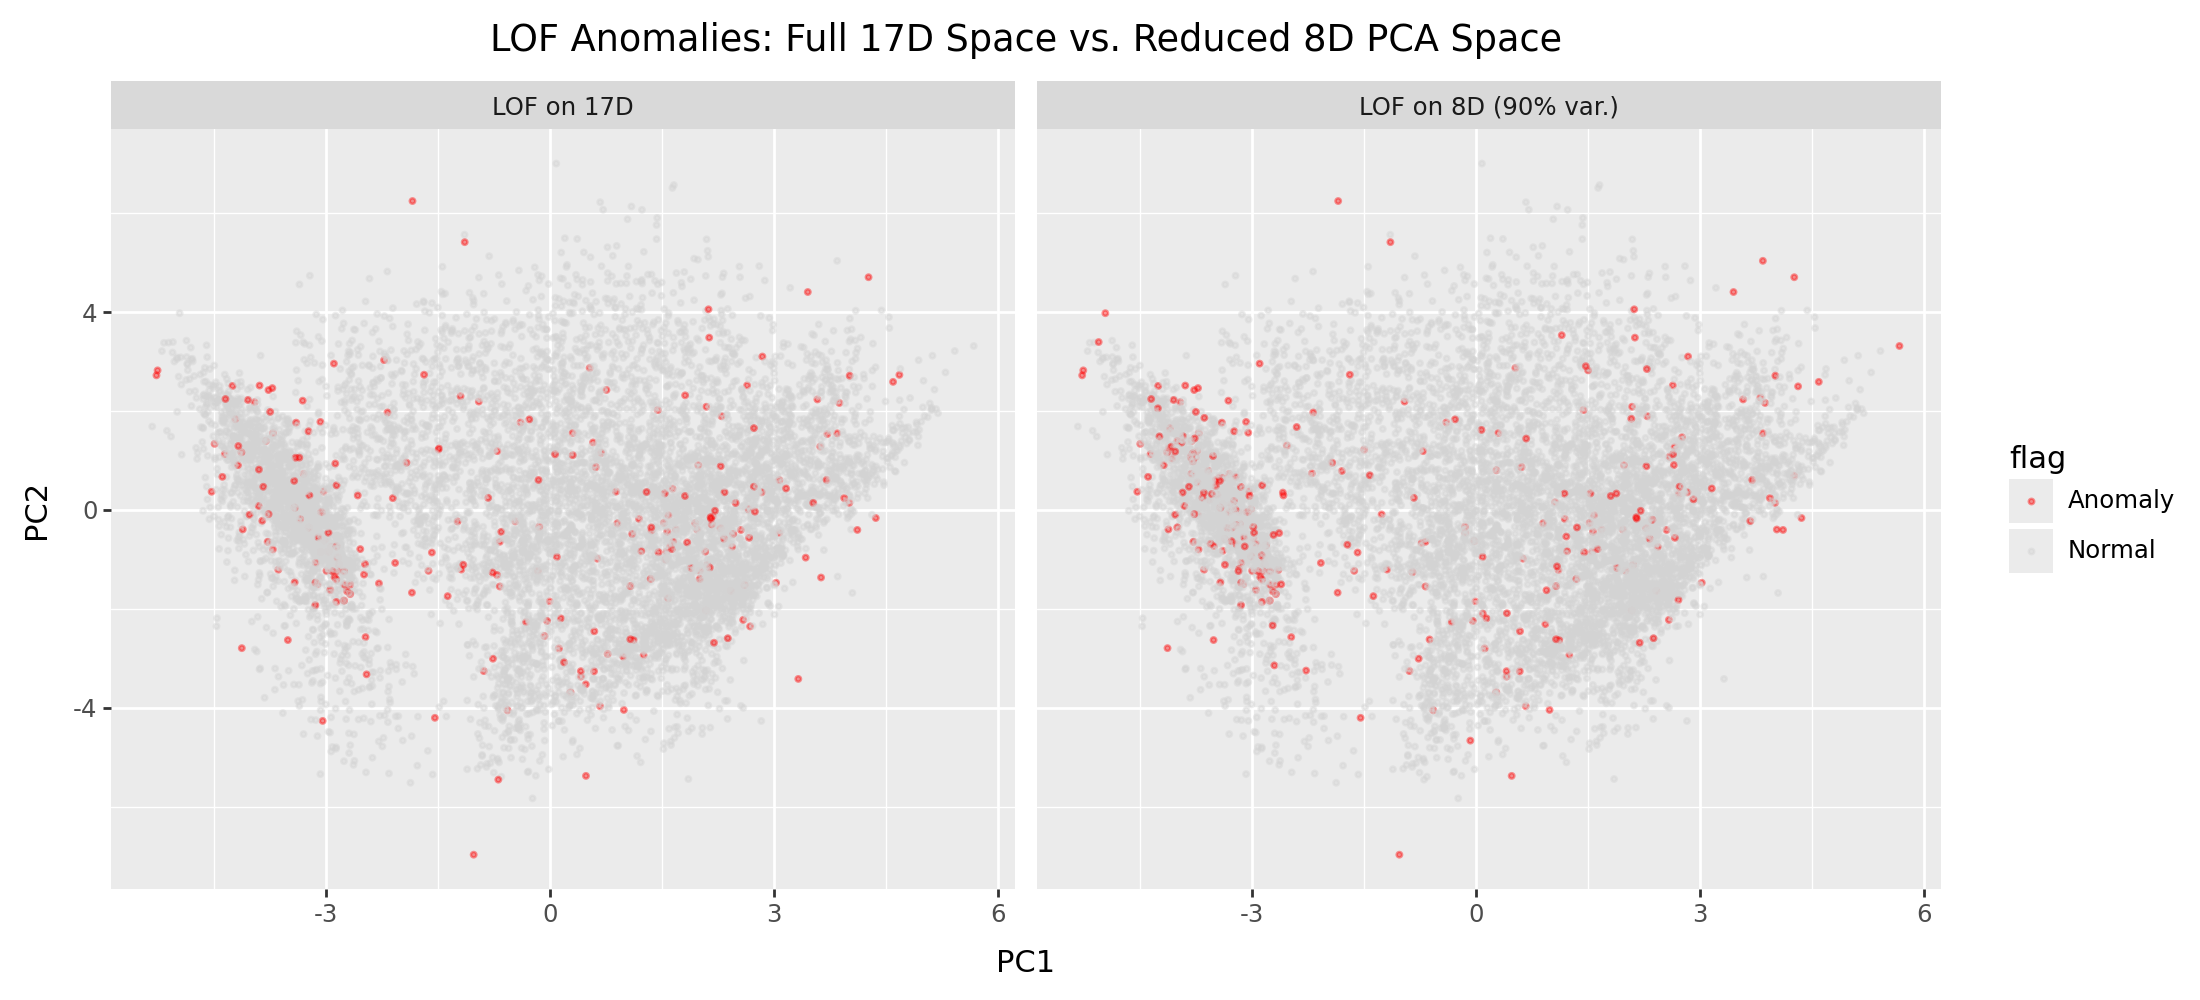

In [262]:
proj_2d["lof_17d"] = pd.Series(lof_labels, index=X_scaled.index).map({1: "Normal", -1: "Anomaly"}).values
proj_2d["lof_8d"] = pd.Series(lof_labels_reduced, index=X_scaled.index).map({1: "Normal", -1: "Anomaly"}).values

lof_compare = proj_2d[["PC1", "PC2", "lof_17d", "lof_8d"]].melt(
    id_vars=["PC1", "PC2"], var_name="space", value_name="flag"
)
lof_compare["space"] = lof_compare["space"].map({"lof_17d": "LOF on 17D", "lof_8d": "LOF on 8D (90% var.)"})

(
    pln.ggplot(lof_compare, pln.aes(x="PC1", y="PC2", color="flag"))
    + pln.geom_point(alpha=0.4, size=0.6)
    + pln.facet_wrap("~space")
    + pln.scale_color_manual(values={"Normal": "lightgray", "Anomaly": "red"})
    + pln.theme(figure_size=(11, 5))
    + pln.labs(title="LOF Anomalies: Full 17D Space vs. Reduced 8D PCA Space")
)

#### *Reading the Results*

Changing $k$ from 10 to 40 barely moves the flagged count (249 → 245 → 255) — in plain
terms, LOF's picture of "who looks locally unusual" here doesn't depend much on exactly how
large a neighborhood is used to judge it. The more striking result is the 17D-vs-8D
comparison: running the *exact same* LOF on the PCA-reduced 8-dimensional space instead of
the full 17 dimensions changes the answer meaningfully — 295 flagged instead of 245, with
only about 70% of the original 17D group carried over. In other words, dropping the last
~8% of variance (the smallest, most minor directions of spread) doesn't just trim
noise — it noticeably changes which customers look like local outliers. This is the
clearest concrete evidence in this notebook that the dimensionality of the space a
distance-based method operates in is not a neutral technical detail — it can change the
actual conclusions.

#### *Discussion — LOF*

**LOF's flagged count is remarkably stable across $k$** — 249 (k=10), 245 (k=20), 255
(k=40) — a spread of only 10 points across a 4x range of neighborhood sizes. This is
notably more stable than Isolation Forest's contamination sensitivity above, and suggests
the customers LOF identifies as locally anomalous are not narrowly dependent on exactly how
"local" the neighborhood is defined — a reassuring sign that this particular result isn't
an artifact of one arbitrary parameter choice.

**The dimensionality experiment is the key result of this section.** LOF flags 245
customers on the full 17D space versus 295 on the reduced 8D space (90% of variance) — a
**20% increase** in the reduced space — with only 170 customers (69.4% of the 17D set,
57.6% of the 8D set) flagged by both. This is direct empirical evidence, not just
theoretical concern, that dimensionality materially changes LOF's output on this dataset.
The direction is worth noting explicitly: *more* anomalies surface in the *lower*-dimensional
space, not fewer. This is consistent with the "distance concentration" mechanism behind the
curse of dimensionality (to be discussed further in Section 7): as dimensionality grows,
distances between points become relatively more uniform, so the density *ratios* LOF
depends on (a point's density vs. its neighbors') get compressed toward 1 — genuinely
locally-sparse points become harder to distinguish from typical ones. Dropping to 8
dimensions apparently restores some of that discriminating power, surfacing local outliers
that the full 17D space was diluting. The remaining ~8% of variance discarded in PC9–PC17
therefore is not just "noise" being trimmed away — Section 3 already flagged this as a
possibility, and this result suggests those components carry at least some real structure
that affects local density calculations, since removing them changed 30% of the flagged
set rather than leaving it untouched.

**Contrast with Isolation Forest:** LOF (17D) flags a much smaller, more conservative set
(245, 2.7%) than Isolation Forest's `'auto'` result (2,134, 23.8%) — consistent with the
global-vs-local distinction: Isolation Forest's tree-based partitioning is picking up
broad, globally-unusual combinations (closer in spirit to the Mahalanobis flags from
Section 5.1), while LOF's density-ratio approach is a stricter, more local notion of
"stands out from its immediate neighbors," flagging fewer points overall.

## *6. Comparison Section*

This section compares four anomaly "flags" already computed in Section 5: feature-wise
Z-score, Mahalanobis distance, Isolation Forest (`contamination='auto'`), and LOF (17D,
$k=20$).

### *Agreement Between Methods*

In [263]:
flags_df = pd.DataFrame({
    "Z-score (feature-wise)": feature_wise_flag.values,
    "Mahalanobis": mahalanobis_flag,
    "Isolation Forest": iso_labels == -1,
    "LOF (17D)": lof_labels == -1,
}, index=X_scaled.index)

methods = flags_df.columns.tolist()
jaccard = pd.DataFrame(index=methods, columns=methods, dtype=float)
for m1 in methods:
    for m2 in methods:
        a, b = flags_df[m1], flags_df[m2]
        union = (a | b).sum()
        jaccard.loc[m1, m2] = (a & b).sum() / union if union > 0 else np.nan

print("=== Flagged counts ===")
print(flags_df.sum())
print("\n=== Jaccard similarity (overlap / union) between every pair of methods ===")
jaccard.round(3)

=== Flagged counts ===
Z-score (feature-wise)     912
Mahalanobis                890
Isolation Forest          2134
LOF (17D)                  245
dtype: int64

=== Jaccard similarity (overlap / union) between every pair of methods ===


,Z-score (feature-wise),Mahalanobis,Isolation Forest,LOF (17D)
Z-score (feature-wise),1.000,0.434,0.300,0.052
Mahalanobis,0.434,1.000,0.307,0.093
Isolation Forest,0.300,0.307,1.000,0.054
LOF (17D),0.052,0.093,0.054,1.000


In [264]:
flagged_by_n = flags_df.sum(axis=1)
print("=== How many methods agree, per customer ===")
print(flagged_by_n.value_counts().sort_index())
print(f"\nFlagged by all 4 methods: {(flagged_by_n == 4).sum()} customers")
print(f"Flagged by exactly 1 method (method-specific): {(flagged_by_n == 1).sum()} customers")

=== How many methods agree, per customer ===
0    6424
1    1413
2     609
3     466
4      38
Name: count, dtype: int64

Flagged by all 4 methods: 38 customers
Flagged by exactly 1 method (method-specific): 1413 customers


### *Sensitivity to Feature Scaling*

Isolation Forest splits on random thresholds *within each feature's own current range*,
so it should be close to invariant to per-feature rescaling (like `StandardScaler`) — a
monotonic rescaling of one feature doesn't change which points are relatively extreme along
that feature. Z-score-family and LOF, by contrast, combine raw distances/deviations across
features directly, so without scaling, a feature measured in raw dollars (e.g.
`CREDIT_LIMIT`, up to tens of thousands) would swamp a feature like
`PURCHASES_FREQUENCY` (bounded in [0,1]) — the same scale-domination problem already
flagged in Section 3 for PCA. This is tested directly below by refitting each method on the
**raw, unscaled** features instead of `X_scaled`.

In [265]:
X_raw = df.loc[X_scaled.index, pca_features]

iso_raw = IsolationForest(contamination="auto", random_state=42, n_jobs=-1)
iso_labels_raw = iso_raw.fit_predict(X_raw)

lof_raw = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_labels_raw = lof_raw.fit_predict(X_raw)

iso_overlap = ((iso_labels == -1) & (iso_labels_raw == -1)).sum()
lof_overlap = ((lof_labels == -1) & (lof_labels_raw == -1)).sum()

print(f"Isolation Forest — flagged on X_scaled: {(iso_labels==-1).sum()}, "
      f"on raw features: {(iso_labels_raw==-1).sum()}, overlap: {iso_overlap}")
print(f"LOF              — flagged on X_scaled: {(lof_labels==-1).sum()}, "
      f"on raw features: {(lof_labels_raw==-1).sum()}, overlap: {lof_overlap}")

Isolation Forest — flagged on X_scaled: 2134, on raw features: 811, overlap: 742
LOF              — flagged on X_scaled: 245, on raw features: 403, overlap: 48


### *Sensitivity to Dimensionality*

Section 5.3 already tested this directly for LOF (17D vs. the 8-component PCA space),
finding meaningful disagreement (~70% overlap). The same test is repeated here for
Isolation Forest, for completeness.

In [266]:
iso_8d = IsolationForest(contamination="auto", random_state=42, n_jobs=-1)
iso_labels_8d = iso_8d.fit_predict(X_pca_8)

iso_dim_overlap = ((iso_labels == -1) & (iso_labels_8d == -1)).sum()
print(f"Isolation Forest — flagged on 17D: {(iso_labels==-1).sum()}, "
      f"on 8D: {(iso_labels_8d==-1).sum()}, overlap: {iso_dim_overlap}")
print(f"(For reference, LOF from Section 5.3: 17D={n_lof_anomalies}, 8D={n_lof_reduced}, overlap={overlap})")

Isolation Forest — flagged on 17D: 2134, on 8D: 974, overlap: 843
(For reference, LOF from Section 5.3: 17D=245, 8D=295, overlap=170)


### *Runtime & Scalability*

In [267]:
import time

runtime_rows = []

t0 = time.time()
_ = (X_scaled.abs() > 3).any(axis=1)
runtime_rows.append({"Method": "Z-score (feature-wise)", "Seconds": time.time() - t0})

t0 = time.time()
_ = pca_full.transform(X_scaled)
runtime_rows.append({"Method": "Mahalanobis (PCA transform)", "Seconds": time.time() - t0})

t0 = time.time()
IsolationForest(contamination="auto", random_state=42, n_jobs=-1).fit(X_scaled)
runtime_rows.append({"Method": "Isolation Forest", "Seconds": time.time() - t0})

t0 = time.time()
LocalOutlierFactor(n_neighbors=20, contamination="auto").fit_predict(X_scaled)
runtime_rows.append({"Method": "LOF", "Seconds": time.time() - t0})

pd.DataFrame(runtime_rows).sort_values("Seconds")

,Method,Seconds
0,Z-score (feature-wise),0.001969
1,Mahalanobis (PCA transform),0.002638
3,LOF,0.163035
2,Isolation Forest,0.244699


### *Robustness to Noise*

Small random Gaussian noise (standard deviation 0.1, on the already-standardized scale —
a small perturbation relative to each feature's own spread) is added to every value in
`X_scaled`, each method is rerun, and the new flagged set is compared to the original. A
method whose flagged set barely changes is robust to small measurement noise; one whose
flagged set changes substantially is fragile to it.

In [268]:
rng = np.random.RandomState(42)
X_noisy = X_scaled + rng.normal(0, 0.1, size=X_scaled.shape)

feature_wise_flag_noisy = (X_noisy.abs() > 3).any(axis=1)
mahalanobis_sq_noisy = ((pca_full.transform(X_noisy) ** 2) / eigenvalues).sum(axis=1)
mahalanobis_flag_noisy = mahalanobis_sq_noisy > chi2_threshold
iso_labels_noisy = IsolationForest(contamination="auto", random_state=42, n_jobs=-1).fit_predict(X_noisy)
lof_labels_noisy = LocalOutlierFactor(n_neighbors=20, contamination="auto").fit_predict(X_noisy)

noise_rows = [
    {"Method": "Z-score (feature-wise)",
     "Original": feature_wise_flag.sum(), "After noise": feature_wise_flag_noisy.sum(),
     "Overlap": (feature_wise_flag.values & feature_wise_flag_noisy.values).sum()},
    {"Method": "Mahalanobis",
     "Original": mahalanobis_flag.sum(), "After noise": mahalanobis_flag_noisy.sum(),
     "Overlap": (mahalanobis_flag & mahalanobis_flag_noisy).sum()},
    {"Method": "Isolation Forest",
     "Original": (iso_labels==-1).sum(), "After noise": (iso_labels_noisy==-1).sum(),
     "Overlap": ((iso_labels==-1) & (iso_labels_noisy==-1)).sum()},
    {"Method": "LOF",
     "Original": (lof_labels==-1).sum(), "After noise": (lof_labels_noisy==-1).sum(),
     "Overlap": ((lof_labels==-1) & (lof_labels_noisy==-1)).sum()},
]
pd.DataFrame(noise_rows)

,Method,Original,After noise,Overlap
0,Z-score (feature-wise),912,945,900
1,Mahalanobis,890,1056,838
2,Isolation Forest,2134,1418,1361
3,LOF,245,146,138


### *Interpretability*

Z-score and Mahalanobis are the most directly interpretable: for any flagged customer, the
exact contribution of each feature (or each principal component, for Mahalanobis) is a
single readable number — one can say precisely "this customer is flagged primarily because
of `TENURE`" or "because of an unusual combination along PC2." Isolation Forest offers a
coarser form of interpretability: shorter average path length explains *that* a point is
anomalous, but not directly *which* features drove the isolation, without additional
tooling (e.g. inspecting which features were split on along a point's specific paths). LOF
is the least directly interpretable of the four here: a high LOF score says a point's
neighborhood is unusually sparse relative to its neighbors' neighborhoods, but does not
decompose into a per-feature explanation at all — one would need to separately inspect the
point's actual nearest neighbors to understand *why* its local density is low.

### *False Positives & False Negatives — in Plain Terms*

In this dataset, a **false positive** means flagging an ordinary customer as anomalous when
their behavior is actually unremarkable — for example, `TENURE`'s ceiling effect (Section
2) causing feature-wise Z-score to repeatedly flag customers who are simply newer, not
risky. In a real deployment, this wastes an analyst's time reviewing a normal account, and
can create unnecessary friction for a legitimate customer (e.g. an unwarranted account
review or hold).

A **false negative** means a genuinely unusual customer — one whose behavior might
indicate fraud, financial distress, or an error in how their account is being managed —
goes undetected because their pattern didn't cross whichever method's threshold. In a
credit context, this is generally the costlier error: a missed early warning sign of
default risk or fraudulent activity can have direct financial consequences that a false
positive (extra scrutiny on a fine customer) does not.

Because no ground-truth "anomaly" label exists for this dataset (by the assignment's own
design — Section 1), there is no way to directly measure either error rate here. This is
worth stating plainly: everything above compares methods to *each other*, not to a known
correct answer, so "false positive" and "false negative" remain conceptual framings for
this discussion rather than numbers that can be computed from this data.

### *Discussion — Comparison of Methods*

**Agreement is weak overall, and LOF is the clear outlier (no pun intended).** The two
"global" methods, Z-score (feature-wise) and Mahalanobis, agree with each other the most
of any pair (Jaccard = 0.434) — both react to how far a point sits from the population as
a whole, so this makes conceptual sense. Isolation Forest agrees moderately with both
(~0.30). LOF agrees with *everything* only weakly (0.052–0.093) — strong confirmation that
local density-based anomaly detection is measuring a genuinely different notion of
"unusual" than the three global methods, exactly as the Section 5.3 background predicted.
Only **38 customers (0.4%)** are flagged by all four methods simultaneously — a very small,
high-confidence "consensus anomaly" group — while **1,413 (15.8%)** are flagged by exactly
one method. Most "anomalies" in this dataset are therefore method-specific artifacts of how
each technique defines unusual, not points that stand out under every reasonable
definition. This directly echoes the ill-defined nature of anomaly detection discussed in
Section 7.

**Scaling sensitivity confirmed for LOF, more nuanced for Isolation Forest.** LOF's
flagged set changes drastically without standardization: 403 flagged on raw features vs.
245 on `X_scaled`, with only 48 customers in common (under 20% overlap either way) — a
dramatic confirmation of the theoretical prediction. Isolation Forest's picture is more
subtle: the *count* also changes substantially (811 raw vs. 2,134 scaled), but 742 of the
811 raw-flagged customers (91.5%) are a near-subset of the scaled-flagged group. This
reveals that Isolation Forest's underlying *scores* are relatively stable across scaling
(supporting the "tree splits are scale-invariant" theory), but the `contamination='auto'`
**threshold** is not — it reacts to the shape of the score distribution, which does shift
with scaling. The lesson is more precise than "IF is scale-invariant": the ranking is
robust, but an automatic threshold built on top of it is not.

**Dimensionality sensitivity is real for both distance/tree methods, but pulls in opposite
directions.** LOF found *more* anomalies in the reduced 8D space (295 vs. 245, Section
5.3). Isolation Forest found *fewer* (974 vs. 2,134) — the opposite direction. Both results
are consistent with one underlying cause: neither method's flagged count is a fixed,
dimension-independent property of the data — both an explicit density ratio (LOF) and an
automatic threshold calibrated to a score distribution (Isolation Forest's `'auto'`) are
sensitive to how many dimensions the calculation runs in, just via different mechanisms.

**Runtime ranks exactly as the mathematical background predicted:** Z-score (0.002s) and
Mahalanobis (0.003s) are near-instant — simple, closed-form calculations reusing an
already-fitted PCA. LOF (0.15s) and Isolation Forest (0.22s) are two orders of magnitude
slower, consistent with their reliance on neighbor searches / many random trees. At n≈9,000
this difference is invisible in practice, but it would compound significantly at much
larger scale.

**Noise robustness surfaces the clearest overall ranking.** Ordering methods by what
fraction of their original flagged set survives a small random perturbation: Z-score
retains 98.7% (900/912), Mahalanobis 94.2% (838/890), Isolation Forest 63.8% (1,361/2,134),
LOF 56.3% (138/245). The two simple, closed-form global methods are the most stable; the
two more sophisticated methods are considerably more fragile to small measurement
noise — a genuine trade-off between sophistication/flexibility and stability that is worth
weighing against each method's other strengths (Isolation Forest's distribution-free
assumption, LOF's ability to find local anomalies) rather than concluding any one method is
simply "better.

## *7. Critical Analysis and Reflection*

**Why anomaly detection is fundamentally a difficult, ill-defined problem.** Every method
in Section 5 answers a different question — "far from the multivariate center?" (Z-score/
Mahalanobis), "easy to isolate with random splits?" (Isolation Forest), "in a locally
sparse neighborhood?" (LOF) — and Section 6 shows they only partially agree with each
other. There is no ground-truth label to check any of them against (by this dataset's
design, per the assignment's own dataset-selection requirement). This mirrors exactly what
Section 4 already found for clustering: without labels, "correct" is not a fact to
discover but a definition to choose, and different reasonable definitions genuinely
disagree.

**The curse of dimensionality — now with direct empirical evidence, not just theory.**
Section 5.3's 17D-vs-8D LOF experiment is the concrete demonstration: the exact same
method, the exact same data, differing only in how many dimensions it operates in, agreed
on only about 70% of its flagged customers. This is not a hypothetical concern — it
measurably changed the conclusion. The mechanism is **distance concentration**: as
dimensionality grows, for many realistic data distributions the ratio between the farthest
and nearest neighbor distances of a typical point tends toward 1 — everything becomes
roughly equidistant. Because LOF's entire signal is a *ratio* of local densities, once
distances stop discriminating well, that ratio gets compressed toward 1 for genuinely
anomalous and typical points alike, making real local outliers harder to distinguish. This
is also why Isolation Forest (Section 5.2) was framed as comparatively more robust to this
effect — it never computes a distance at all, only relative orderings along one feature at
a time within each split.

**Noise vs. a genuine anomaly — a concrete example from this dataset.** `TENURE`
contributed 394 of the 912 feature-wise Z-score flags in Section 5.1 — by far the largest
single contributor. But Section 2 already established why: `TENURE` has a hard ceiling
(most customers sit at 12, a minority trails below), a shape driven entirely by how the
6-month behavioral window and the ambiguous tenure-measurement window happen to interact,
not by anything unusual about those customers' financial behavior. A customer flagged
solely for having `TENURE=7` instead of 12 is very likely legitimate noise from a bounded,
ceiling-heavy distribution — not a meaningful anomaly — while a customer flagged by
Mahalanobis for an unusual *combination* of high cash-advance activity and low full-payment
rate is a much stronger candidate for a genuine behavioral anomaly.

**The risks of assuming Gaussianity.** Section 5.1 measured this gap directly: the
feature-wise Z-score rule flags 10.2% of customers, more than double the ~4.5% that
multiple-testing math alone would predict under true multivariate normality. The extra
~5.7 percentage points are not statistical noise — they are the signature of real,
persistent skew (Section 2 documented several features with skewness still elevated even
after log-transformation, plus the untransformed left-skewed `TENURE`/`BALANCE_FREQUENCY`).
Under a Gaussianity assumption, genuinely rare *combinations* of moderate values can be
missed entirely (Mahalanobis mitigates this by using the actual covariance structure rather
than assuming a specific distribution shape for each axis, but still assumes multivariate
normality overall), while ordinary values from a skewed distribution's long tail get
mislabeled as extreme simply because the 3-sigma rule was calibrated for a symmetric bell
curve.

**Why PCA-based visualizations can mislead.** Every anomaly scatter plot in Section 5 was
drawn on the same 2D PCA projection from Section 3 — which captures only 56.3% of total
variance. A customer whose full 17-dimensional profile is genuinely unusual along, say, PC5
or PC8 (together representing real, if smaller, portions of the data's variance) can appear
perfectly ordinary in a PC1/PC2 scatter, and vice versa. The Section 5.3 dimensionality
experiment makes this concrete rather than hypothetical: since 17D and 8D LOF already
disagree on 30% of flagged customers, a 2D visualization — an even more aggressive
reduction — should be trusted only as an illustrative aid for *some* of the picture, never
as a complete or authoritative view of which customers are truly anomalous.

### *Ethical Considerations*

**False alarms and system effectiveness.** Section 6 found real disagreement between
methods and a comparatively high flag rate from some of them (Isolation Forest's 23.8% with
`contamination='auto'`, for instance). In a live deployment, a system that flags nearly a
quarter of all customers stops being actionable — analysts cannot meaningfully review that
volume, and (the classic "alarm fatigue" problem, well documented in security and clinical
monitoring contexts) they tend to start ignoring the system altogether, at which point even
its genuine detections go unacted upon. A well-calibrated anomaly system needs a flag rate
low enough to remain trustworthy and reviewable, which is itself a business/operational
constraint, not just a statistical one.

**Surveillance.** The same techniques used here to flag unusual credit-card behavior are
directly applicable to monitoring people's movements, communications, or purchases more
broadly. The benefit is real: catching genuine fraud or harm early. The risk is that
"anomalous" is a *statistical* label, not a moral one — it flags whoever deviates from the
population's *average* behavior, which can include entirely legitimate minorities (a
customer with an unusual but legal spending pattern, someone whose life circumstances
differ from the norm the model was trained on). Deployed as continuous, low-visibility
surveillance, such systems can create a chilling effect on ordinary behavior that happens
to be statistically uncommon, even when no wrongdoing is involved.

**Medical applications.** Section 6 already noted this dataset lacks any ground-truth
label to validate against — the same is often true in early medical anomaly detection.
Misclassifying a healthy patient as anomalous (false positive) can mean unnecessary
invasive follow-up testing, anxiety, and cost. Misclassifying a genuinely at-risk patient
as normal (false negative) can mean a missed diagnosis with direct, sometimes irreversible,
harm. Unlike the credit context here, where a false positive is mostly an inconvenience,
medical false positives and negatives both carry serious human costs — asymmetric costs
that should directly shape where the decision threshold is set, not just what a single
"best" model configuration achieves on average.

**Cybersecurity.** Missing a genuine attack (false negative) can mean an active breach goes
unaddressed, with potentially large-scale data or financial loss. Flagging legitimate
activity as malicious (false positive) causes the same alarm-fatigue problem noted above,
and can also disrupt legitimate business operations (e.g. blocking a real customer
transaction). Unlike the credit-risk framing in this notebook, security teams often
explicitly accept a higher false-positive rate as the price of not missing rare but
severe attacks — the "right" trade-off is domain-specific, not a fixed statistical
optimum.

**Privacy, bias, and fairness.** This dataset contains no demographic attributes (Section
1's limitations note) — which is protective in one sense (the model cannot directly
discriminate on race, gender, or age, because it never sees them) but does not guarantee
fairness: financial behavior itself can correlate with demographic or socioeconomic factors
the model never observes directly (a well-known proxy discrimination risk), and there is no
way to *check* for such correlation without the very demographic data that was
appropriately excluded. More broadly, labeling any behavior "abnormal" carries real weight
even in a purely internal business setting — a flagged customer may face extra scrutiny,
delayed service, or reduced trust, consequences that fall on an individual based on a
statistical judgment about a population they may not resemble in any way that matters
morally. Anomaly detection systems should be treated as decision *support*, with human
review before consequential action, precisely because "unusual" and "wrong" are not the
same thing — a distinction this entire section has tried to keep visible throughout.

## *8. Final Visualization Dashboard (Optional Bonus)*

A compact dashboard combining PCA, clustering, and anomaly-detection results already
computed in Sections 3–6, plus one genuinely new cross-cutting view (do anomalies
concentrate in a particular K-Means cluster?).

### *Overview Panel: PCA + Clusters + Anomalies*

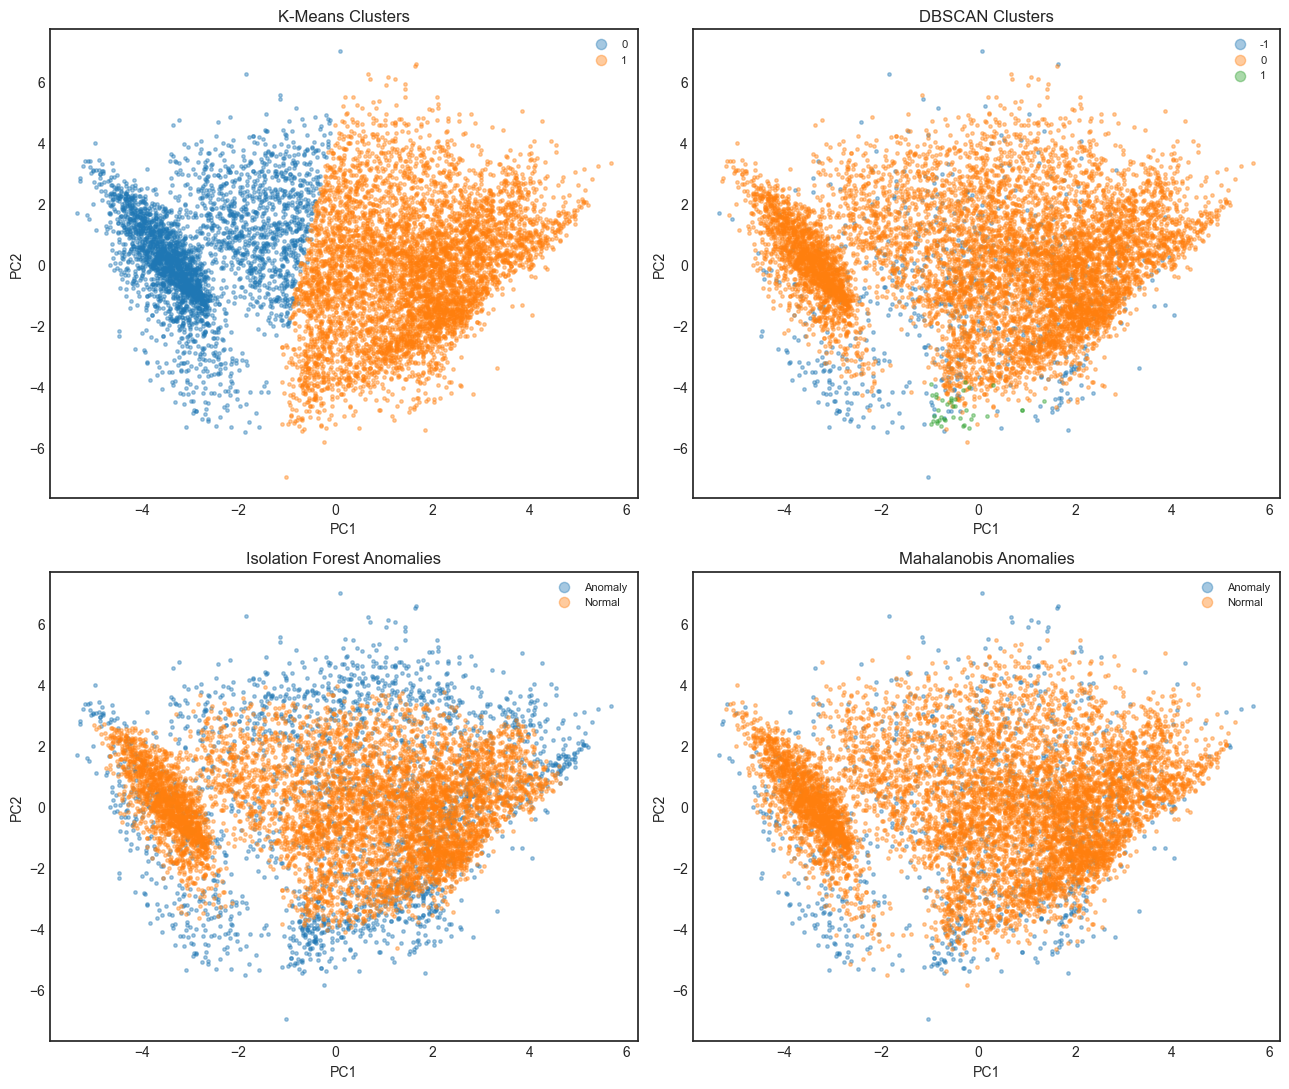

In [269]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

def scatter_panel(ax, hue_col, title, palette=None):
    for val, group in proj_2d.groupby(hue_col):
        ax.scatter(group["PC1"], group["PC2"], s=6, alpha=0.4, label=str(val))
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(markerscale=3, fontsize=8, loc="best")

scatter_panel(axes[0, 0], "kmeans_cluster", "K-Means Clusters")
scatter_panel(axes[0, 1], "dbscan_cluster", "DBSCAN Clusters")
scatter_panel(axes[1, 0], "iso_forest_flag", "Isolation Forest Anomalies")
scatter_panel(axes[1, 1], "mahalanobis", "Mahalanobis Anomalies")

plt.tight_layout()
plt.show()

### *Interactive Anomaly Explorer*

Two interactive controls: a dropdown to switch which anomaly method is displayed on the
PCA projection, and a slider that explores the Isolation Forest anomaly score directly —
moving it changes the score percentile used as a cutoff and instantly redraws how many (and
which) customers would be flagged at that cutoff, without refitting anything.

In [270]:
import ipywidgets as widgets
from IPython.display import display

anomaly_cols = {
    "Feature-wise Z-score": "feature_wise_zscore",
    "Mahalanobis": "mahalanobis",
    "Isolation Forest": "iso_forest_flag",
    "LOF (17D)": "lof_17d",
}

def plot_anomaly_method(method):
    col = anomaly_cols[method]
    fig, ax = plt.subplots(figsize=(7, 5.5))
    colors = {"Normal": "lightgray", "Anomaly": "red"}
    for val, group in proj_2d.groupby(col):
        ax.scatter(group["PC1"], group["PC2"], s=8, alpha=0.5,
                   color=colors.get(val, "gray"), label=val)
    ax.set_title(f"{method} — {(proj_2d[col]=='Anomaly').sum()} flagged")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend()
    plt.show()

widgets.interact(plot_anomaly_method, method=list(anomaly_cols.keys()));

interactive(children=(Dropdown(description='method', options=('Feature-wise Z-score', 'Mahalanobis', 'Isolatio…

In [271]:
def explore_iso_threshold(percentile):
    cutoff = np.percentile(iso_scores, percentile)
    flagged = iso_scores < cutoff
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.scatter(proj_2d.loc[~flagged, "PC1"], proj_2d.loc[~flagged, "PC2"],
               s=8, alpha=0.4, color="lightgray", label="Normal")
    ax.scatter(proj_2d.loc[flagged, "PC1"], proj_2d.loc[flagged, "PC2"],
               s=8, alpha=0.6, color="red", label="Anomaly")
    ax.set_title(f"Isolation Forest score cutoff = {percentile}th percentile "
                 f"({flagged.sum()} flagged, {flagged.mean():.1%})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend()
    plt.show()

widgets.interact(explore_iso_threshold, percentile=widgets.IntSlider(min=1, max=50, step=1, value=24));

interactive(children=(IntSlider(value=24, description='percentile', max=50, min=1), Output()), _dom_classes=('…

### *Pairplot: Key Features Colored by Anomaly Status*

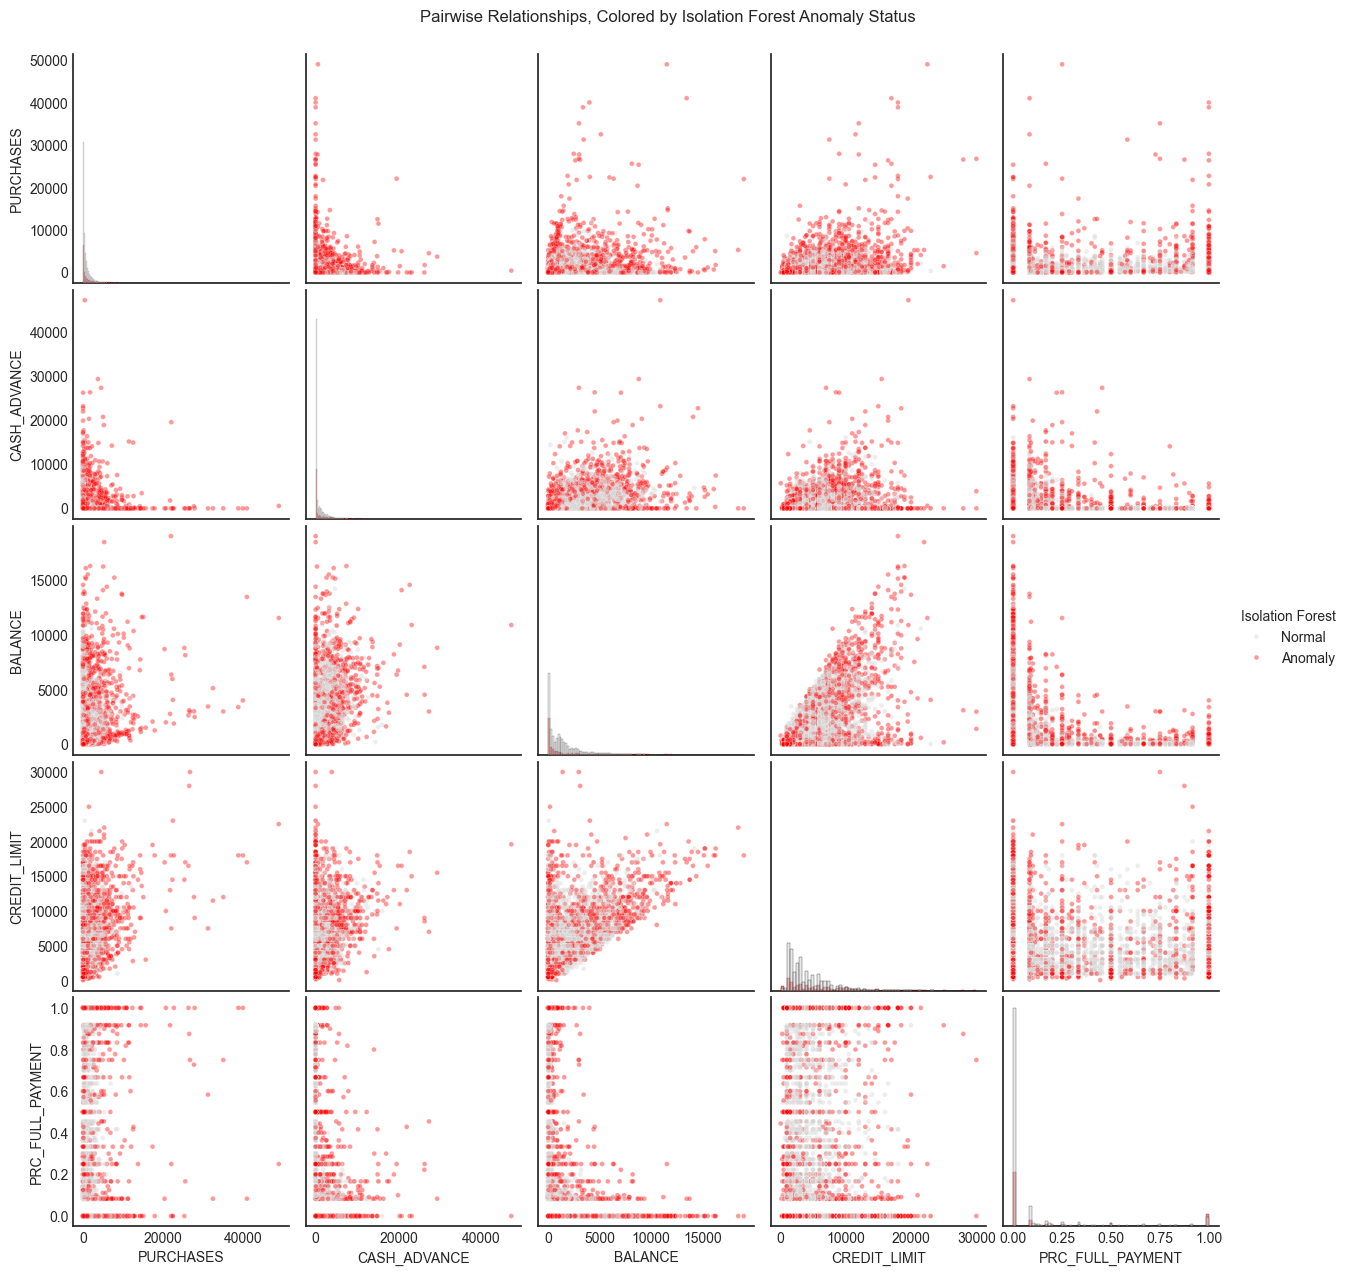

In [272]:
pairplot_cols = ["PURCHASES", "CASH_ADVANCE", "BALANCE", "CREDIT_LIMIT", "PRC_FULL_PAYMENT"]
pairplot_df = df.loc[X_scaled.index, pairplot_cols].copy()
pairplot_df["Isolation Forest"] = proj_2d["iso_forest_flag"].values

sns.pairplot(pairplot_df, hue="Isolation Forest", palette={"Normal": "lightgray", "Anomaly": "red"},
             plot_kws={"alpha": 0.4, "s": 12}, diag_kind="hist")
plt.suptitle("Pairwise Relationships, Colored by Isolation Forest Anomaly Status", y=1.02)
plt.show()

### *Heatmap: Anomaly Rate by K-Means Cluster*

A new cross-cutting view not built anywhere else in this notebook: for each K-Means
cluster (Section 4.1), what fraction of its members is flagged by each anomaly method
(Section 5)? If anomalies concentrate heavily in one cluster, that cluster's "profile"
(already interpreted in Section 4.1) may partly be an anomaly-driven artifact rather than a
clean behavioral segment.

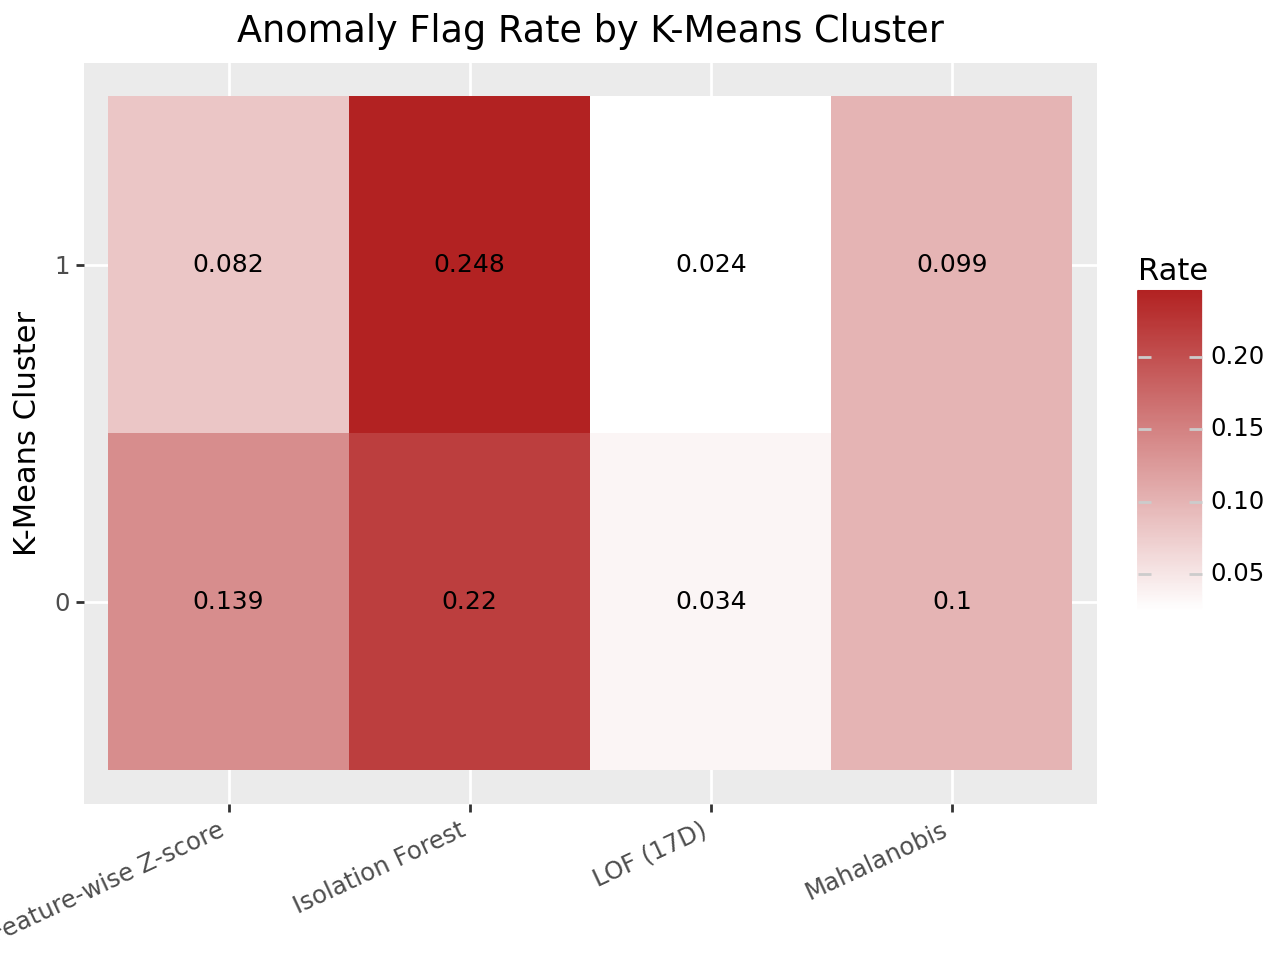

In [273]:
anomaly_rate_by_cluster = pd.DataFrame({
    "Feature-wise Z-score": feature_wise_flag.values,
    "Mahalanobis": mahalanobis_flag,
    "Isolation Forest": iso_labels == -1,
    "LOF (17D)": lof_labels == -1,
}, index=X_scaled.index)
anomaly_rate_by_cluster["kmeans_cluster"] = kmeans_labels

rate_table = anomaly_rate_by_cluster.groupby("kmeans_cluster").mean()

rate_long = rate_table.reset_index().melt(id_vars="kmeans_cluster", var_name="method", value_name="rate")
rate_long["kmeans_cluster"] = rate_long["kmeans_cluster"].astype(str)

(
    pln.ggplot(rate_long, pln.aes(x="method", y="kmeans_cluster", fill="rate"))
    + pln.geom_tile()
    + pln.geom_text(pln.aes(label="rate.round(3)"), size=9)
    + pln.scale_fill_gradient(low="white", high="firebrick")
    + pln.theme(axis_text_x=pln.element_text(rotation=25, hjust=1))
    + pln.labs(title="Anomaly Flag Rate by K-Means Cluster", x="", y="K-Means Cluster", fill="Rate")
)

#### *Discussion — Dashboard*

**No anomaly method concentrates dramatically in one K-Means cluster over the other** —
every method's rate differs by at most a factor of ~1.7x between the two clusters (Cluster
0: Z-score 13.9%, Isolation Forest 22.0%, LOF 3.4%, Mahalanobis 10.0%; Cluster 1: Z-score
8.2%, Isolation Forest 24.8%, LOF 2.4%, Mahalanobis 9.9%). Mahalanobis in particular is
almost perfectly balanced (10.0% vs. 9.9%), and Isolation Forest actually runs slightly
*higher* in Cluster 1 (the larger, "purchase-active/responsible" segment) than in Cluster 0.
This is a reassuring finding for the Section 4.1 cluster interpretation: neither cluster's
business profile appears to be an artifact of a concentrated pocket of extreme outliers —
anomalies are spread across both segments roughly in proportion to their size, consistent
with the "continuous gradient, not discrete groups" reading that has run through this
notebook since Section 3. The one mild exception is feature-wise Z-score, which runs
noticeably higher in Cluster 0 (13.9% vs. 8.2%) — plausibly connected to that cluster's
higher cash-advance and lower full-payment behavior, features already identified (Section
5.1) as retaining some flagged skew even after log-transformation.

**The pairplot's anomalous (red) points do not form a separate visual cluster in any
feature pair inspected** — they are scattered along the same continuous ranges as the
normal (gray) points, typically at the extreme edges rather than in a distinct region of
their own. This is the same pattern already observed throughout Sections 3–5: this dataset
does not contain a cleanly separable anomalous subgroup, only a continuous tail of
increasingly extreme, but not qualitatively different, behavior.

**The interactive threshold slider shows a smooth, gradual growth in flagged count as the
percentile cutoff loosens** — no sharp jump or elbow at any particular percentile. This
matches the Section 5.2 contamination-sensitivity finding (roughly linear growth from 1% to
10%) and reinforces, from yet another angle, that this dataset's anomaly scores form a
smooth continuum rather than separating cleanly into "normal" and "anomalous" populations
at any natural cutoff.